### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from matplotlib.ticker import FuncFormatter

### Get data from data_processed.csv

In [2]:
df = pd.read_csv('data_processed.csv')

## **PART 3. Question**

##### Before moving on to the question-asking section, we will pose questions related to the available data. Specifically, we will identify the characteristics that influence the decision to purchase products at the pharmacy. We will compare and present these using charts for easier evaluation.

Question 1: In each category, which factor is decisive?

Question 2: In each category, which domestic and foreign products receive more attention?

Question 3: In each category, the distribution of prices.

Question 4: In each category, the distribution of brands.

Question 5: In each category, the distribution of dosage forms.

- We need to note the importance of the existing rating column. Divide the rating into 2 parts:

Popular: With all data rated. This will be considered as products that have received attention, users have bought and experienced them, and decided to give feedback.

Unpopular: With all data 'unknown'. This will be considered as products that have not been experienced by users and are not receiving attention.

## **PART 4. Visualization**

## Question 1

In [3]:
rating_df = df[df['Rating'] != 'unknown']
rating_df

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành...,Chăm sóc cơ thể,Viên nén,230000.0,Kingphar,Hoa Kỳ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera...",Chăm sóc cơ thể,Viên nén,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
4,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Kingphar,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
5,Sữa rửa mặt On: The Body Rice Therapy Heartlea...,"Sữa rửa mặt (Kem, gel, sữa)",Viên nén,132000.0,Kingphar,Hàn Quốc,Hàn Quốc,5.0,Asia,Chăm sóc da mặt
...,...,...,...,...,...,...,...,...,...,...
1979,Sữa bột CaloSure gold Vitadairy tăng cường sức...,Sữa,Dạng bột,230000.0,VITADAIRY,Việt Nam,Việt Nam,5.0,Asia,Dinh dưỡng
1980,Viên uống Sheep Placenta Nature’s Gold làm sạc...,Hỗ trợ làm đẹp,Viên nang,230000.0,Nature's Gold,Úc,Úc,5.0,Other,Hỗ trợ làm đẹp
1981,Viên uống Vital Code Kids Milky Calcium Plus V...,Bổ sung Canxi & Vitamin D,Viên nang mềm,230000.0,Kingphar,Úc,Úc,5.0,Other,Vitamin và Khoáng chất
1987,Viên xương khớp Khương Thảo Đan hỗ trợ là...,Cơ xương khớp,Viên nang,230000.0,Thái Minh,Việt Nam,Việt Nam,5.0,Asia,Cải thiện tăng cường chức năng


In [4]:
unrating_df = df[df['Rating'] == 'unknown']
unrating_df

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...,Chăm sóc cơ thể,Viên nén,390000.0,SVR,Pháp,Pháp,unknown,Europe,Chăm sóc cơ thể
10,Gội phủ bạc Healthy and lively H1 Lavox màu đe...,Dầu gội dầu xả,Dung dịch,22400.0,LAVOX,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc tóc - da đầu
14,Sữa chống nắng dưỡng ẩm kiềm dầu NeoAqua Sunsc...,Chống nắng toàn thân,Viên nén,151200.0,NeoAqua,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
30,Dầu gió lăn Red Lion Medicated Oil Yellow Agim...,Chăm sóc cơ thể,Viên nén,39000.0,Agimexpharm,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
31,Dầu gió lăn Red Lion Medicated Oil White Agime...,Chăm sóc cơ thể,Viên nén,39000.0,Agimexpharm,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
...,...,...,...,...,...,...,...,...,...,...
1994,Viên uống Tiền Đình Khang KGA dùng cho rối loạ...,Kiểm soát căng thẳng,Viên nén bao phim,230000.0,Kingphar,Việt Nam,Việt Nam,unknown,Asia,Thần kinh não
1995,"Viên nang mềm Xương Khớp PV Forte hỗ trợ khớp,...",Cơ xương khớp,Viên nang mềm,230000.0,Phúc Vinh,Việt Nam,Việt Nam,unknown,Asia,Cải thiện tăng cường chức năng
1996,"Gói cốm Futizon PV Pharma hỗ trợ bù nước, điện...",Vitamin & Khoáng chất,Cốm,230000.0,Phúc Vinh,Việt Nam,Việt Nam,unknown,Asia,Vitamin và Khoáng chất
1997,Sữa Pregestimil Lipil Mead Johnson bổ sung din...,Sữa,Dạng bột,230000.0,MEAD JOHNSON,Mỹ,Hoa Kỳ,unknown,America,Dinh dưỡng


### Frequency of each product function being of popular or unpopular.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\4191264466.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\4191264466.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(unrating_counts_sorted.index, rotation=90)


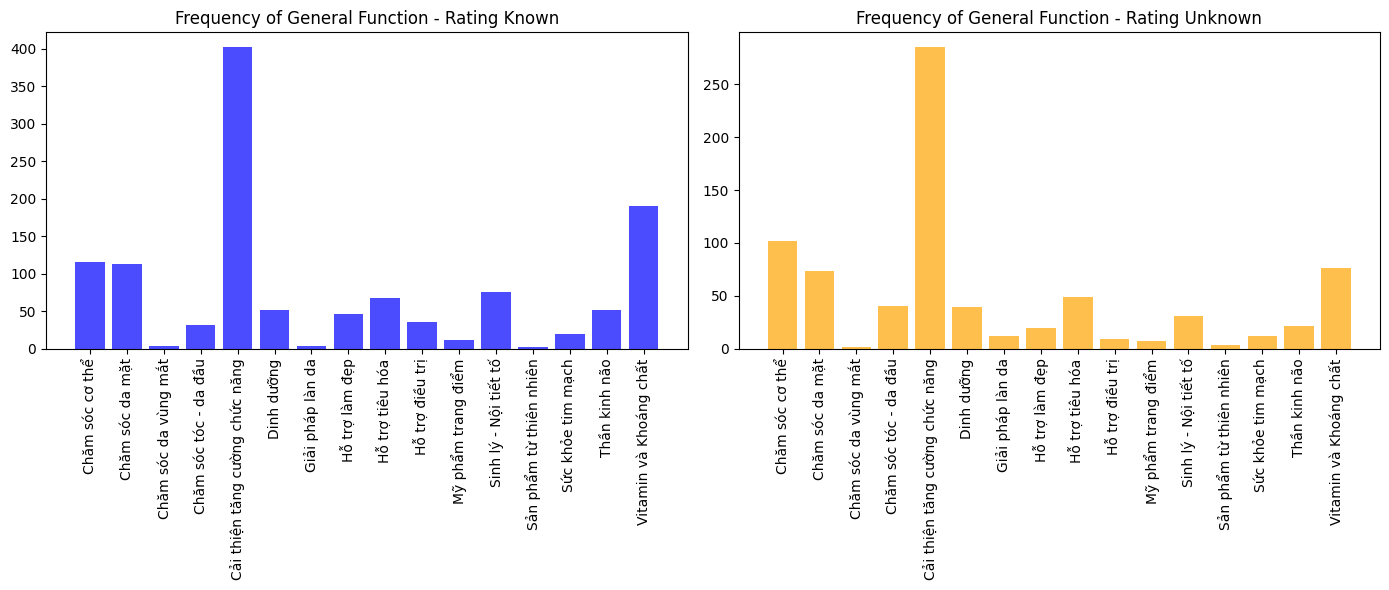

In [5]:
rating_counts = rating_df['General_function'].value_counts()
unrating_counts = unrating_df['General_function'].value_counts()


common_index = rating_counts.index.union(unrating_counts.index)

rating_counts_sorted = rating_counts.reindex(common_index, fill_value=0)
unrating_counts_sorted = unrating_counts.reindex(common_index, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the rating data frequency
axes[0].bar(rating_counts_sorted.index, rating_counts_sorted.values, color='blue', alpha=0.7)
axes[0].set_title('Frequency of General Function - Rating Known')
axes[0].set_xticklabels(rating_counts_sorted.index, rotation=90)

# Plot the unrating data frequency
axes[1].bar(unrating_counts_sorted.index, unrating_counts_sorted.values, color='orange', alpha=0.7)
axes[1].set_title('Frequency of General Function - Rating Unknown')
axes[1].set_xticklabels(unrating_counts_sorted.index, rotation=90)

plt.tight_layout()
plt.show()


### In each function, the frequency of countries of origin for products that are of interest and not of interest

In [6]:
def frequence_countries_by_general_function(func: str):
    func_rating_df = rating_df[rating_df['General_function'] == func]
    func_unrating_df = unrating_df[unrating_df['General_function'] == func]

    func_rating_counts = func_rating_df['Brand Origin'].value_counts()
    func_unrating_counts = func_unrating_df['Brand Origin'].value_counts()

    # Xác định các chỉ mục chung giữa các cột
    common_index = func_rating_counts.index.union(func_unrating_counts.index)

    # Đảm bảo các cột có cùng thứ tự và bổ sung giá trị 0 nếu thiếu
    func_rating_counts_sorted = func_rating_counts.reindex(common_index, fill_value=0)
    func_unrating_counts_sorted = func_unrating_counts.reindex(common_index, fill_value=0)

    # Xác định giá trị y lớn nhất
    max_y = max(func_rating_counts_sorted.max(), func_unrating_counts_sorted.max()) * 1.1

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Biểu đồ cho Rating Known
    axes[0].bar(func_rating_counts_sorted.index, func_rating_counts_sorted.values, color='blue', alpha=0.7)
    axes[0].set_title(f'Frequency of Brand Origin - Rating Known ({func})')
    axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
    axes[0].yaxis.get_major_locator().set_params(integer=True)
    axes[0].set_ylim(0, max_y)
    axes[0].set_xlabel('Brand Origin')
    axes[0].set_ylabel('Frequency')

    # Biểu đồ cho Rating Unknown
    axes[1].bar(func_unrating_counts_sorted.index, func_unrating_counts_sorted.values, color='orange', alpha=0.7)
    axes[1].set_title(f'Frequency of Brand Origin - Rating Unknown ({func})')
    axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)
    axes[1].yaxis.get_major_locator().set_params(integer=True)
    axes[1].set_ylim(0, max_y)
    axes[1].set_xlabel('Brand Origin')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [7]:
unique_func = df['General_function'].unique()
unique_func

array(['Chăm sóc cơ thể', 'Chăm sóc da mặt', 'Hỗ trợ làm đẹp',
       'Chăm sóc tóc - da đầu', 'Giải pháp làn da', 'Mỹ phẩm trang điểm',
       'Sản phẩm từ thiên nhiên', 'Chăm sóc da vùng mắt',
       'Cải thiện tăng cường chức năng', 'Vitamin và Khoáng chất',
       'Thần kinh não', 'Hỗ trợ tiêu hóa', 'Sinh lý - Nội tiết tố',
       'Hỗ trợ điều trị', 'Sức khỏe tim mạch', 'Dinh dưỡng'], dtype=object)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


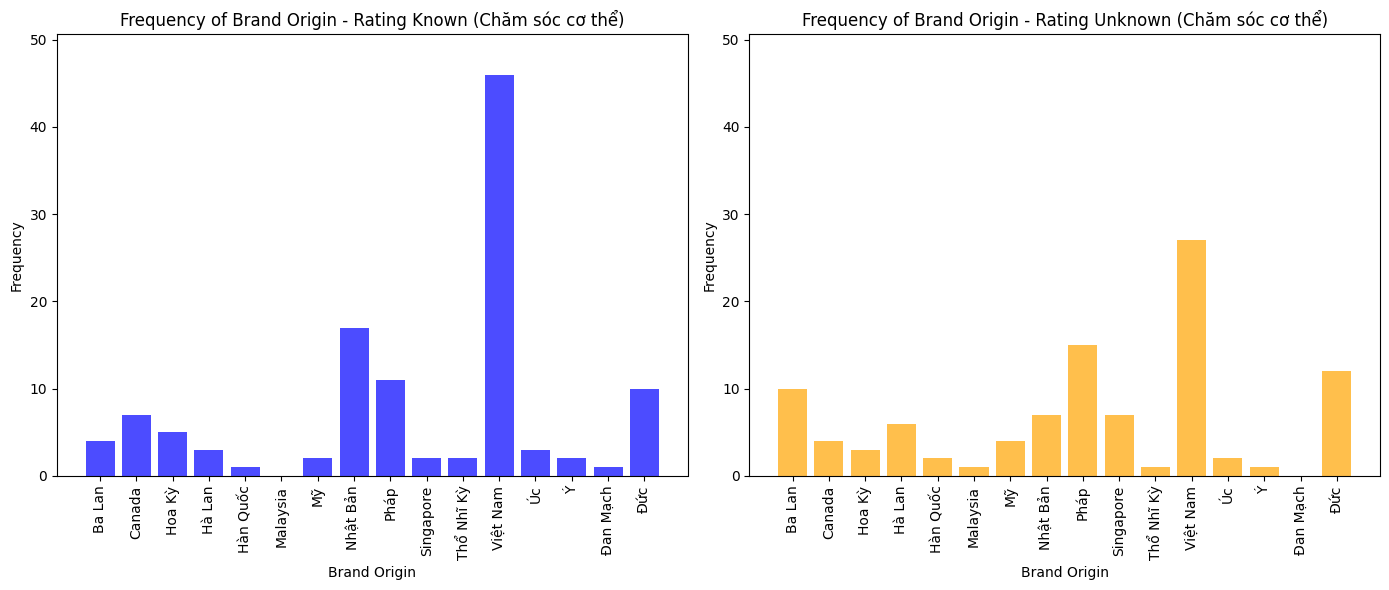

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


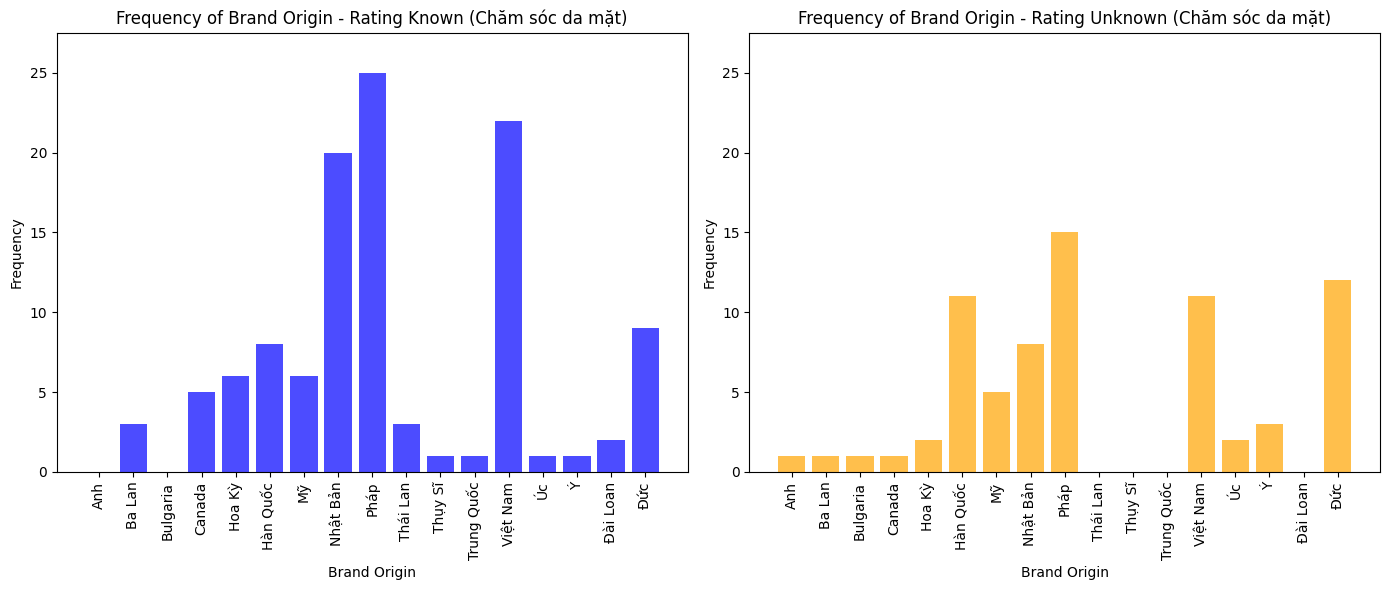

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


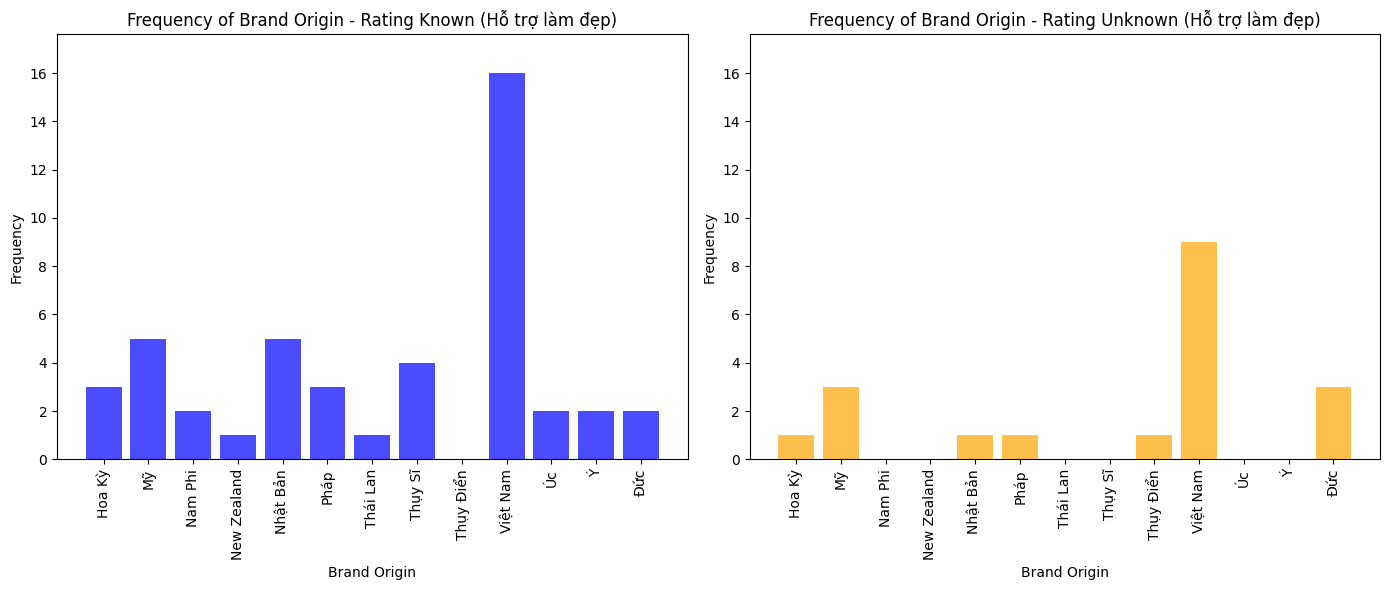

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


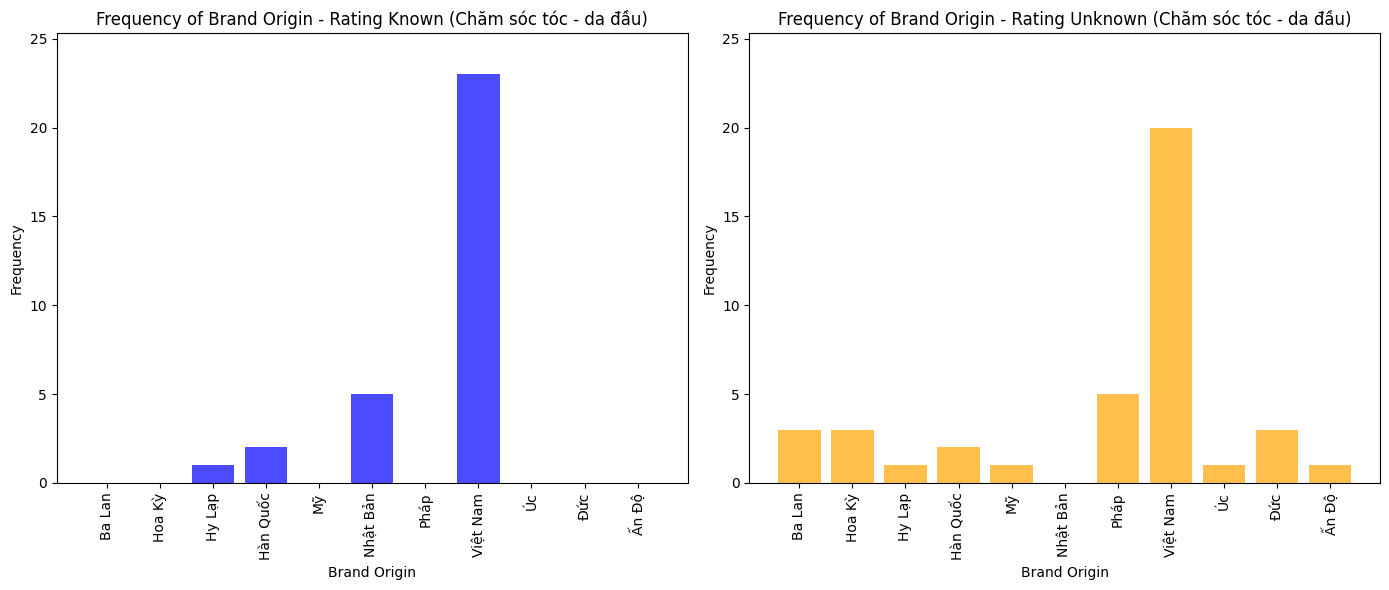

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


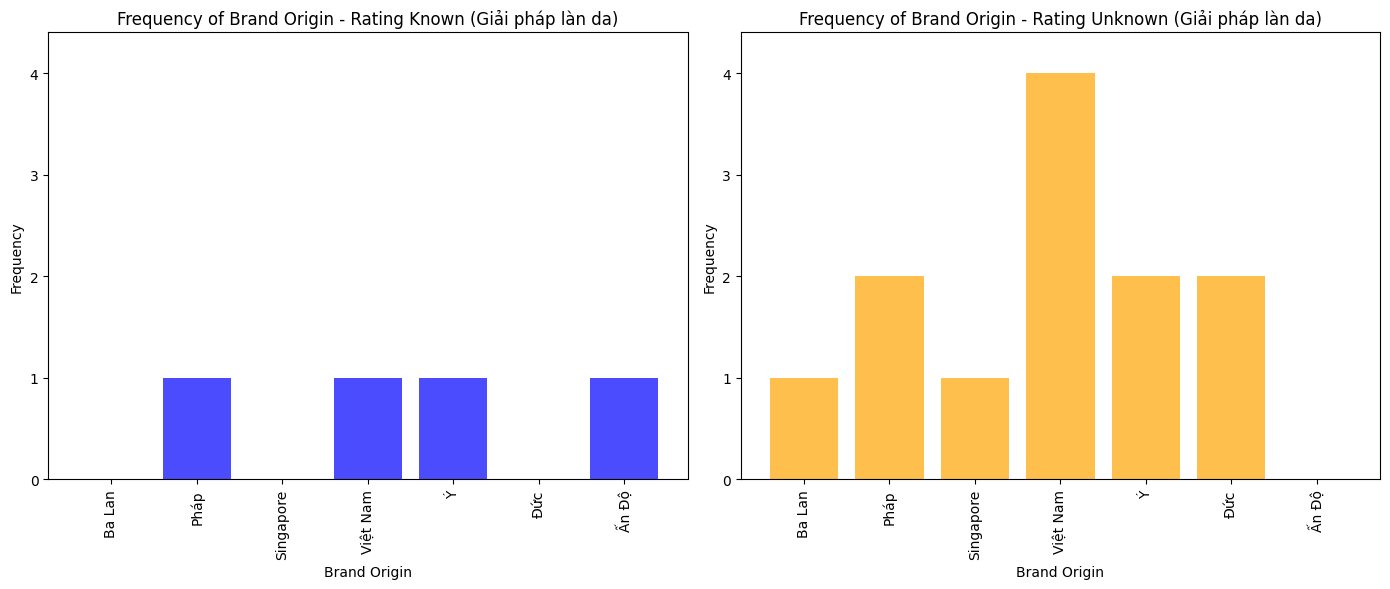

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


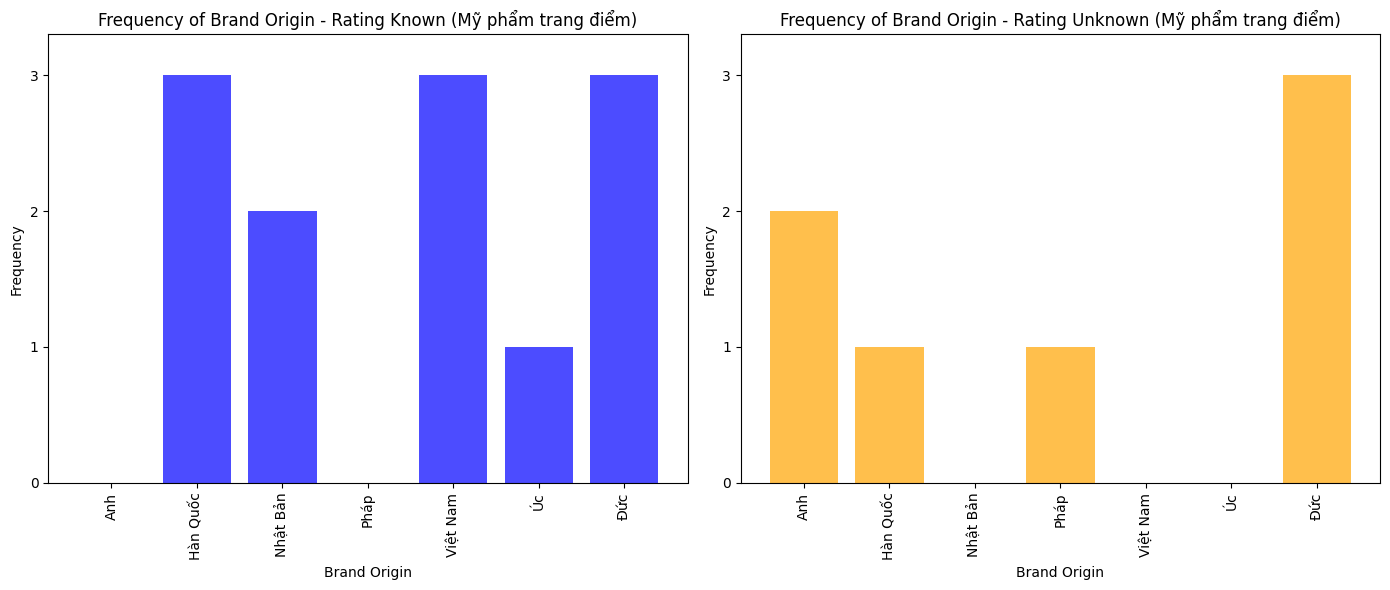

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


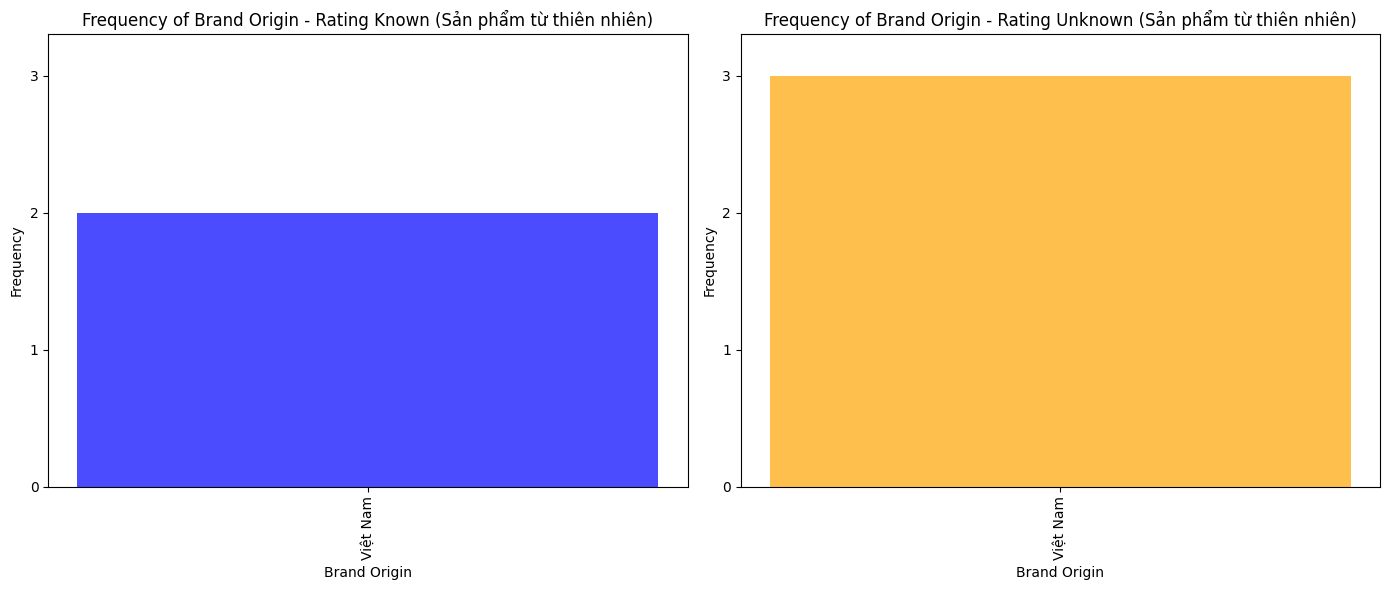

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


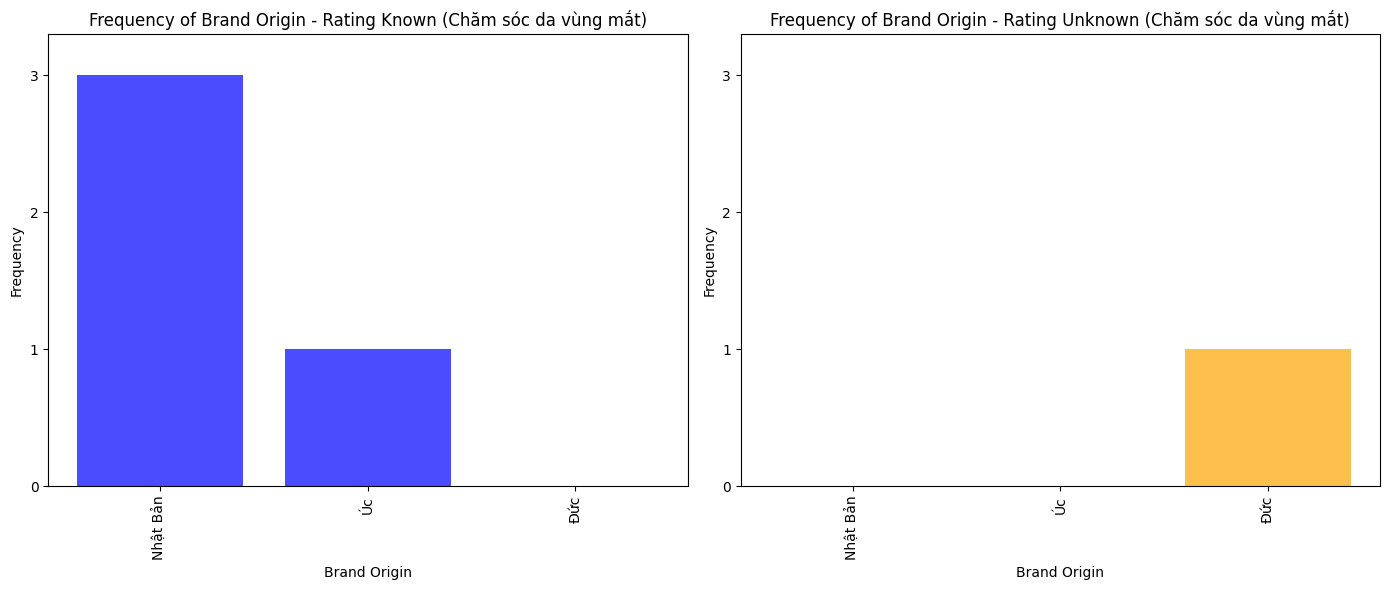

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


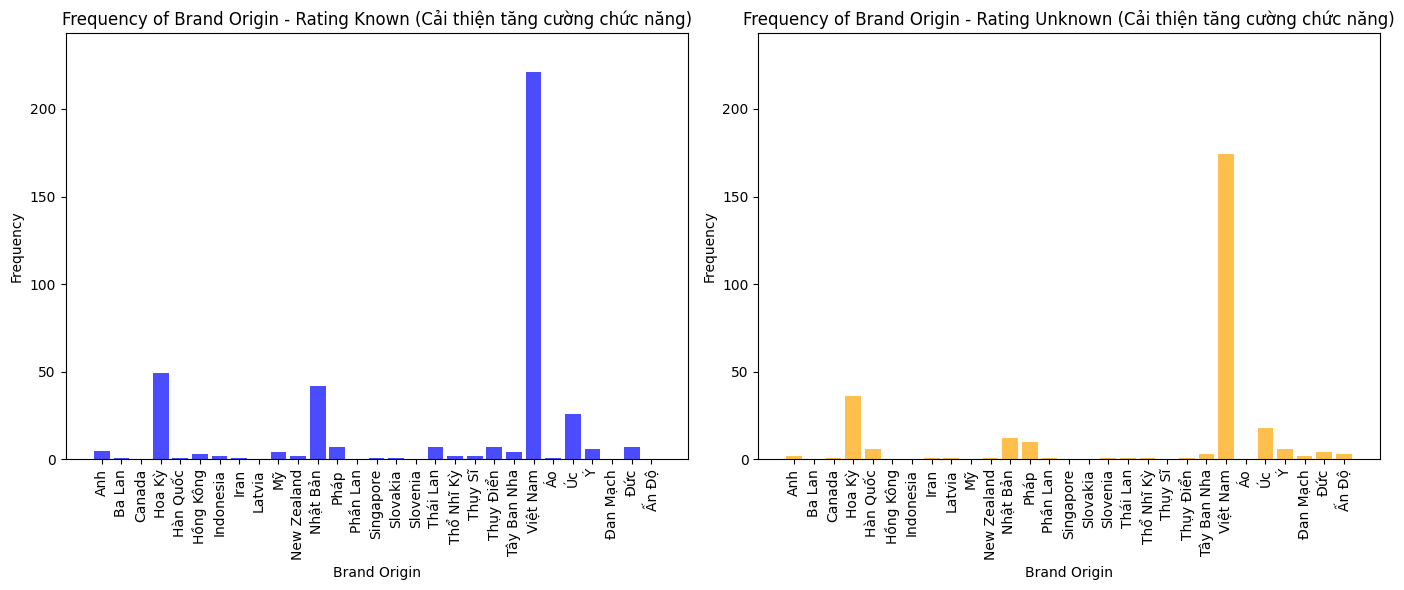

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


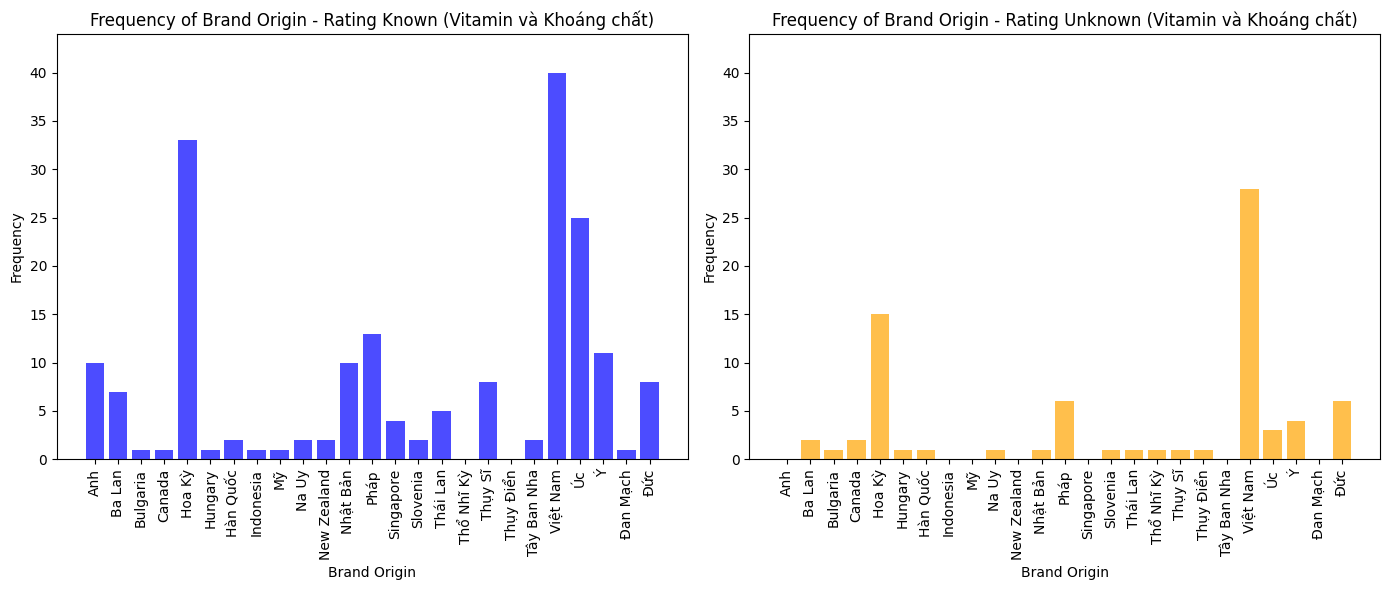

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


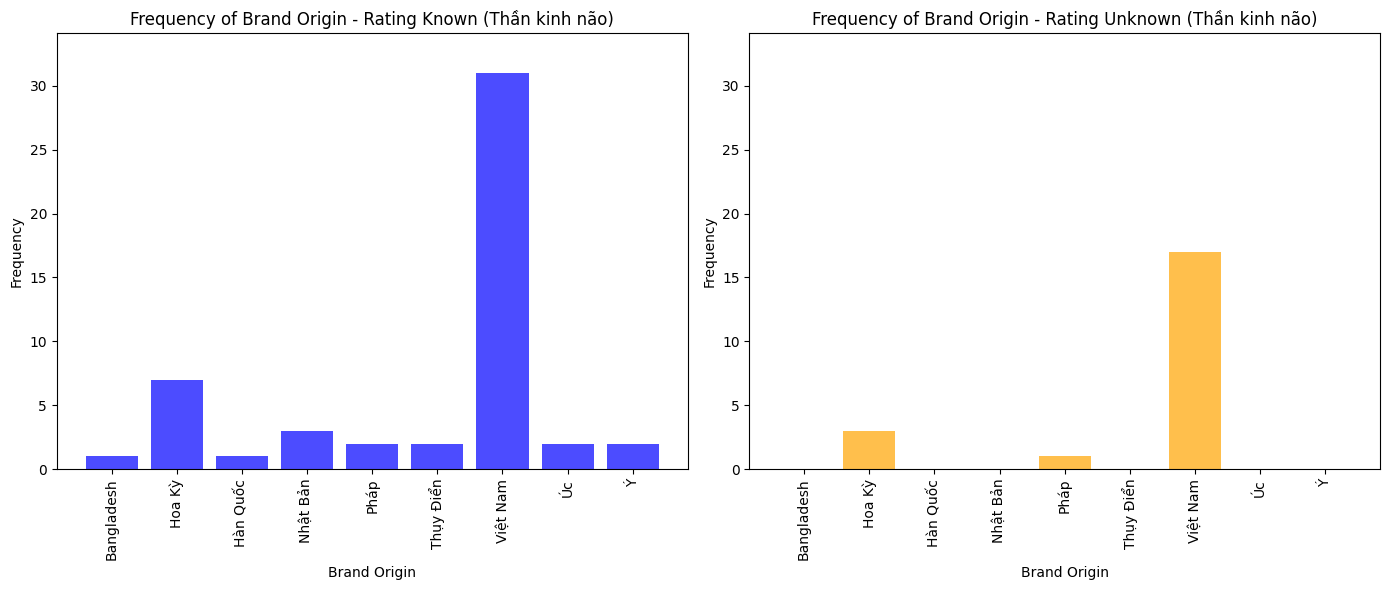

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


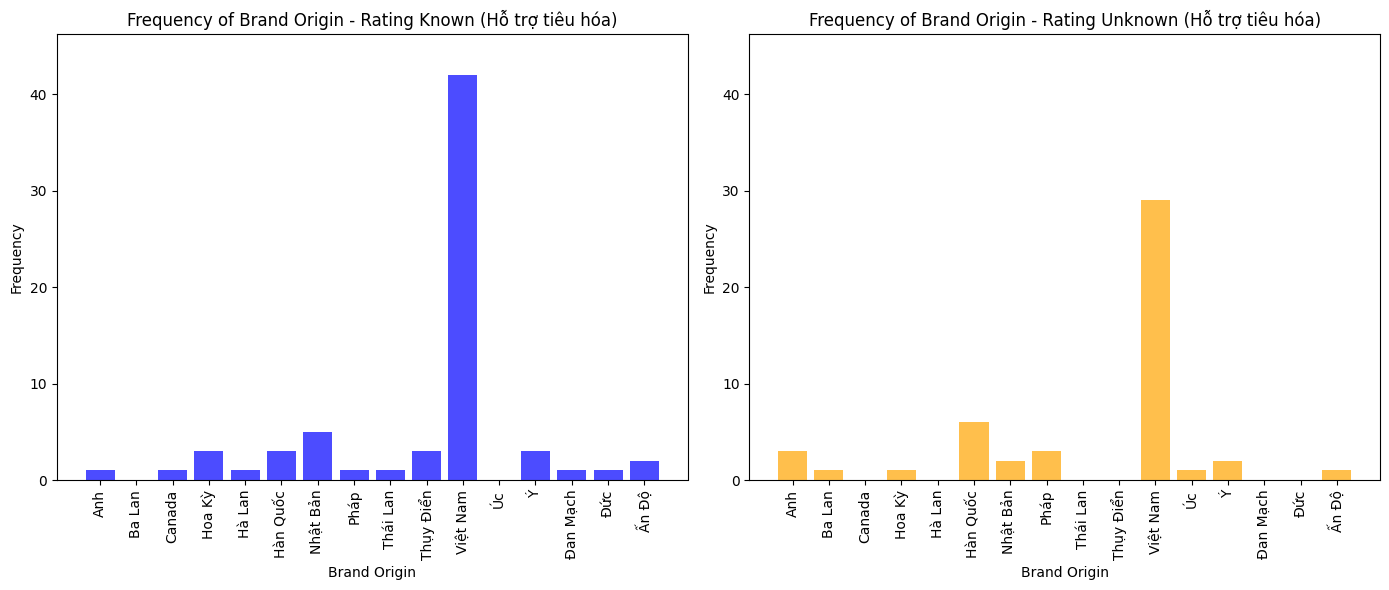

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


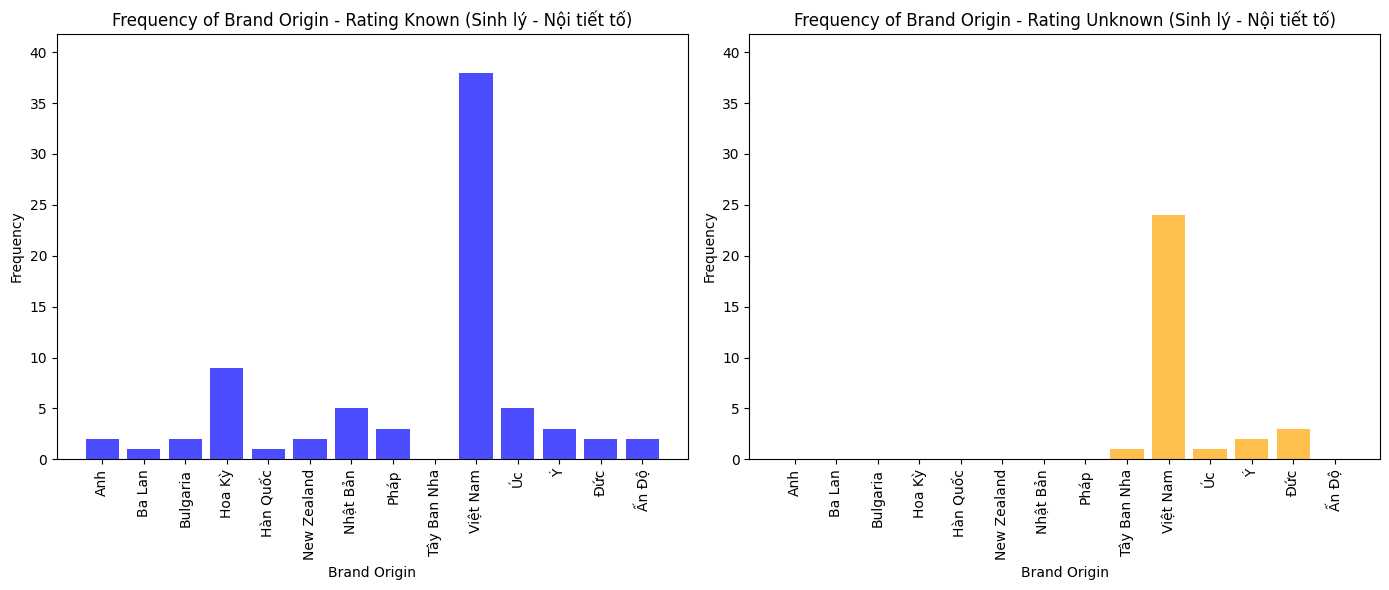

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


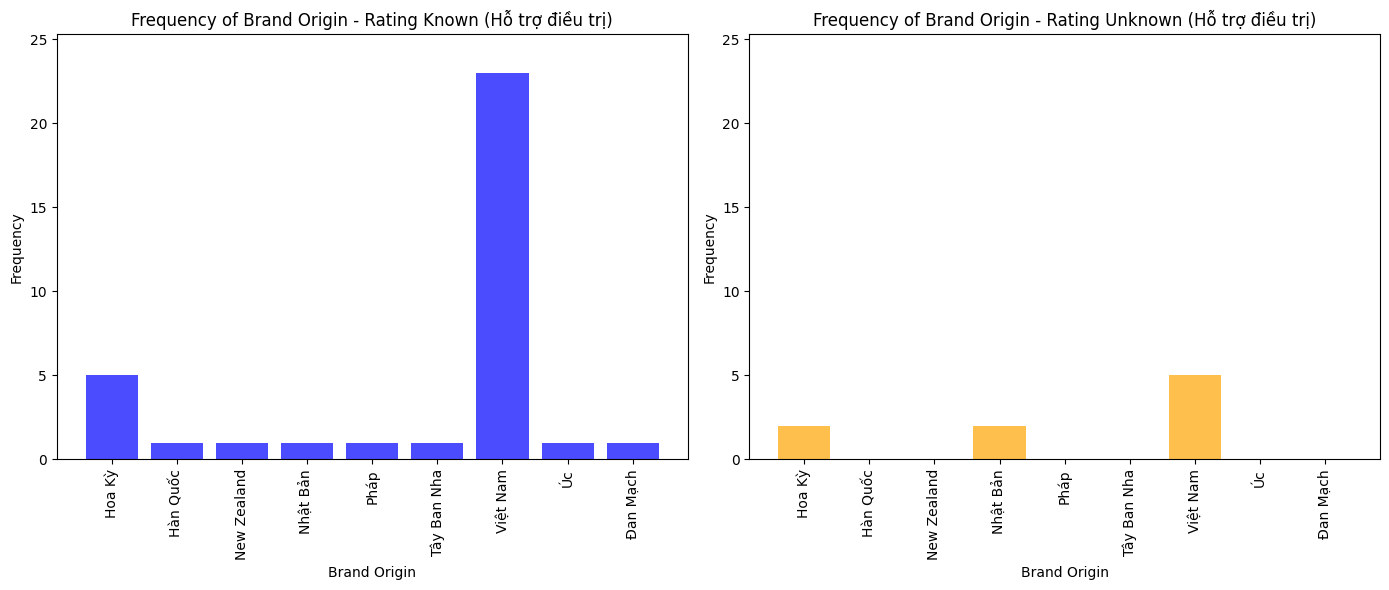

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


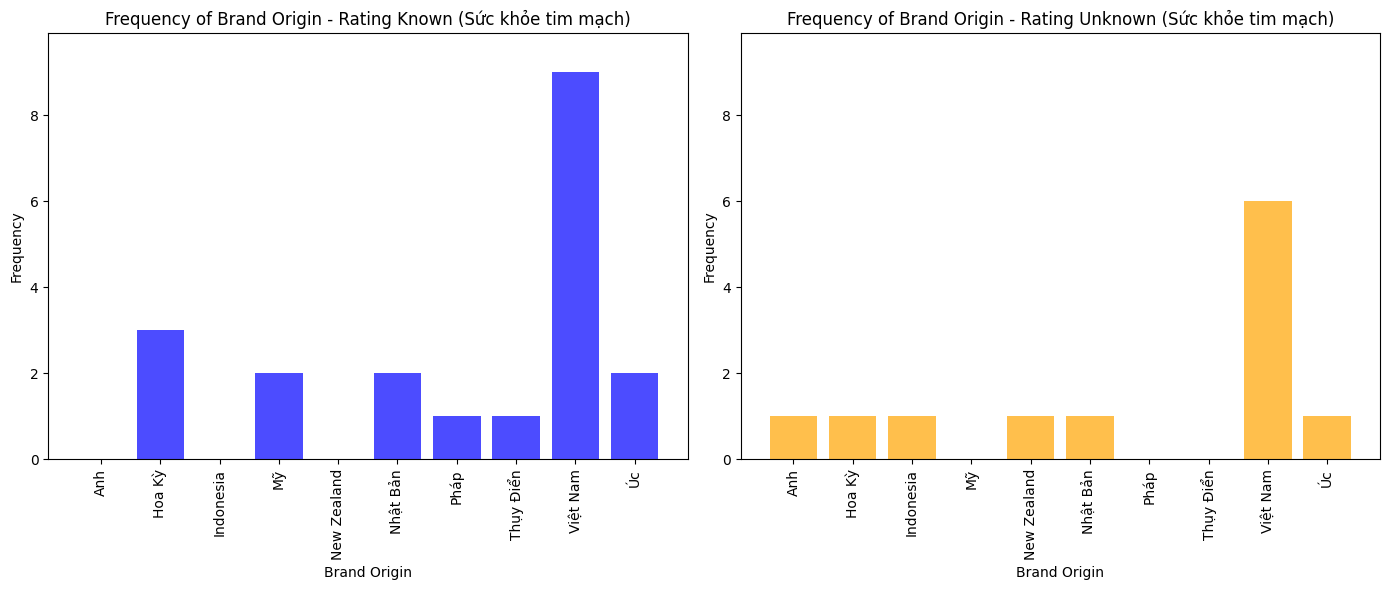

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


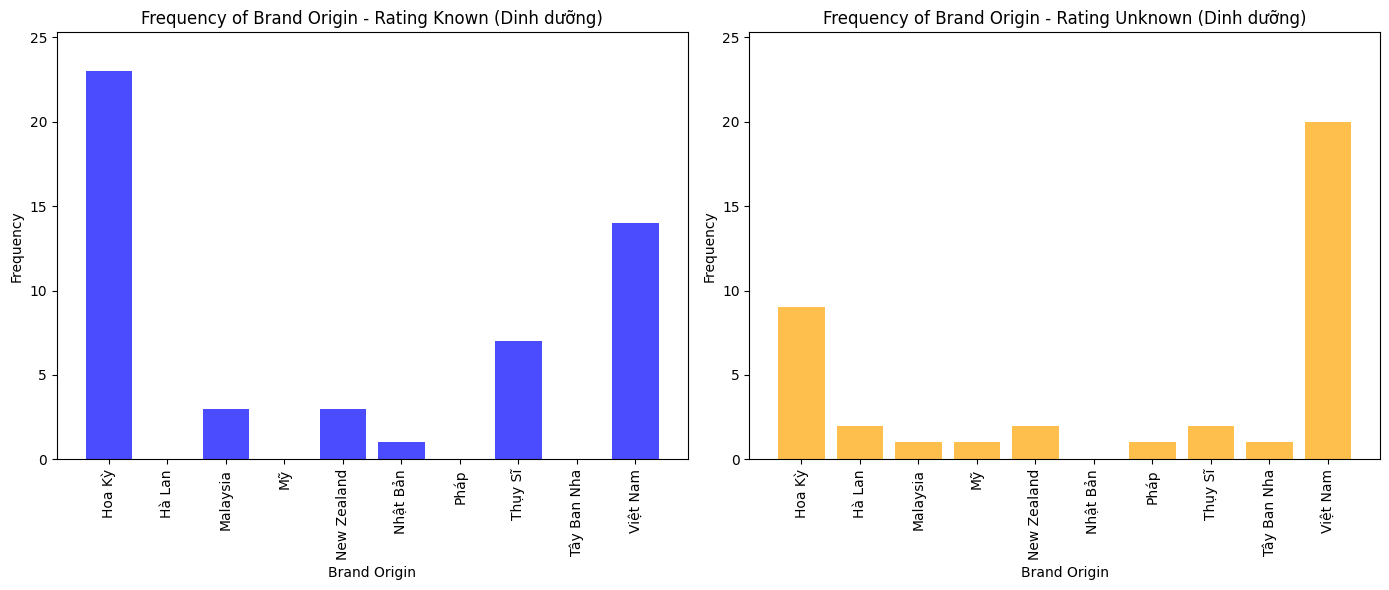

In [8]:
for func in unique_func:
    frequence_countries_by_general_function(func)

- In the categories "Body Care", "Facial Care", "Beauty Support", "Makeup Cosmetics", "Function Enhancement", "Vitamins and Minerals", "Neurological Support", "Digestive Support", "Physiology - Hormones", "Treatment Support", "Cardiovascular Health", "Nutrition".

- In the "Hair - Scalp Care" category, products from France, the USA, and Germany are not of much interest.

- Products in the "Skin Solutions", "Natural Products", and "Eye Area Care" categories seem to be less interesting to users as the number of products appearing in these categories is not significant.

- In "Neurological Support", although products in this category originate from Japan, Italy, Australia, Sweden, South Korea, and Bangladesh in small quantities, they are all of interest.

- In "Physiology - Hormones", products originating from Spain are not of interest.

- "Facial Care" products from France are significantly more popular.

- In "Cardiovascular Health", products from the UK, Indonesia, and New Zealand are not of interest, whereas those from France and Sweden are more popular. 

=> The country of origin does not greatly influence the purchasing decision.

In [9]:
def top_origin_countries_by_general_function(func: str, data: pd.DataFrame, n: int = 3):
    # Filter rating data by 'General_function'
    func_rating_df = data[data['General_function'] == func]

    # Count occurrences of each country
    func_rating_counts = func_rating_df['Brand Origin'].value_counts()

    # Return the top countries with the highest counts
    top_countries = func_rating_counts.head(n).index.tolist()
    
    return top_countries


#### Top 3 Countries of Popular for Each Product Function

In [10]:
for func in unique_func:
    top_3_countries = top_origin_countries_by_general_function(func, rating_df)
    if top_3_countries:  # Chỉ in nếu có dữ liệu top 3
        print(f"General Function: {func}")
        print(f"Top 3 Origin Countries: {', '.join(top_3_countries)}")
        print("-" * 50)
        print()


General Function: Chăm sóc cơ thể
Top 3 Origin Countries: Việt Nam, Nhật Bản, Pháp
--------------------------------------------------

General Function: Chăm sóc da mặt
Top 3 Origin Countries: Pháp, Việt Nam, Nhật Bản
--------------------------------------------------

General Function: Hỗ trợ làm đẹp
Top 3 Origin Countries: Việt Nam, Nhật Bản, Mỹ
--------------------------------------------------

General Function: Chăm sóc tóc - da đầu
Top 3 Origin Countries: Việt Nam, Nhật Bản, Hàn Quốc
--------------------------------------------------

General Function: Giải pháp làn da
Top 3 Origin Countries: Việt Nam, Ấn Độ, Ý
--------------------------------------------------

General Function: Mỹ phẩm trang điểm
Top 3 Origin Countries: Hàn Quốc, Việt Nam, Đức
--------------------------------------------------

General Function: Sản phẩm từ thiên nhiên
Top 3 Origin Countries: Việt Nam
--------------------------------------------------

General Function: Chăm sóc da vùng mắt
Top 3 Origin Countri

#### Top 3 Countries of not Popular for Each Product Function

In [11]:
# Check top 3 countries
for func in unique_func:
    top_3_countries = top_origin_countries_by_general_function(func, unrating_df)
    if top_3_countries: 
        print(f"General Function: {func}")
        print(f"Top 3 Origin Countries: {', '.join(top_3_countries)}")
        print("-" * 50)
        print()


General Function: Chăm sóc cơ thể
Top 3 Origin Countries: Việt Nam, Pháp, Đức
--------------------------------------------------

General Function: Chăm sóc da mặt
Top 3 Origin Countries: Pháp, Đức, Hàn Quốc
--------------------------------------------------

General Function: Hỗ trợ làm đẹp
Top 3 Origin Countries: Việt Nam, Mỹ, Đức
--------------------------------------------------

General Function: Chăm sóc tóc - da đầu
Top 3 Origin Countries: Việt Nam, Pháp, Đức
--------------------------------------------------

General Function: Giải pháp làn da
Top 3 Origin Countries: Việt Nam, Pháp, Đức
--------------------------------------------------

General Function: Mỹ phẩm trang điểm
Top 3 Origin Countries: Đức, Anh, Hàn Quốc
--------------------------------------------------

General Function: Sản phẩm từ thiên nhiên
Top 3 Origin Countries: Việt Nam
--------------------------------------------------

General Function: Chăm sóc da vùng mắt
Top 3 Origin Countries: Đức
--------------------

In [12]:
def plot_price_boxplot_top3_countries(func: str):
    # Get top 3 countries for the function from rating_df and unrating_df
    top_3_countries_rating = top_origin_countries_by_general_function(func, rating_df)
    top_3_countries_unrating = top_origin_countries_by_general_function(func, unrating_df)
    
    # Filter rating_df for the top 3 countries
    func_rating_df = rating_df[(rating_df['General_function'] == func) & (rating_df['Brand Origin'].isin(top_3_countries_rating))]
    
    # Filter unrating_df for the top 3 countries
    func_unrating_df = unrating_df[(unrating_df['General_function'] == func) & (unrating_df['Brand Origin'].isin(top_3_countries_unrating))]

    # Skip if both DataFrames have no data
    if func_rating_df.empty and func_unrating_df.empty:
        return

    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle(f"Box Plot of Price for General Function: {func} (Top 3 Countries)")
    
    def format_price(x, pos):
        return f'{x:,.0f}'

    # Plot box plot for rating_df
    if not func_rating_df.empty:
        sns.boxplot(ax=axes[0], x='Brand Origin', y='Price', data=func_rating_df)
        axes[0].set_title('Rating')
        axes[0].set_xlabel('Brand Country')
        axes[0].set_ylabel('Price')
        axes[0].tick_params(axis='x', rotation=90)
        axes[0].yaxis.set_major_formatter(FuncFormatter(format_price))

    # Plot box plot for unrating_df
    if not func_unrating_df.empty:
        sns.boxplot(ax=axes[1], x='Brand Origin', y='Price', data=func_unrating_df, color='orange')
        axes[1].set_title('Unrating')
        axes[1].set_xlabel('Brand Origin')
        axes[1].tick_params(axis='x', rotation=90)
        axes[1].yaxis.set_major_formatter(FuncFormatter(format_price))

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
    plt.show()


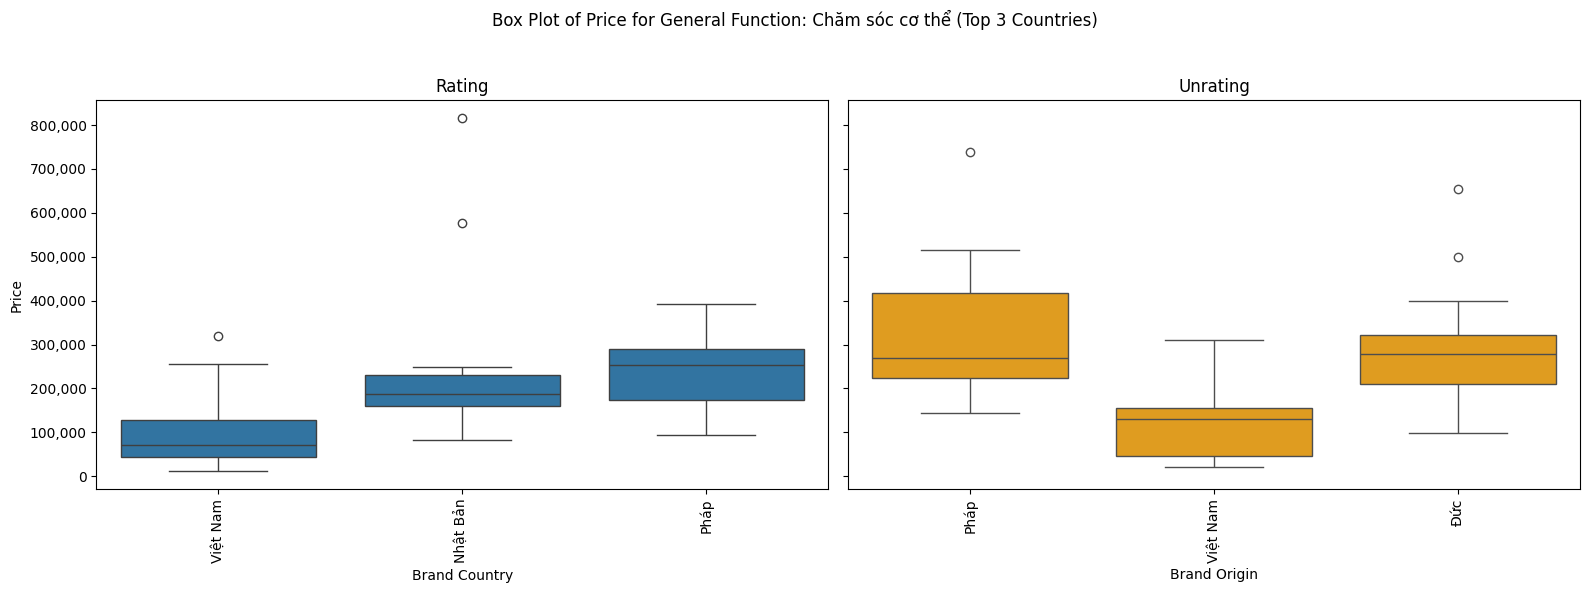

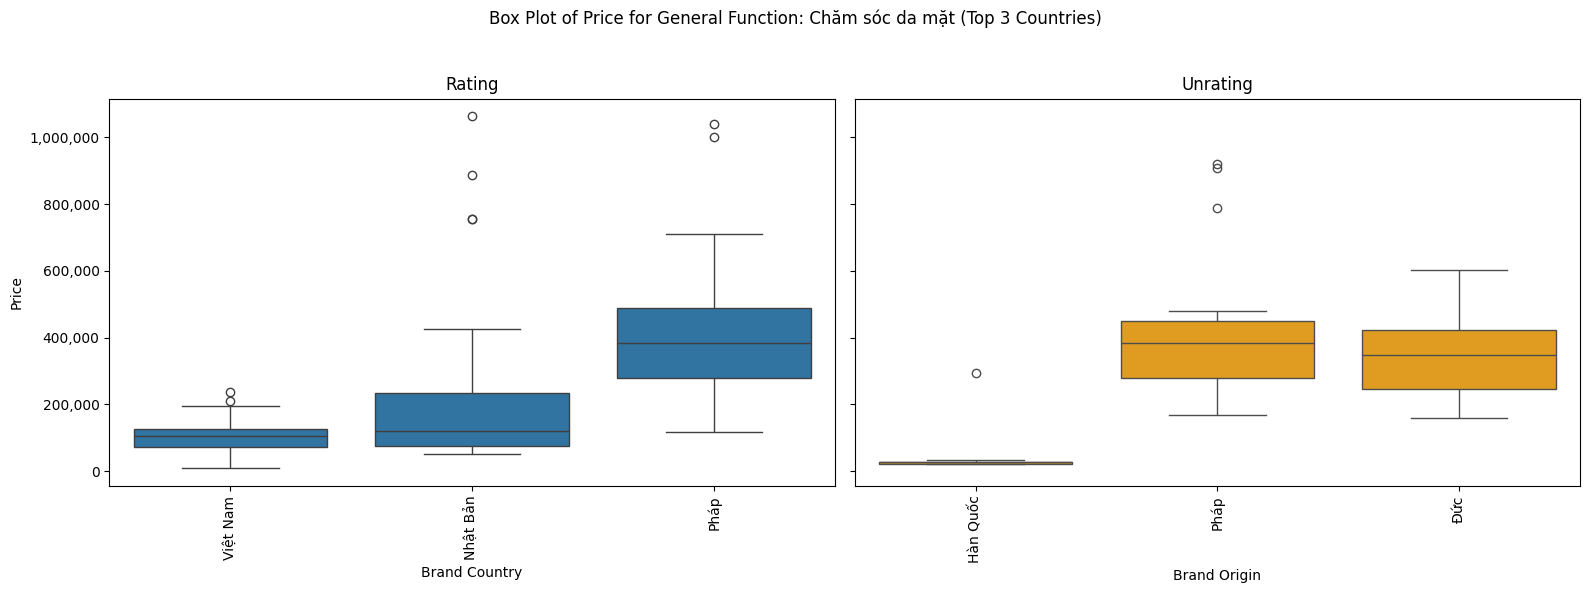

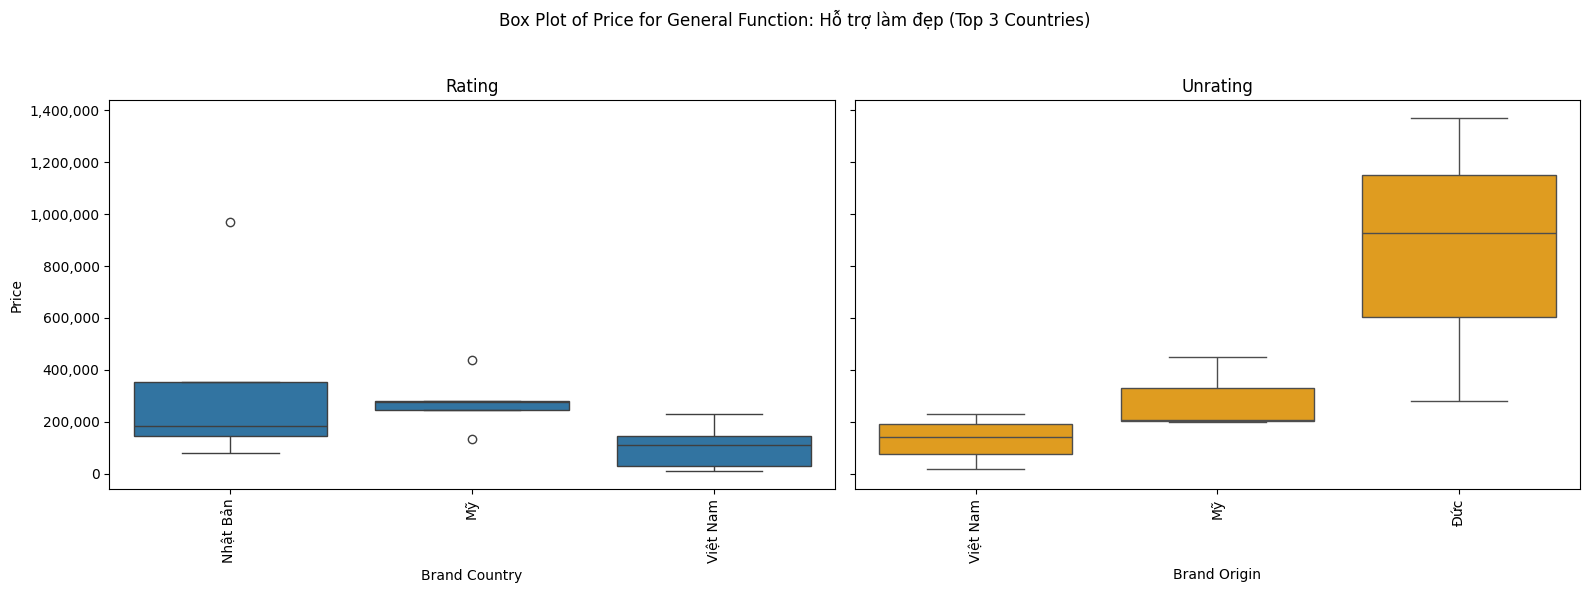

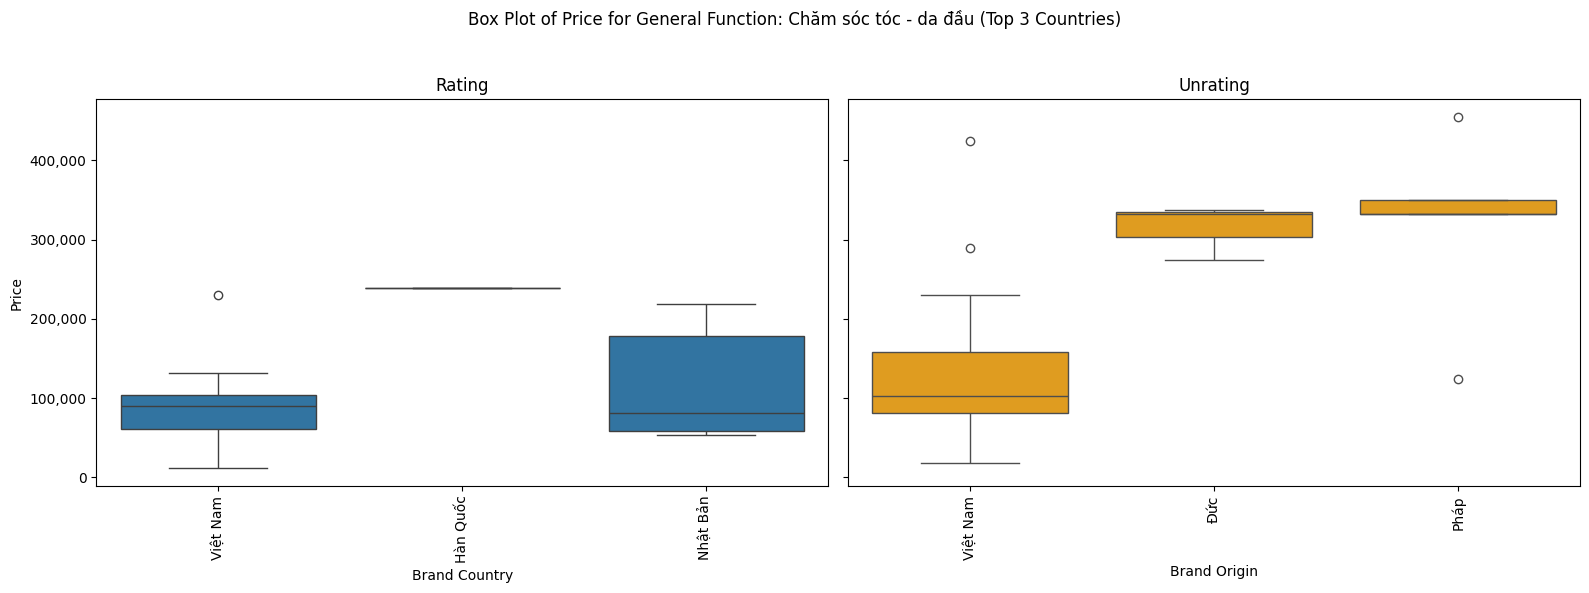

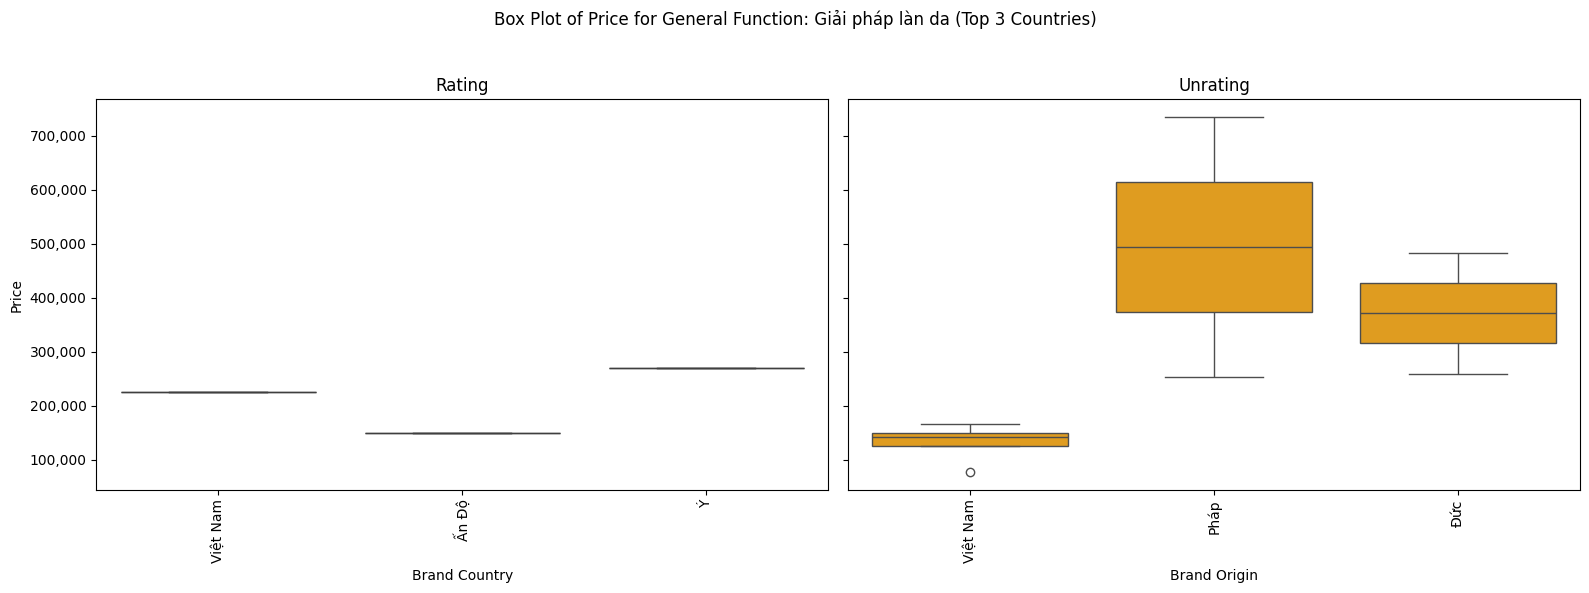

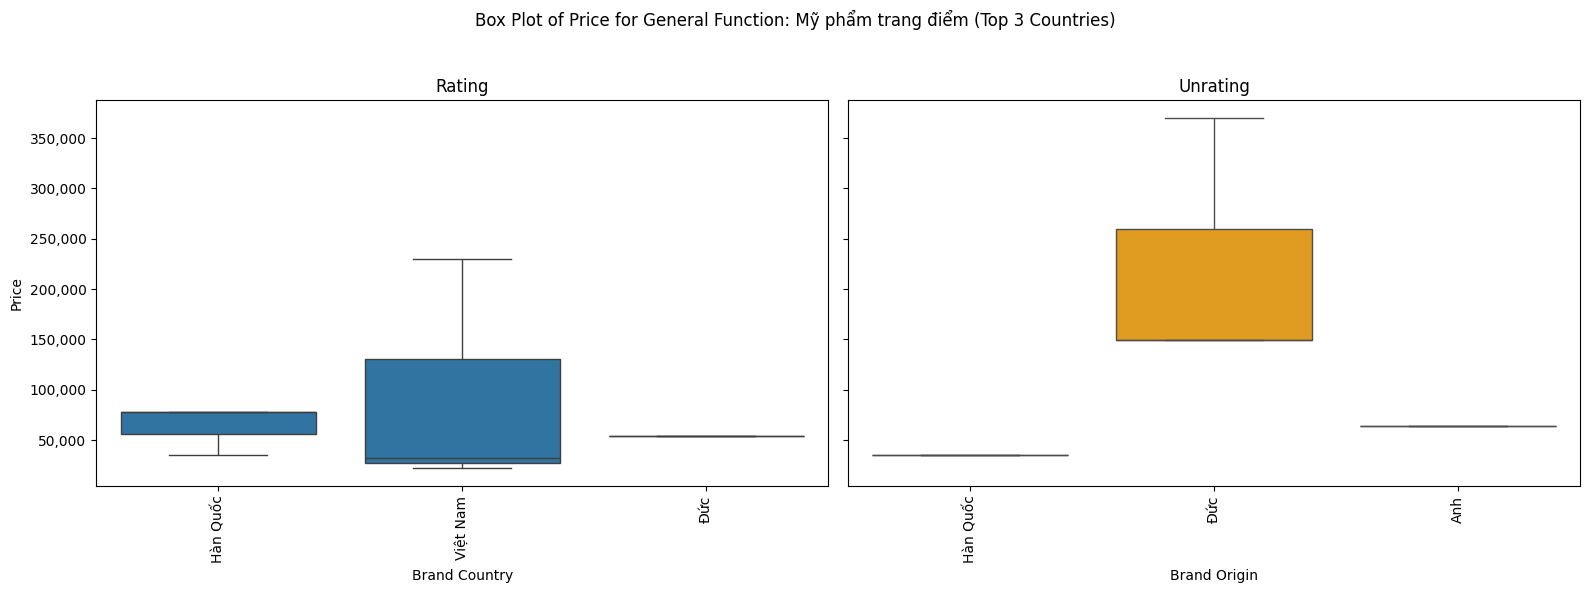

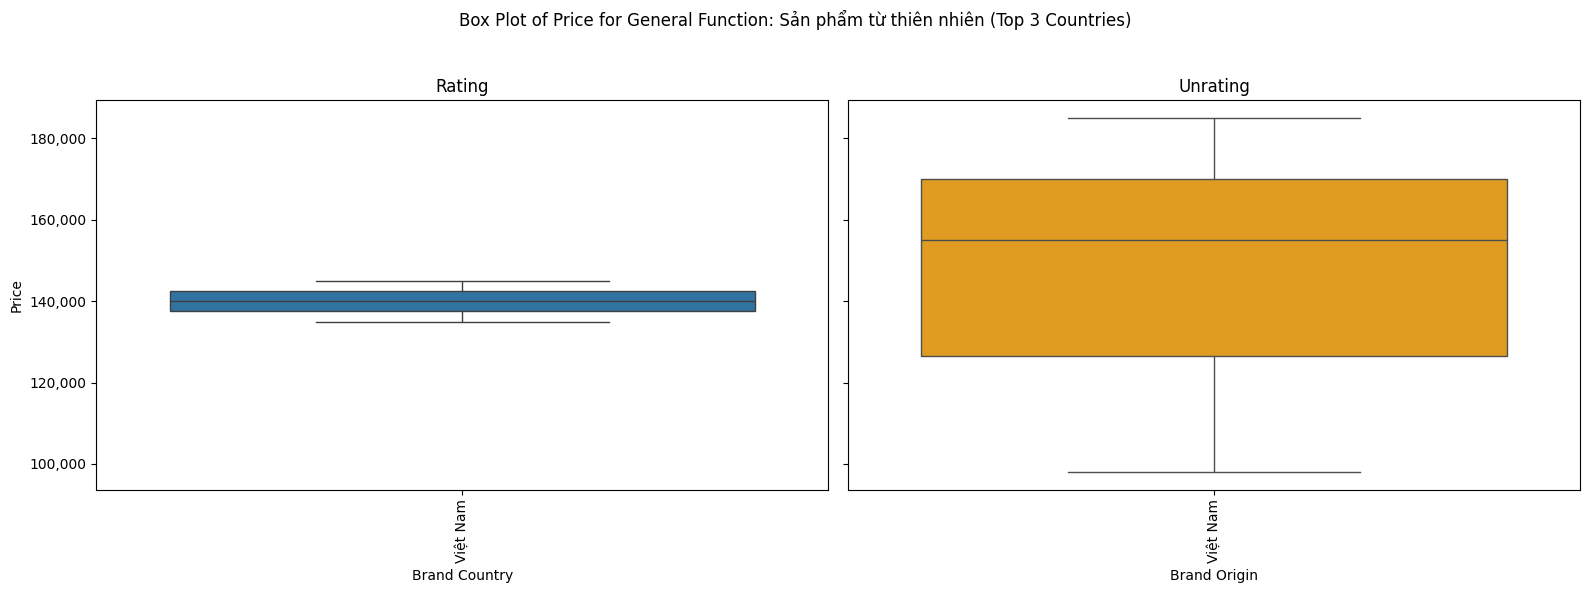

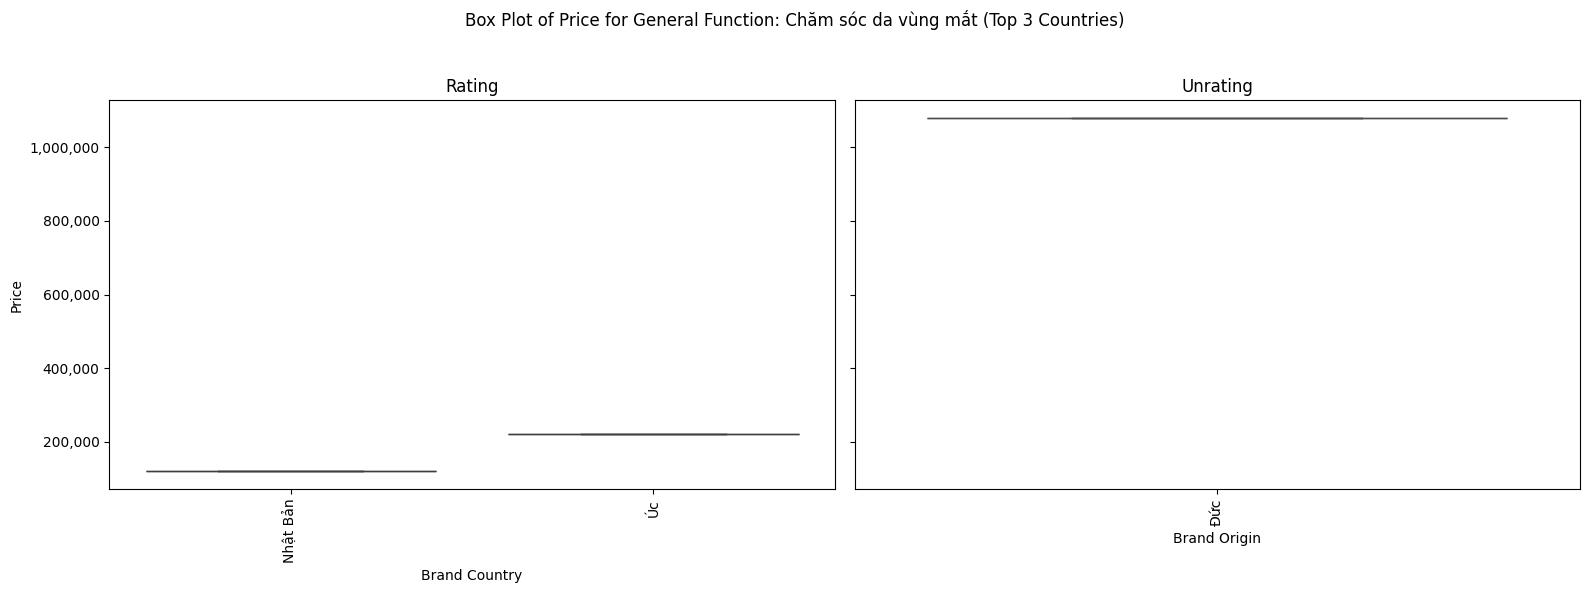

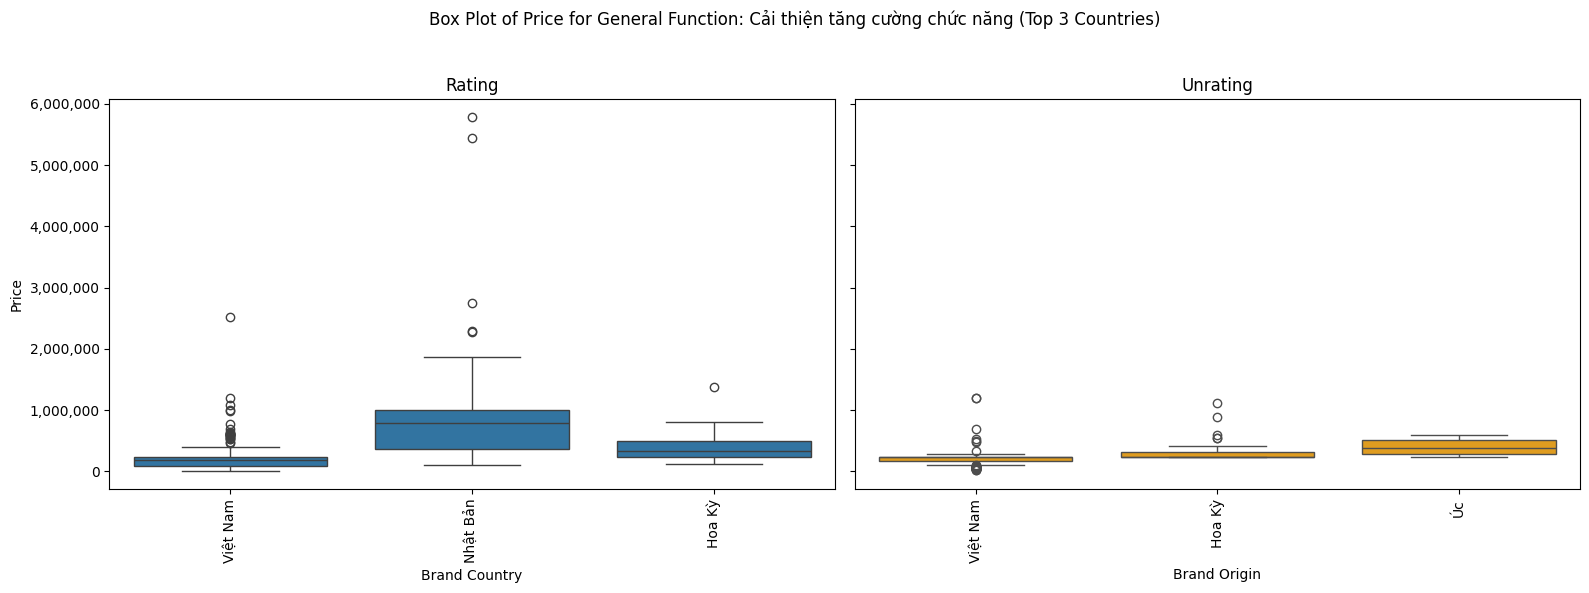

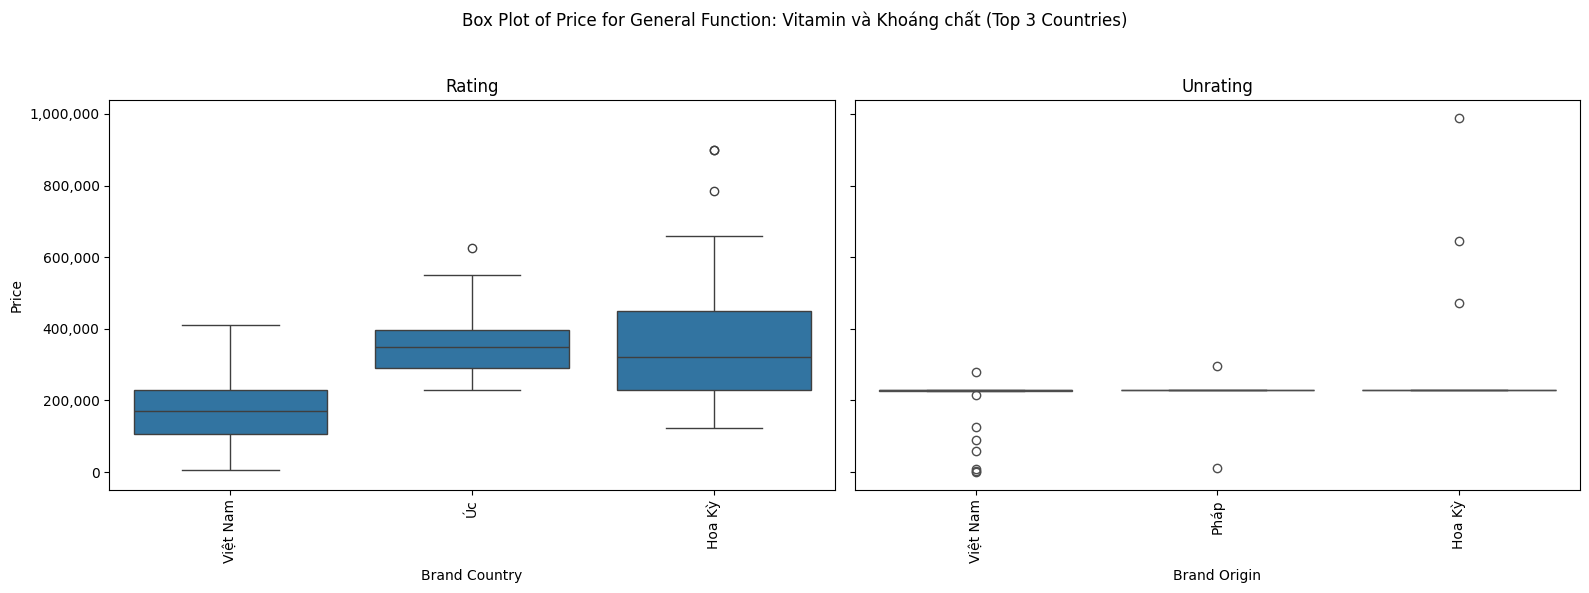

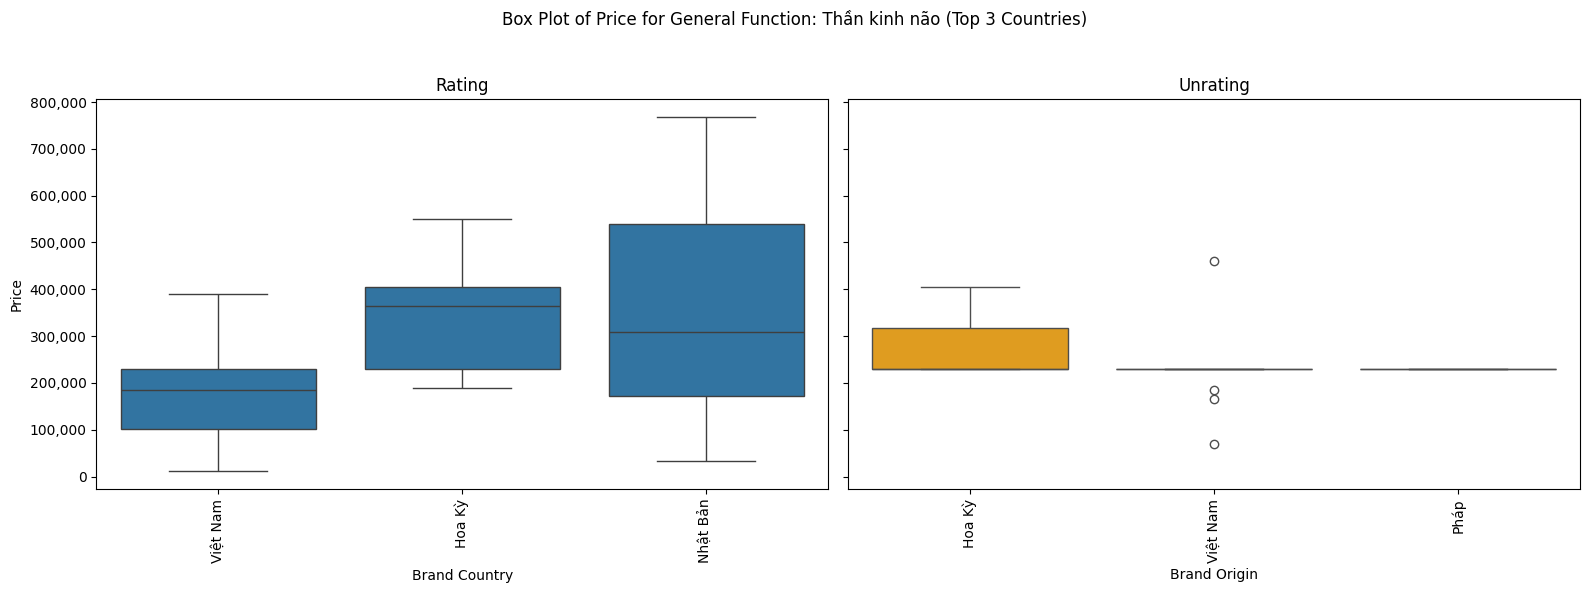

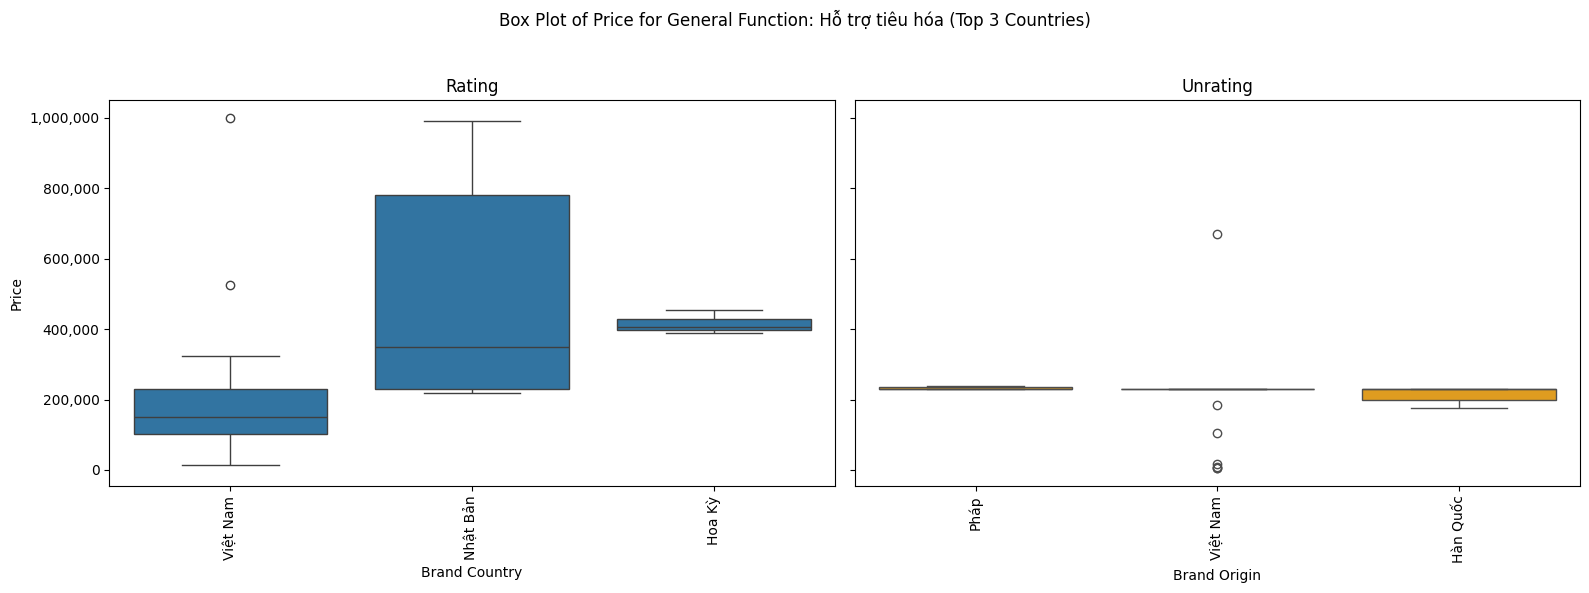

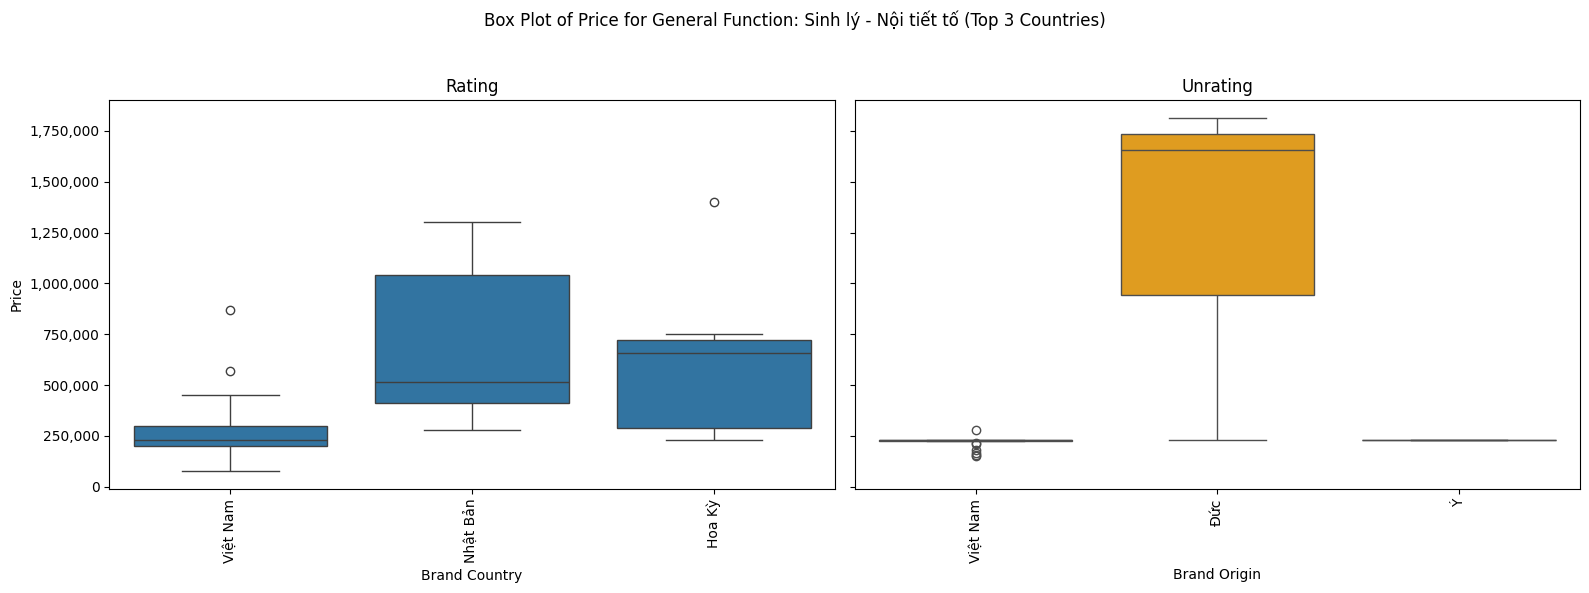

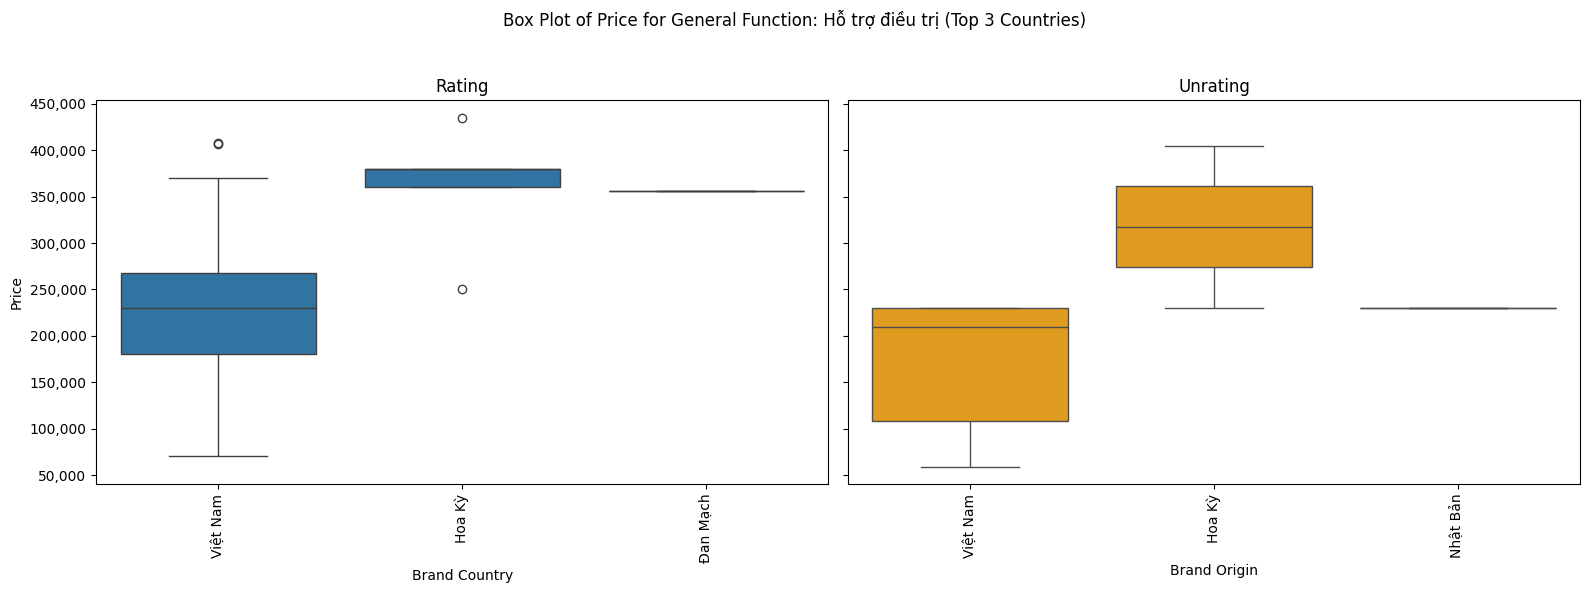

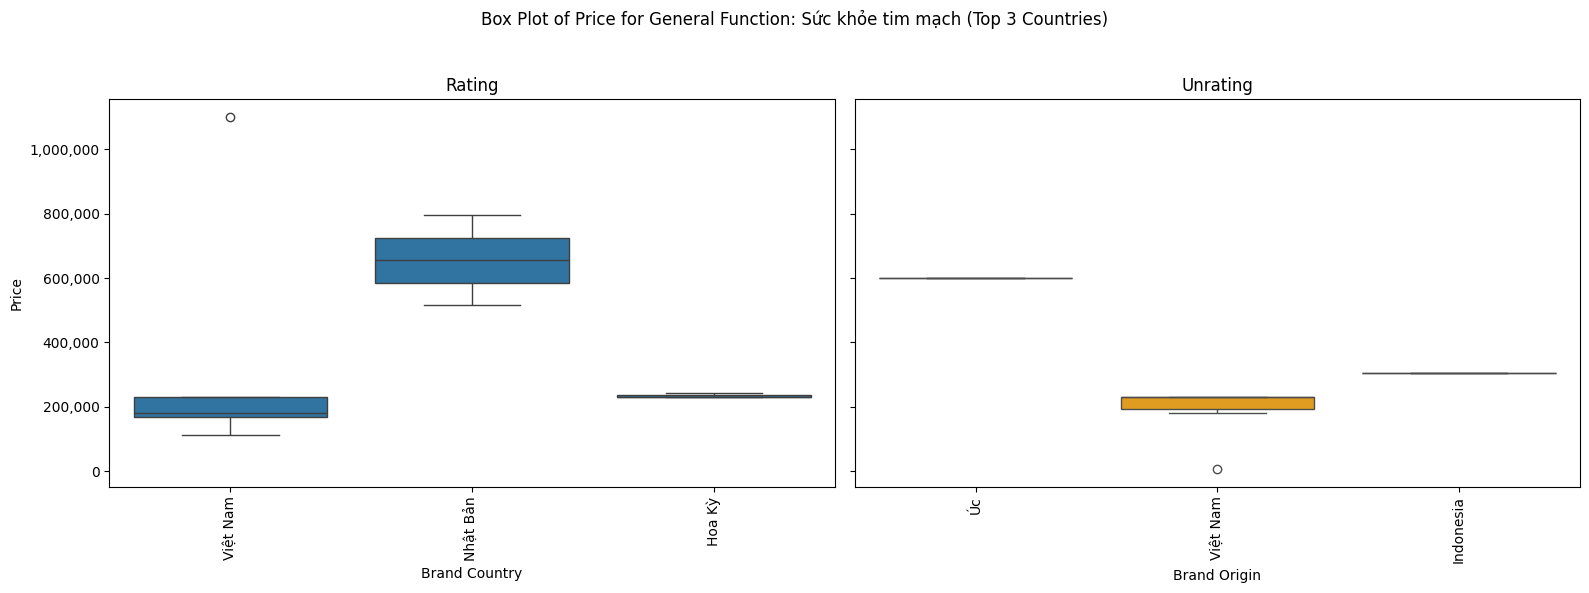

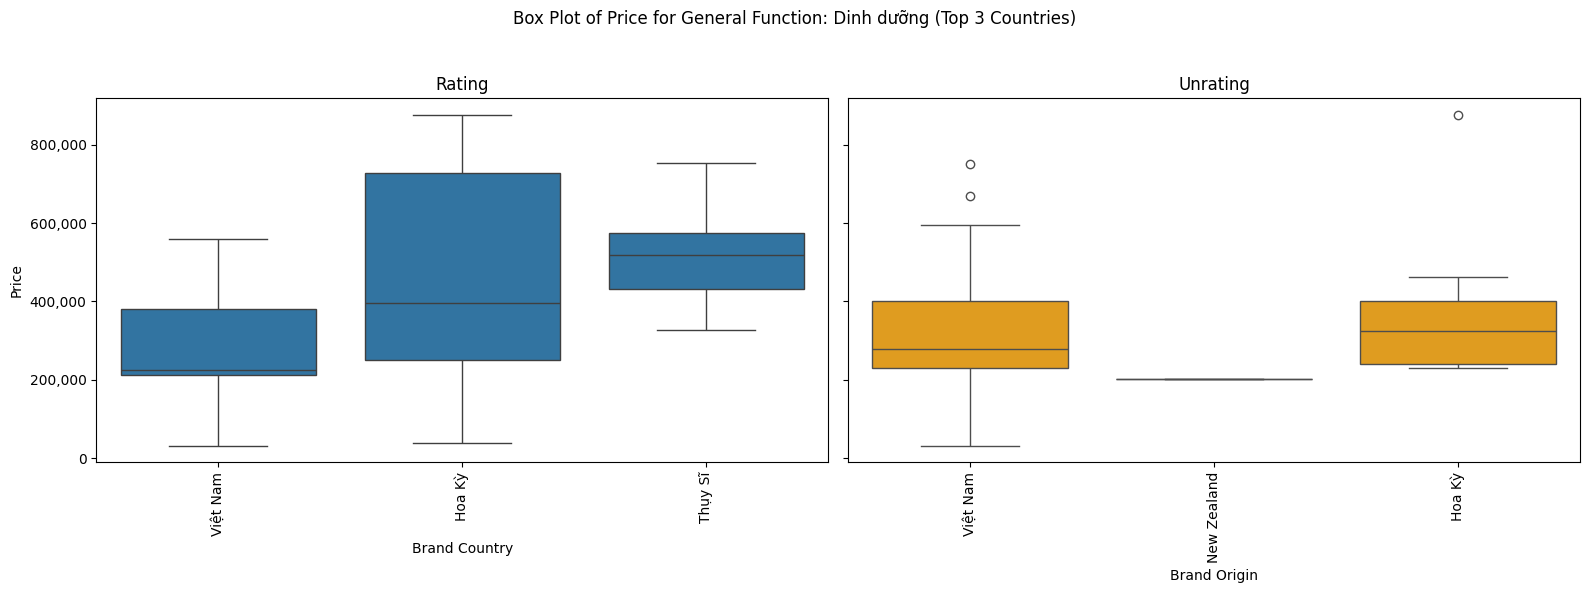

In [13]:
for func in unique_func:
    plot_price_boxplot_top3_countries(func)

- In most functional categories, products that are not of interest are mainly due to high prices.

- However, in functional categories such as "Function Enhancement", "Vitamins and Minerals", "Neurological Support", "Digestive Support", "Cardiovascular Health", and "Nutrition", despite having high price ranges, they are still of interest.

- Physiology - Hormones: Products that are of interest generally have relatively high prices. 

=> Price can influence buyer demand.

In [14]:
def plot_top5_brands_stacked_bar(func: str, dataframe):
    # Get top 3 origin countries for the specific general function
    top_3_countries = top_origin_countries_by_general_function(func, dataframe)
    
    func_df = dataframe[(dataframe['General_function'] == func) & (dataframe['Brand Origin'].isin(top_3_countries))]

    # Get top 5 brands of each country in the top 3 countries
    top5_brands_by_country = {}
    for country in top_3_countries:
        country_df = func_df[func_df['Brand Origin'] == country]
        top_5_brands = country_df['Trademark'].value_counts().nlargest(5).index.tolist()
        top5_brands_by_country[country] = top_5_brands

    # Create a DataFrame to count the occurrence of top 5 brands for each country
    brand_counts = []
    for country, top_5_brands in top5_brands_by_country.items():
        for brand in top_5_brands:
            count = func_df[(func_df['Brand Origin'] == country) & (func_df['Trademark'] == brand)].shape[0]
            brand_counts.append({'Brand Origin': country, 'Trademark': brand, 'Count': count})
    
    brand_counts_df = pd.DataFrame(brand_counts)

    # Pivot the DataFrame to prepare for stacked bar plot
    pivot_df = brand_counts_df.pivot(index='Brand Origin', columns='Trademark', values='Count').fillna(0)

    # Calculate the percentage for each brand in each country
    pivot_percentage_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(12, 8))

    # Plot 100% stacked bar chart
    ax = pivot_percentage_df.plot(kind='bar', stacked=True, figsize=(12, 8), width=0.8)
    plt.title(f"Top 5 Brands Frequency in Top 3 Countries for General Function: {func} (100% Stacked)")
    plt.xlabel("Brand Origin")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)

    plt.legend(title="Brand", bbox_to_anchor=(1.2, 1), loc='upper right', borderaxespad=0.)

    plt.tight_layout()
    plt.show()


<Figure size 1200x800 with 0 Axes>

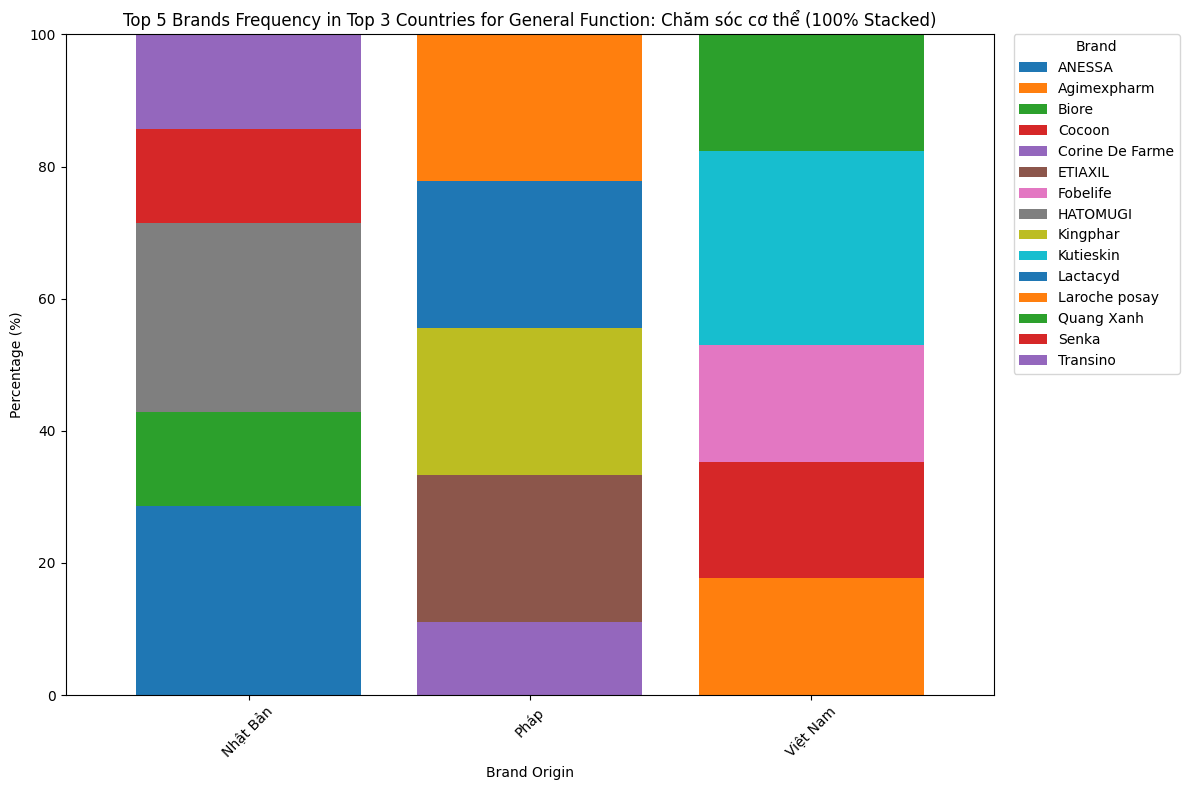

<Figure size 1200x800 with 0 Axes>

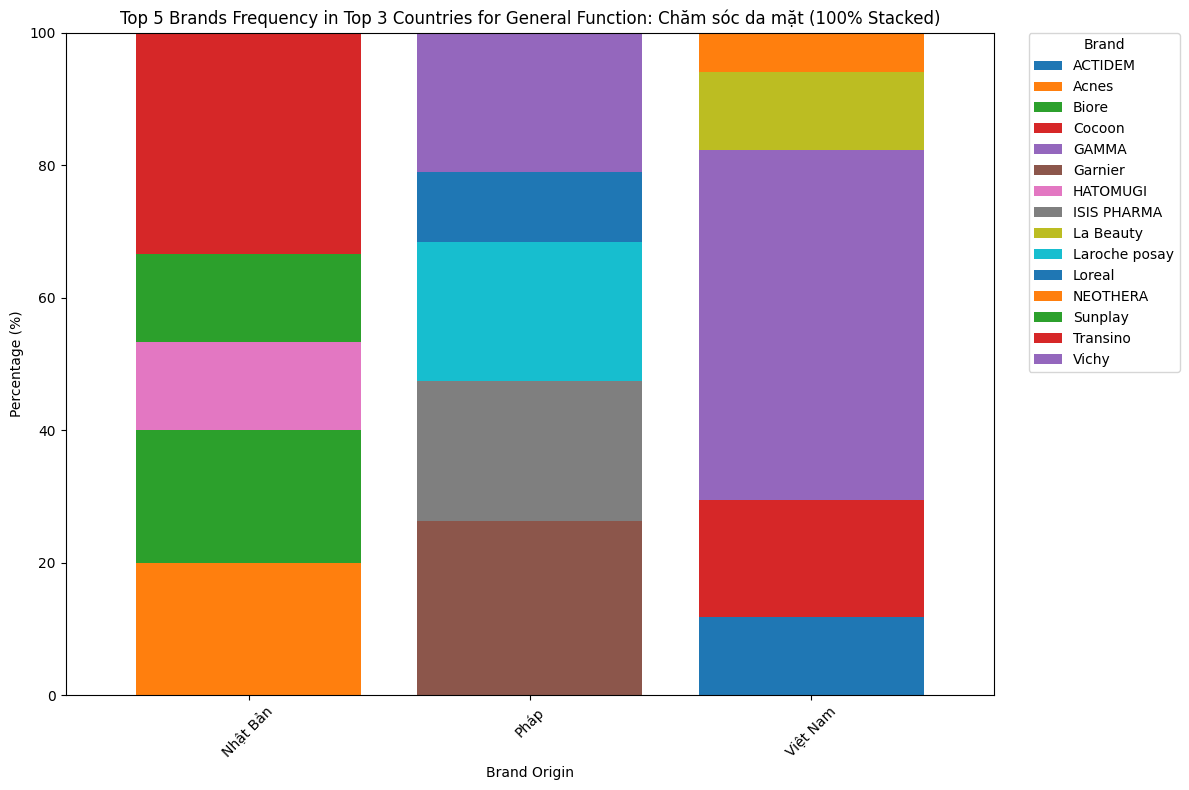

<Figure size 1200x800 with 0 Axes>

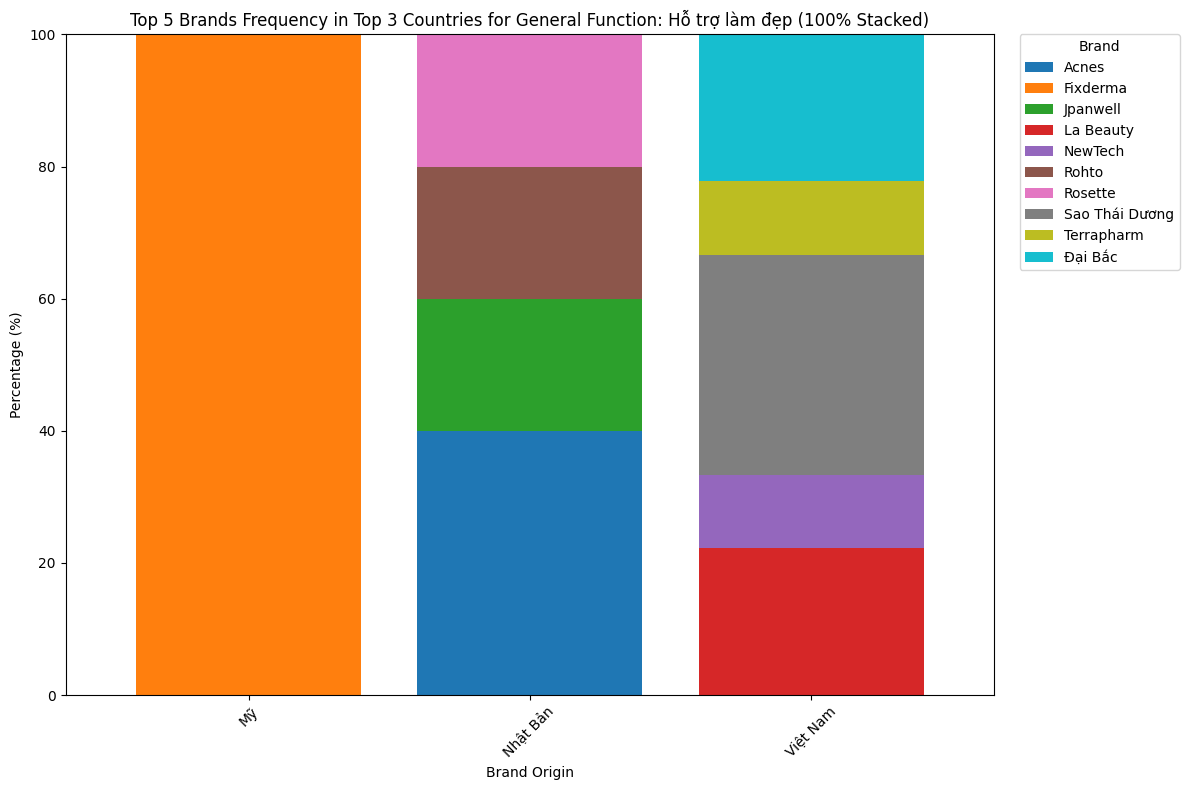

<Figure size 1200x800 with 0 Axes>

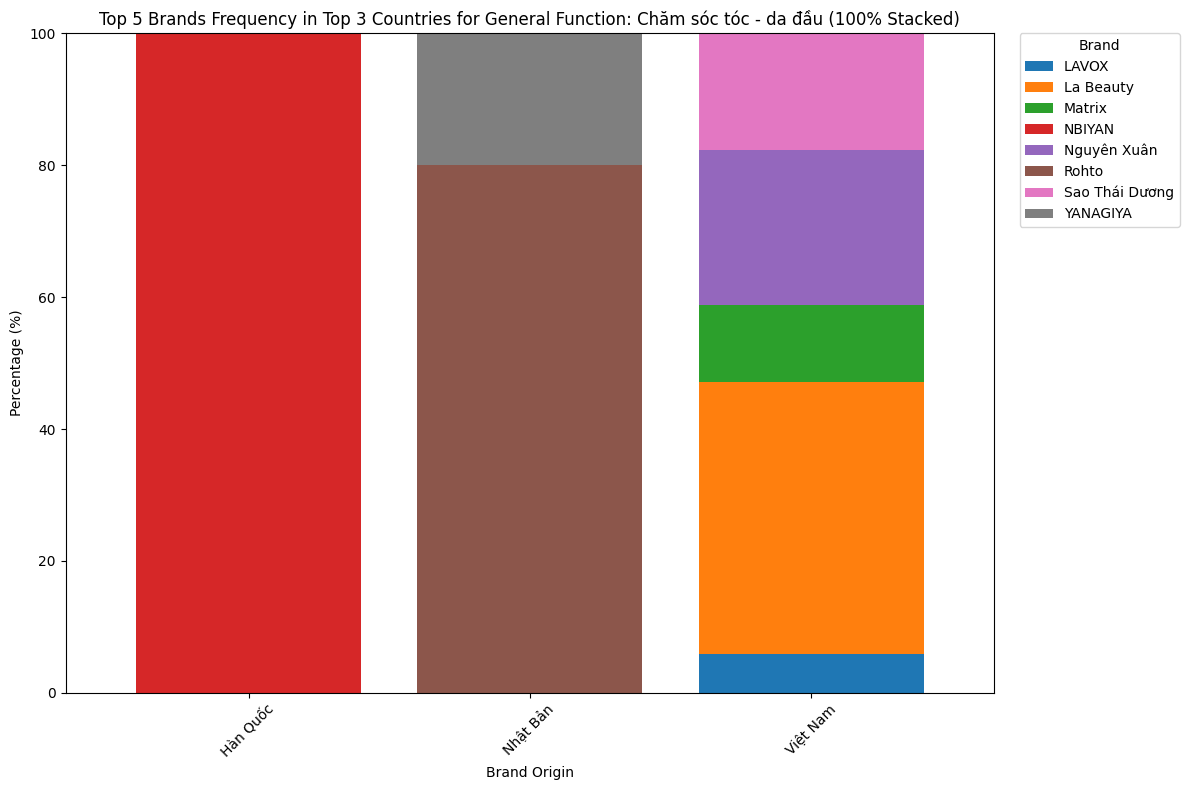

<Figure size 1200x800 with 0 Axes>

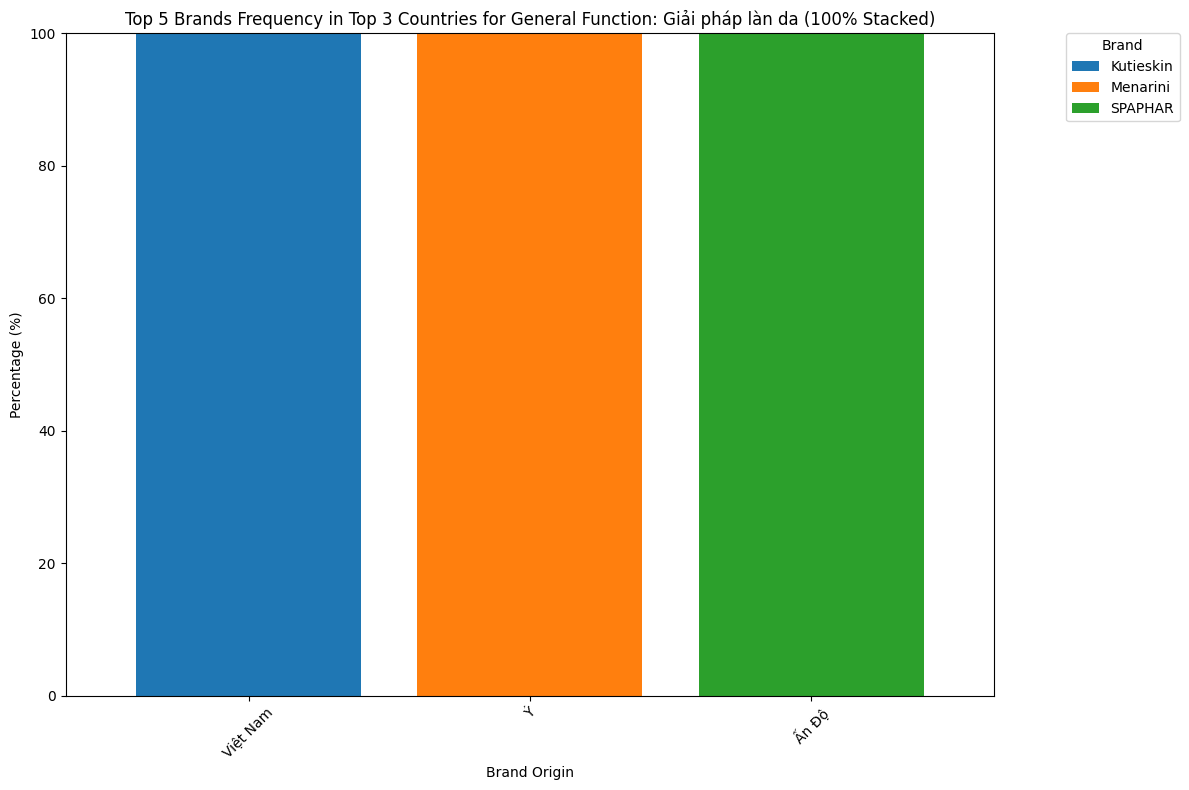

<Figure size 1200x800 with 0 Axes>

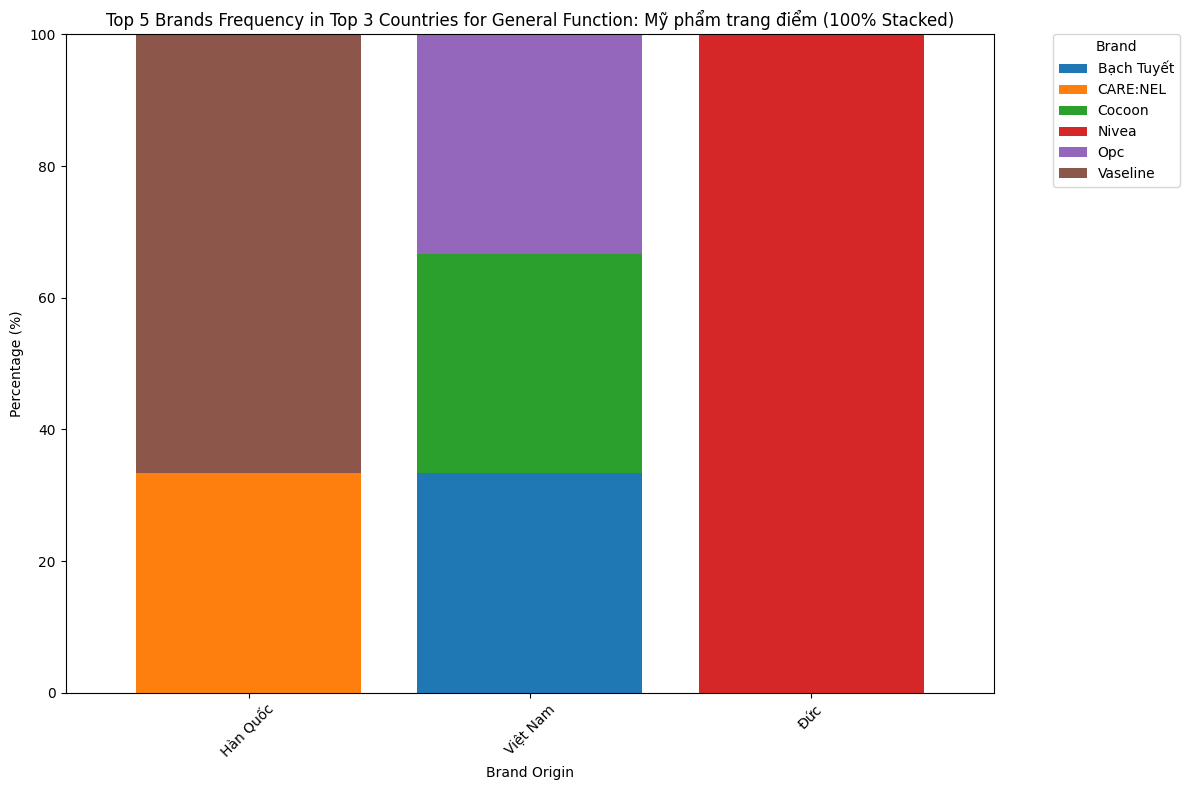

<Figure size 1200x800 with 0 Axes>

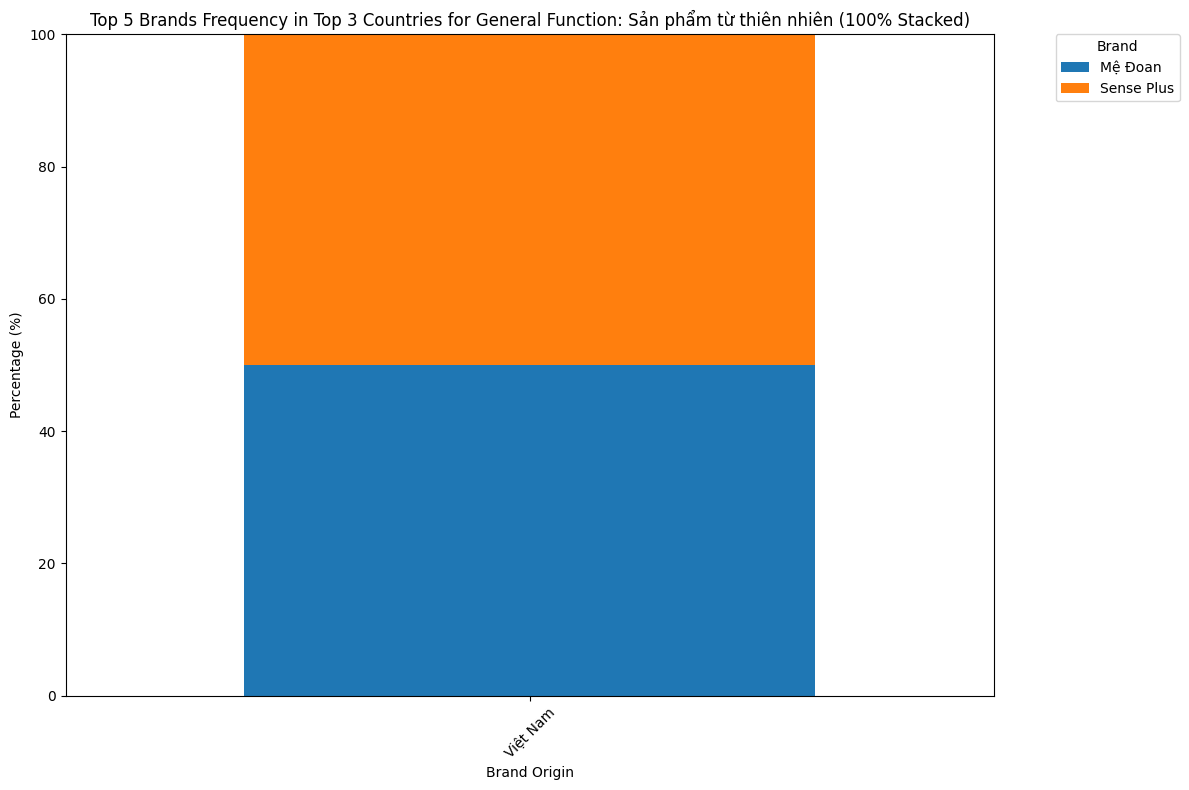

<Figure size 1200x800 with 0 Axes>

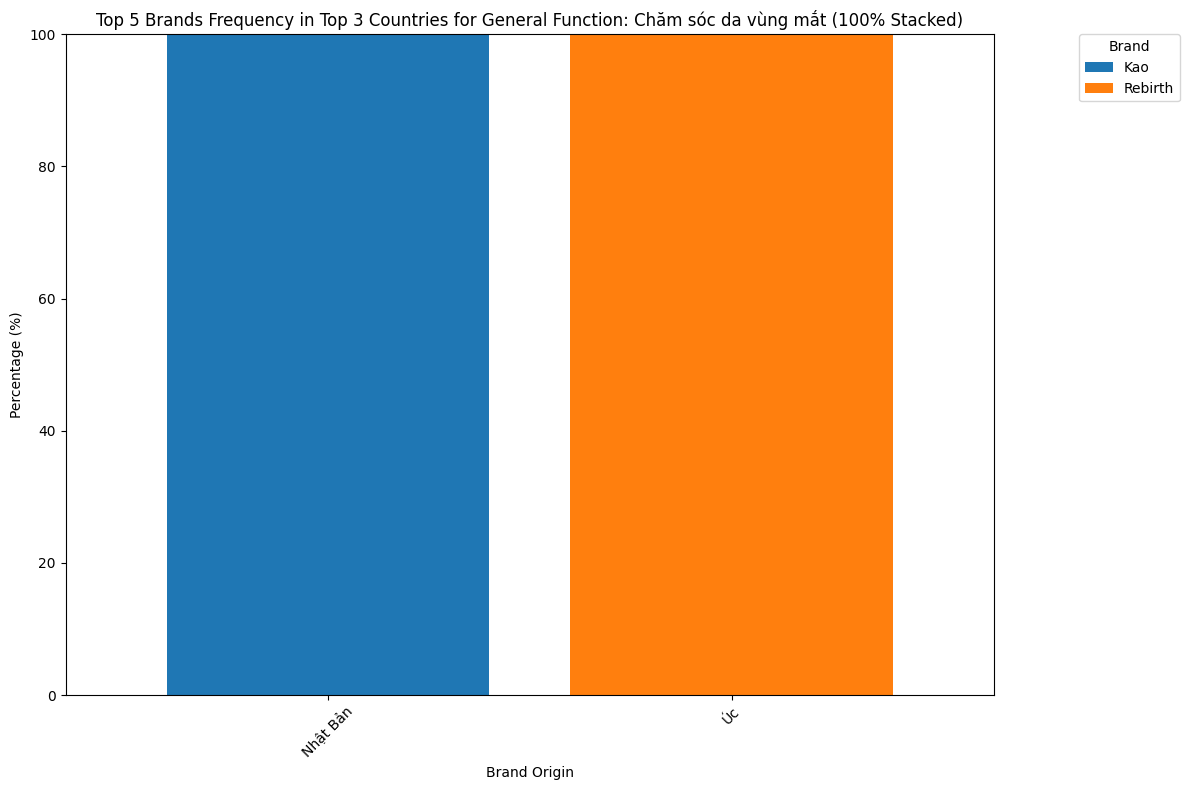

<Figure size 1200x800 with 0 Axes>

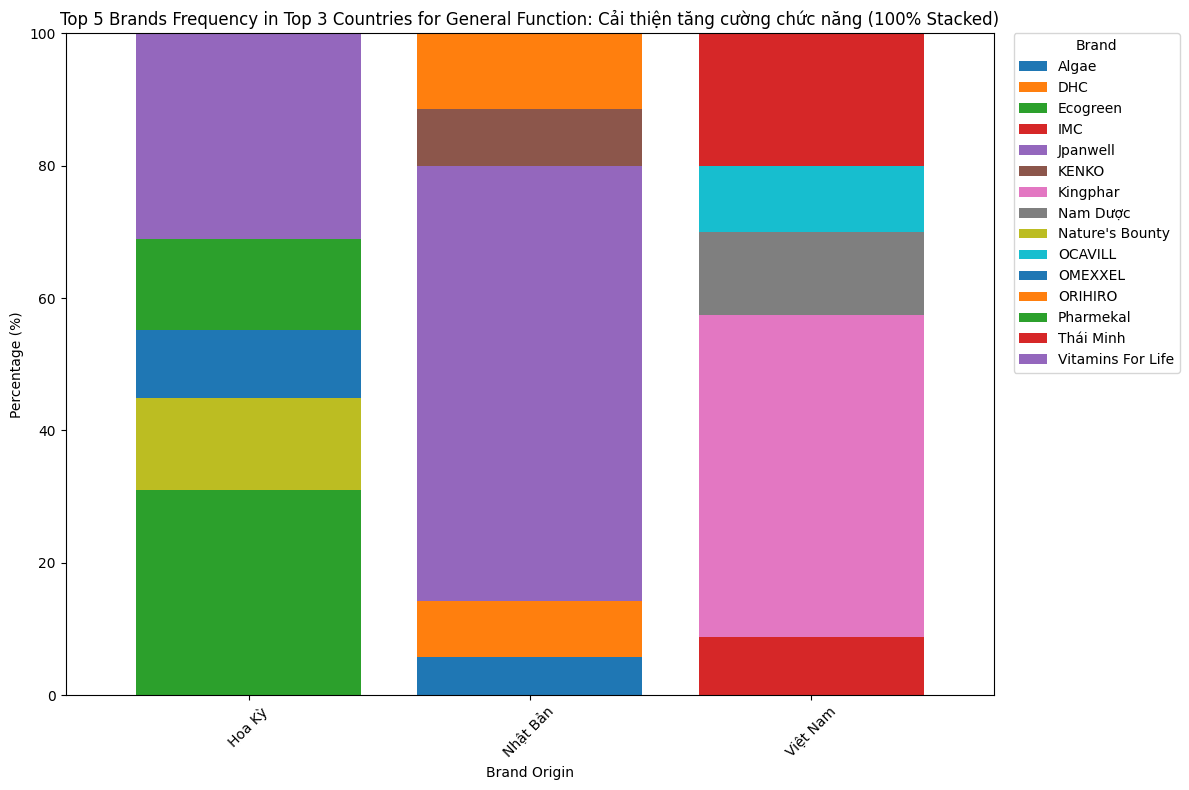

<Figure size 1200x800 with 0 Axes>

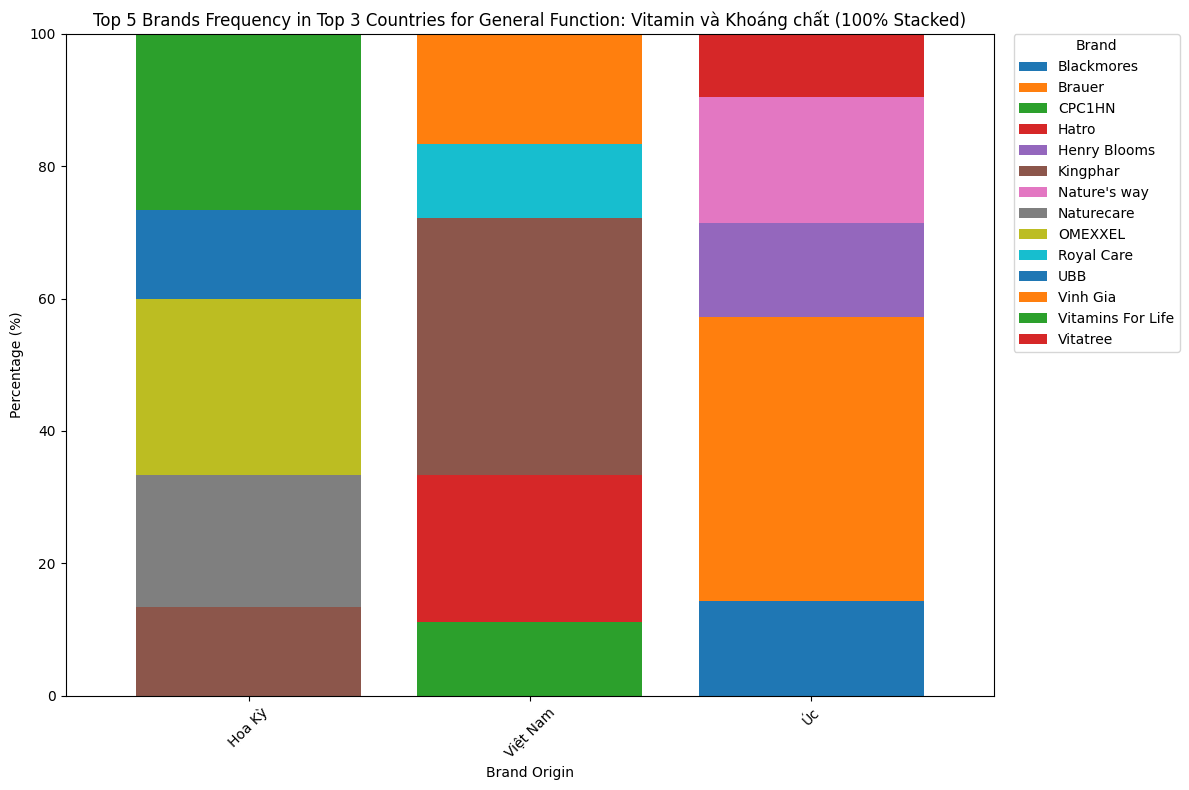

<Figure size 1200x800 with 0 Axes>

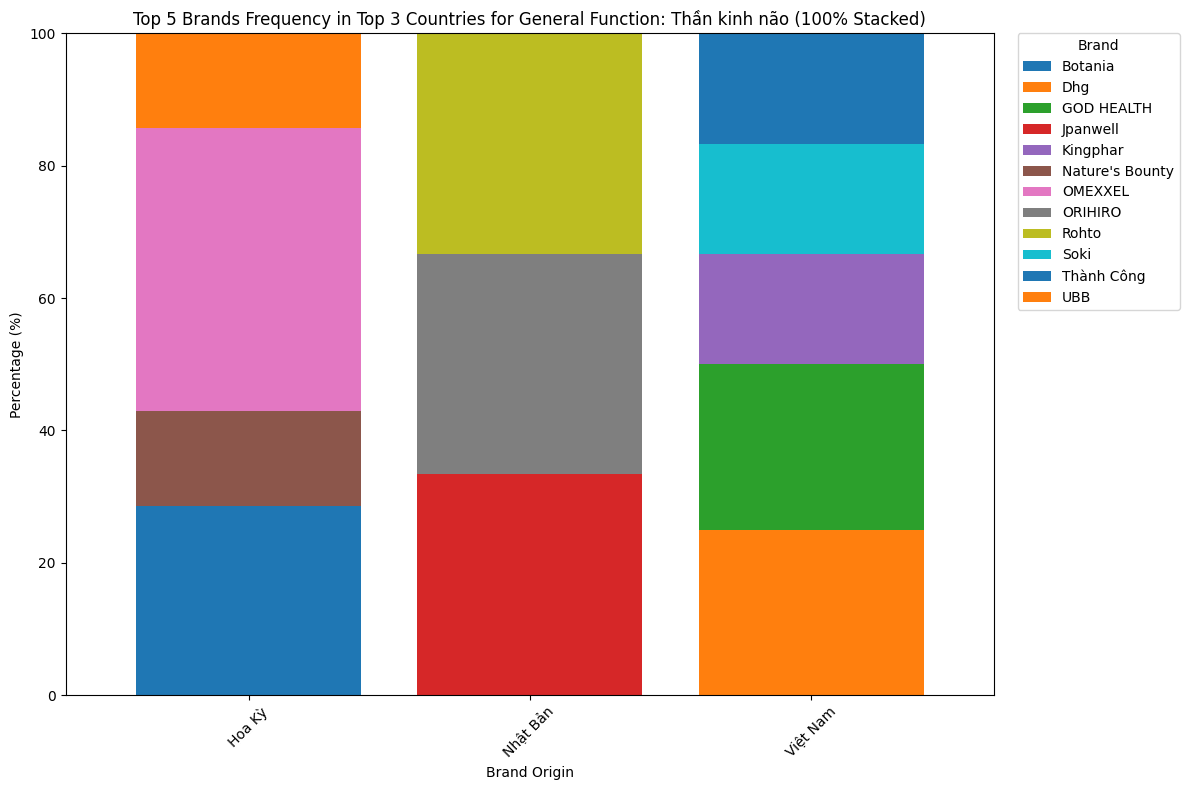

<Figure size 1200x800 with 0 Axes>

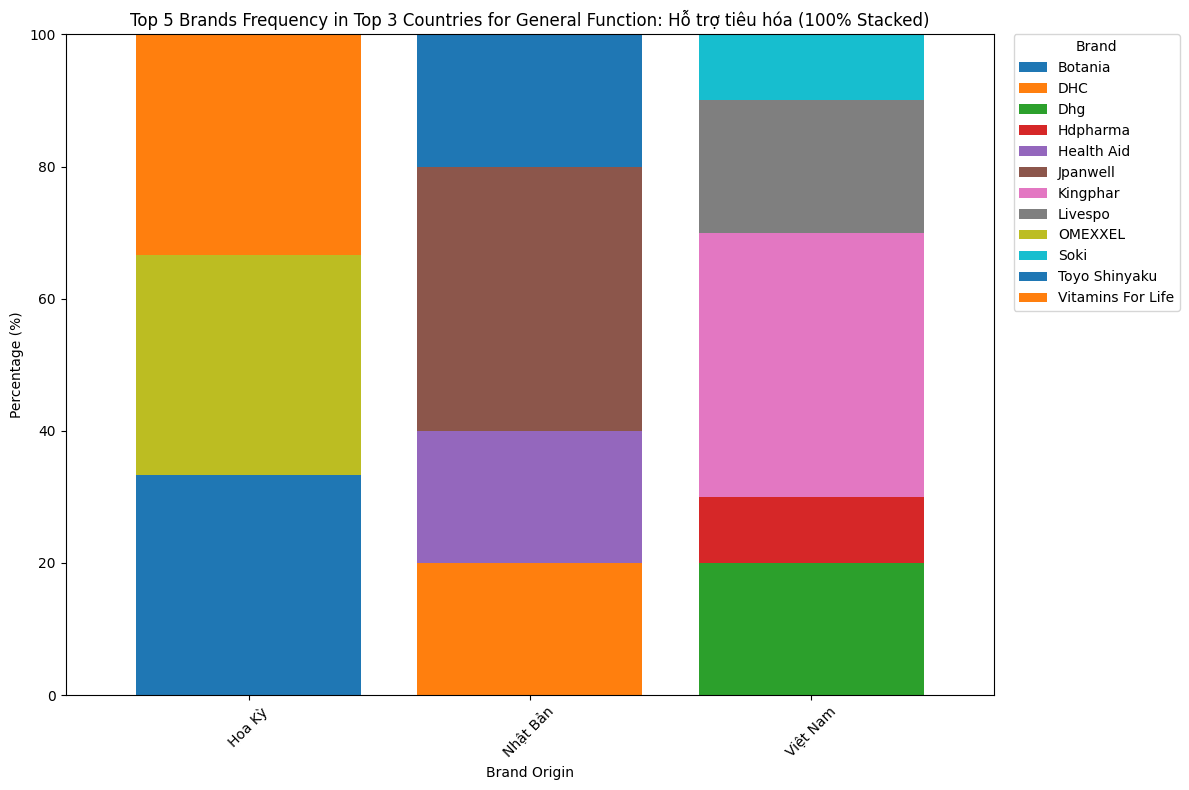

<Figure size 1200x800 with 0 Axes>

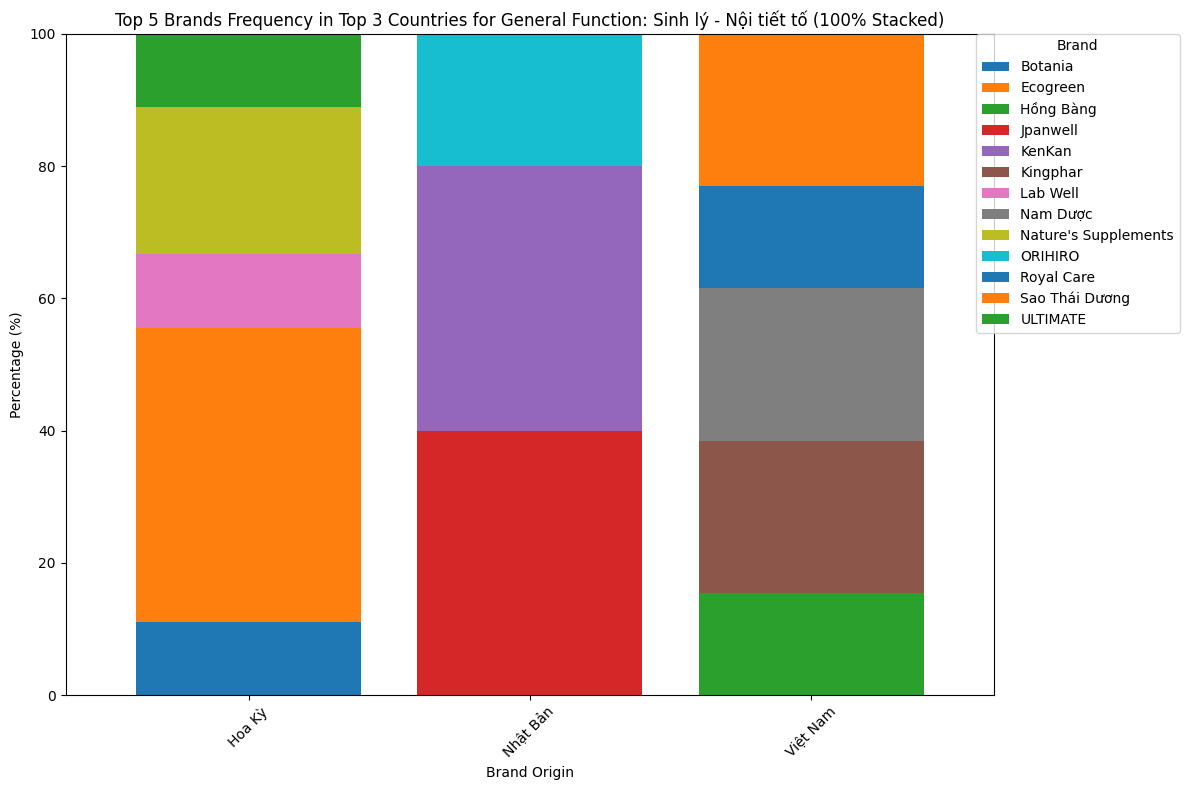

<Figure size 1200x800 with 0 Axes>

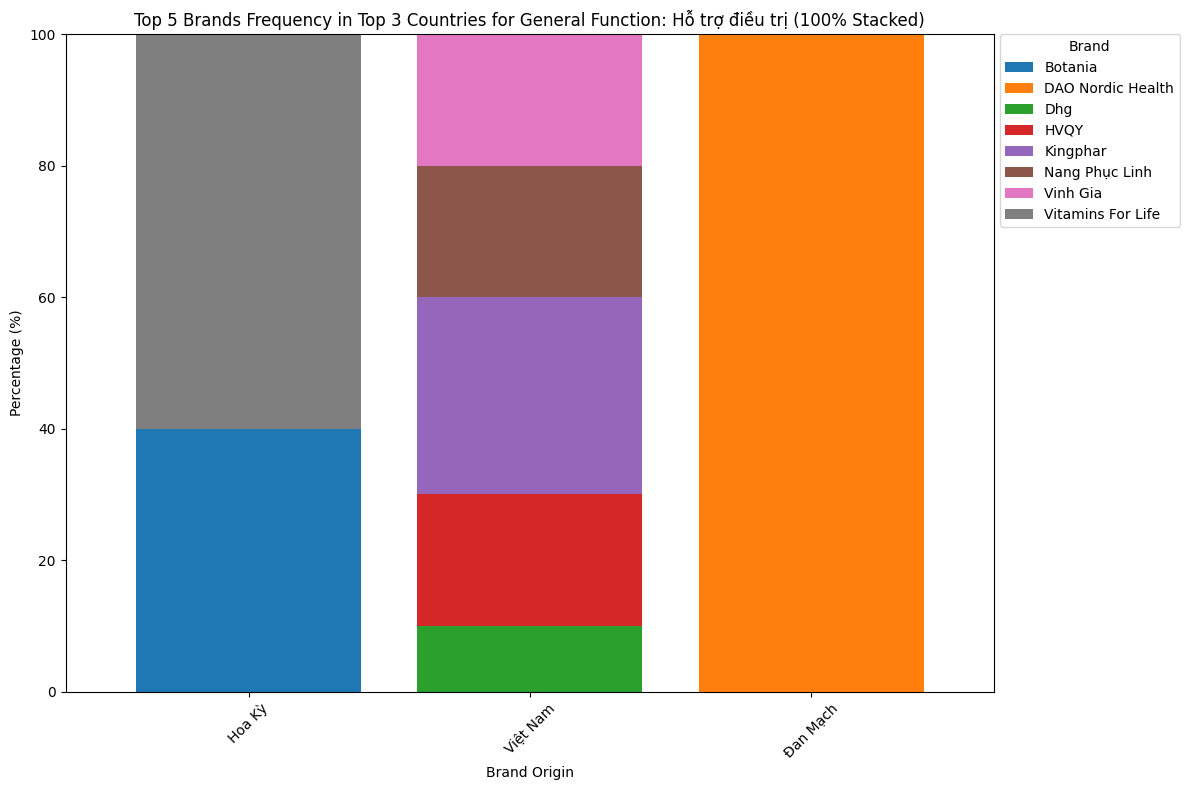

<Figure size 1200x800 with 0 Axes>

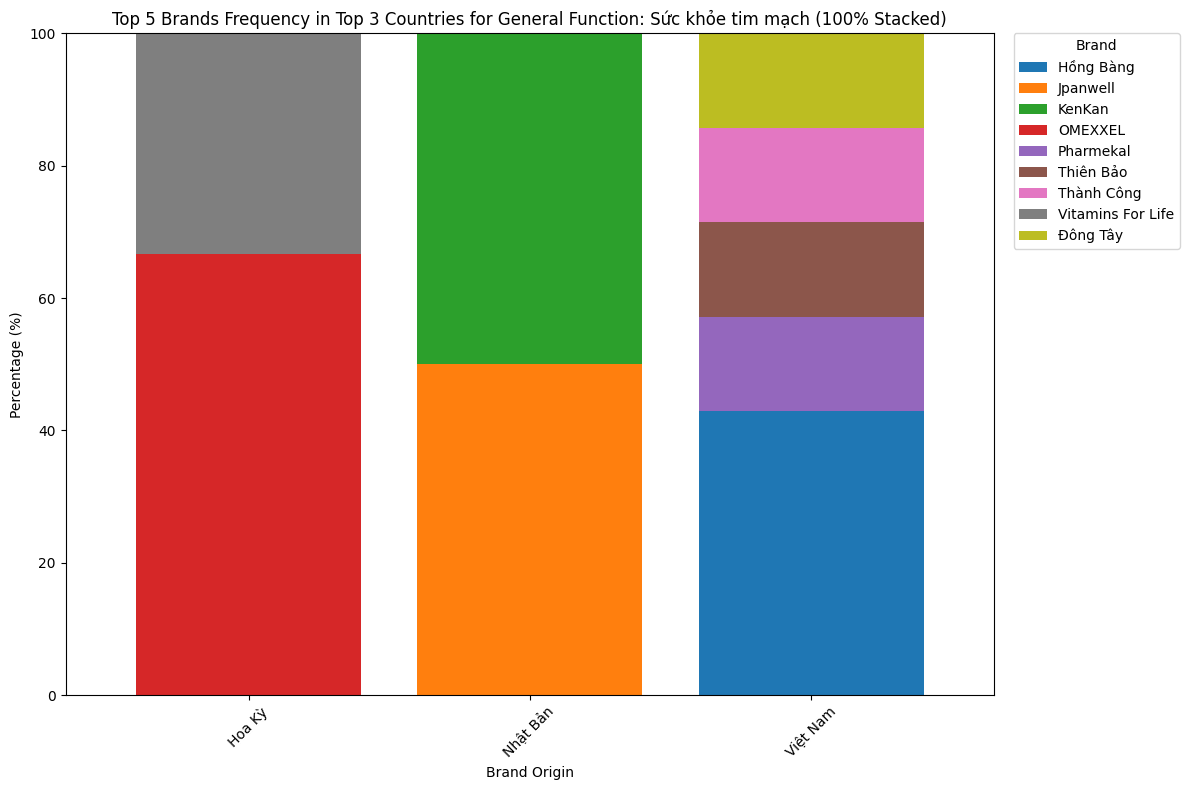

<Figure size 1200x800 with 0 Axes>

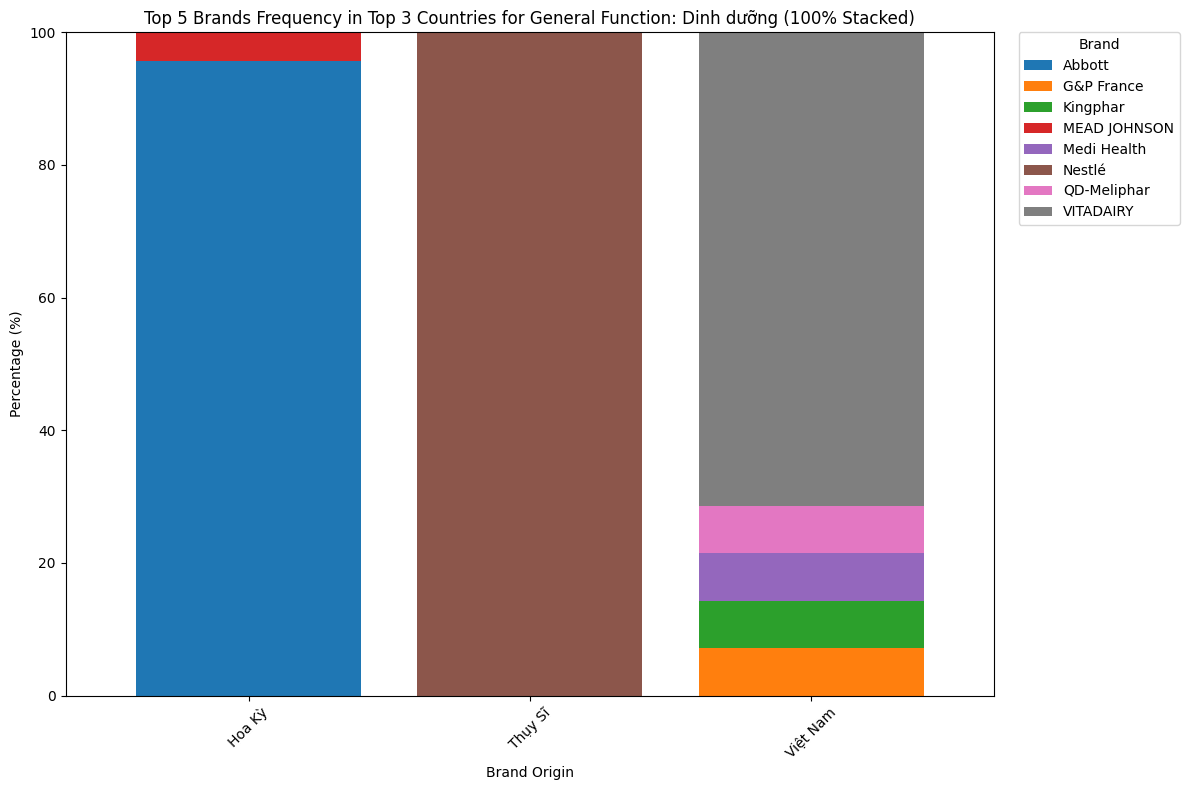

In [15]:
for func in unique_func:
    plot_top5_brands_stacked_bar(func, rating_df)

- Select the 3 most common countries of Popular in each functional category to check whether the brand influences the popularity.

- The percentage (%) frequency of occurrence of certain brands from these countries occupies a significant proportion. 

=> The brand affects buyer demand and decisions.

In [16]:
def get_top5_dosages_by_country(func_df: pd.DataFrame, countries: list) -> dict:
    """
    Get the top 5 dosage forms for each country in the list.
    """
    top5_dosages_by_country = {}
    for country in countries:
        country_df = func_df[func_df['Brand Origin'] == country]
        top_5_dosages = country_df['Dosage Form'].value_counts().nlargest(5).index.tolist()
        top5_dosages_by_country[country] = top_5_dosages
    return top5_dosages_by_country


def create_dosage_counts(func_df: pd.DataFrame, top5_dosages_by_country: dict) -> pd.DataFrame:
    """
    Create a DataFrame to count the occurrences of the top dosage forms.
    """
    dosage_counts = []
    for country, top_5_dosages in top5_dosages_by_country.items():
        for dosage in top_5_dosages:
            count = func_df[(func_df['Brand Origin'] == country) & (func_df['Dosage Form'] == dosage)].shape[0]
            dosage_counts.append({'Brand Origin': country, 'Dosage Form': dosage, 'Count': count})
    return pd.DataFrame(dosage_counts)


In [17]:
def plot_dosage_form_comparison(func: str, rating_df: pd.DataFrame, unrating_df: pd.DataFrame):
    # Get top 5 countries from rating_df and unrating_df
    top_5_countries_rating = top_origin_countries_by_general_function(func, rating_df, n=5)
    top_5_countries_unrating = top_origin_countries_by_general_function(func, unrating_df, n=5)
    
    # Filter rating_df and unrating_df by general function and top 5 countries
    func_rating_df = rating_df[(rating_df['General_function'] == func) & (rating_df['Brand Origin'].isin(top_5_countries_rating))]
    func_unrating_df = unrating_df[(unrating_df['General_function'] == func) & (unrating_df['Brand Origin'].isin(top_5_countries_unrating))]

    # Get top 5 dosage forms for each country
    rating_top5_dosages = get_top5_dosages_by_country(func_rating_df, top_5_countries_rating)
    unrating_top5_dosages = get_top5_dosages_by_country(func_unrating_df, top_5_countries_unrating)

    # Create a DataFrame to count the occurrences of dosage forms
    rating_counts_df = create_dosage_counts(func_rating_df, rating_top5_dosages)
    unrating_counts_df = create_dosage_counts(func_unrating_df, unrating_top5_dosages)

    # Pivot the data for plotting
    rating_pivot = rating_counts_df.pivot(index='Brand Origin', columns='Dosage Form', values='Count').fillna(0)
    unrating_pivot = unrating_counts_df.pivot(index='Brand Origin', columns='Dosage Form', values='Count').fillna(0)

    # Calculate percentages
    rating_percentage = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100
    unrating_percentage = unrating_pivot.div(unrating_pivot.sum(axis=1), axis=0) * 100

    # Plot the data
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    fig.subplots_adjust(wspace=0.3)  # Increase space between the two plots
    fig.suptitle(f"Comparison of Dosage Forms for General Function: {func} (Top 5 Countries)", fontsize=16, y=1.02)

    # Rating data
    if not rating_percentage.empty:
        rating_percentage.plot(kind='bar', stacked=True, ax=axes[0], width=0.8, legend=False)
        axes[0].set_title('Rating Data', fontsize=14, pad=10)
        axes[0].set_xlabel('Brand Origin', fontsize=12)
        axes[0].set_ylabel('Percentage (%)', fontsize=12)
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].set_ylim(0, 100)

    # Unrating data
    if not unrating_percentage.empty:
        unrating_percentage.plot(kind='bar', stacked=True, ax=axes[1], width=0.8, legend=False)
        axes[1].set_title('Unrating Data', fontsize=14, pad=10)
        axes[1].set_xlabel('Brand Origin', fontsize=12)
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].set_ylim(0, 100)

    # Common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Dosage Form', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for the legend and main title
    plt.show()


--------------------------------------------------------------------------------


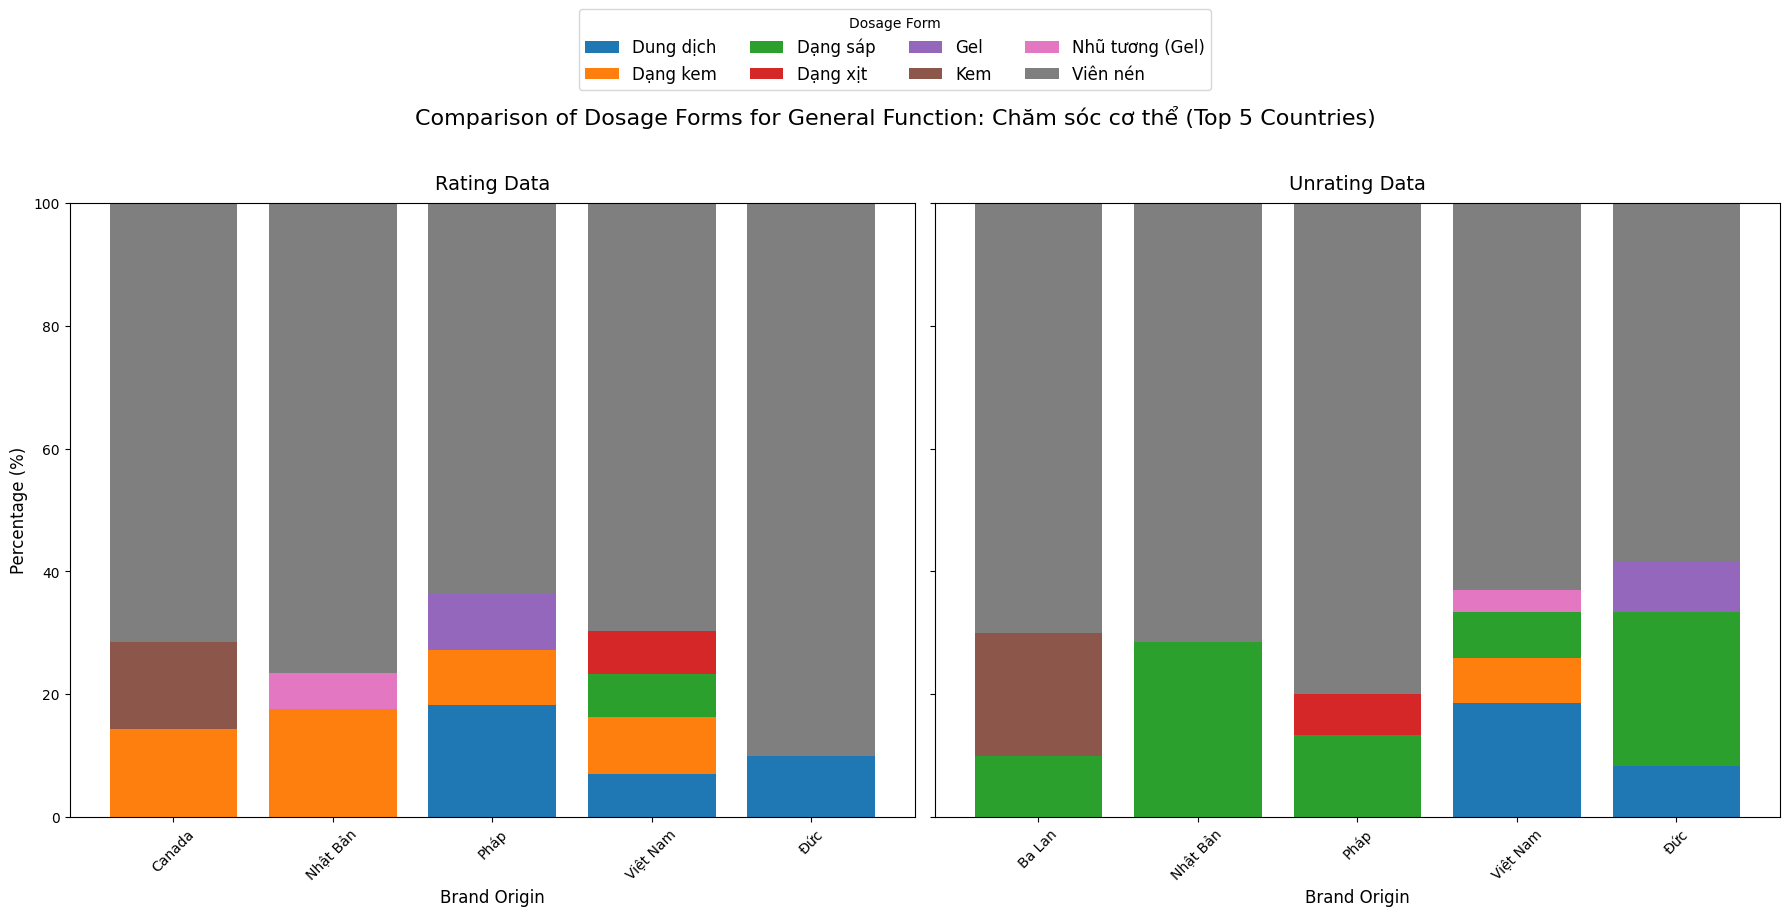

--------------------------------------------------------------------------------


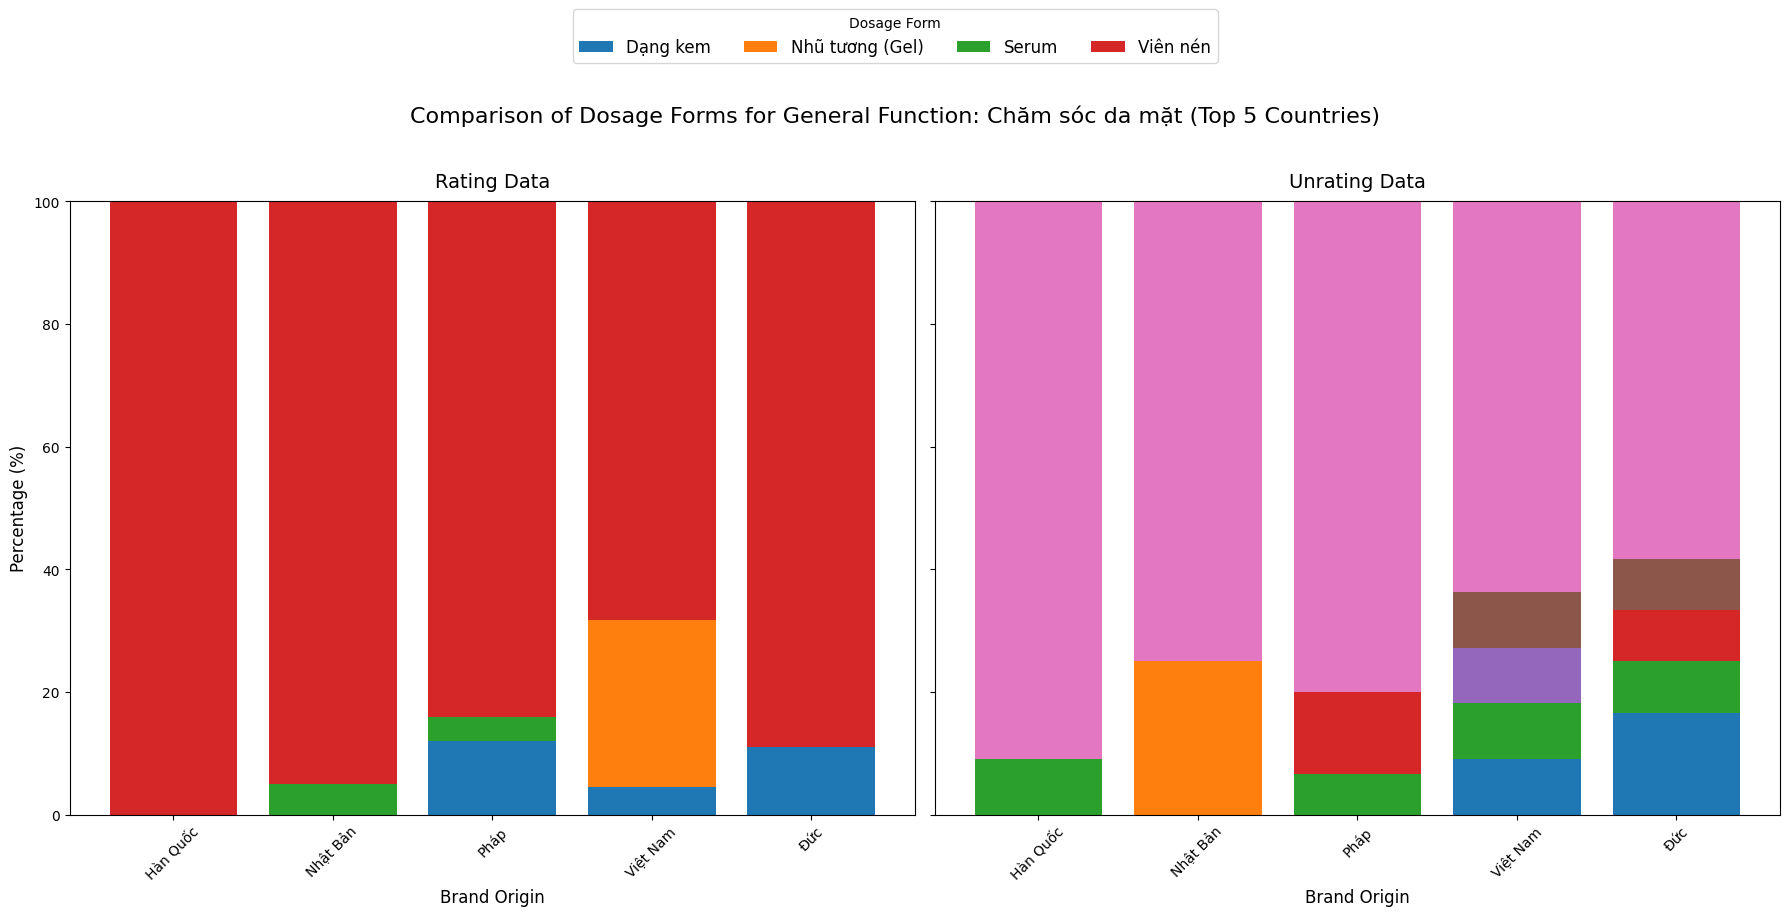

--------------------------------------------------------------------------------


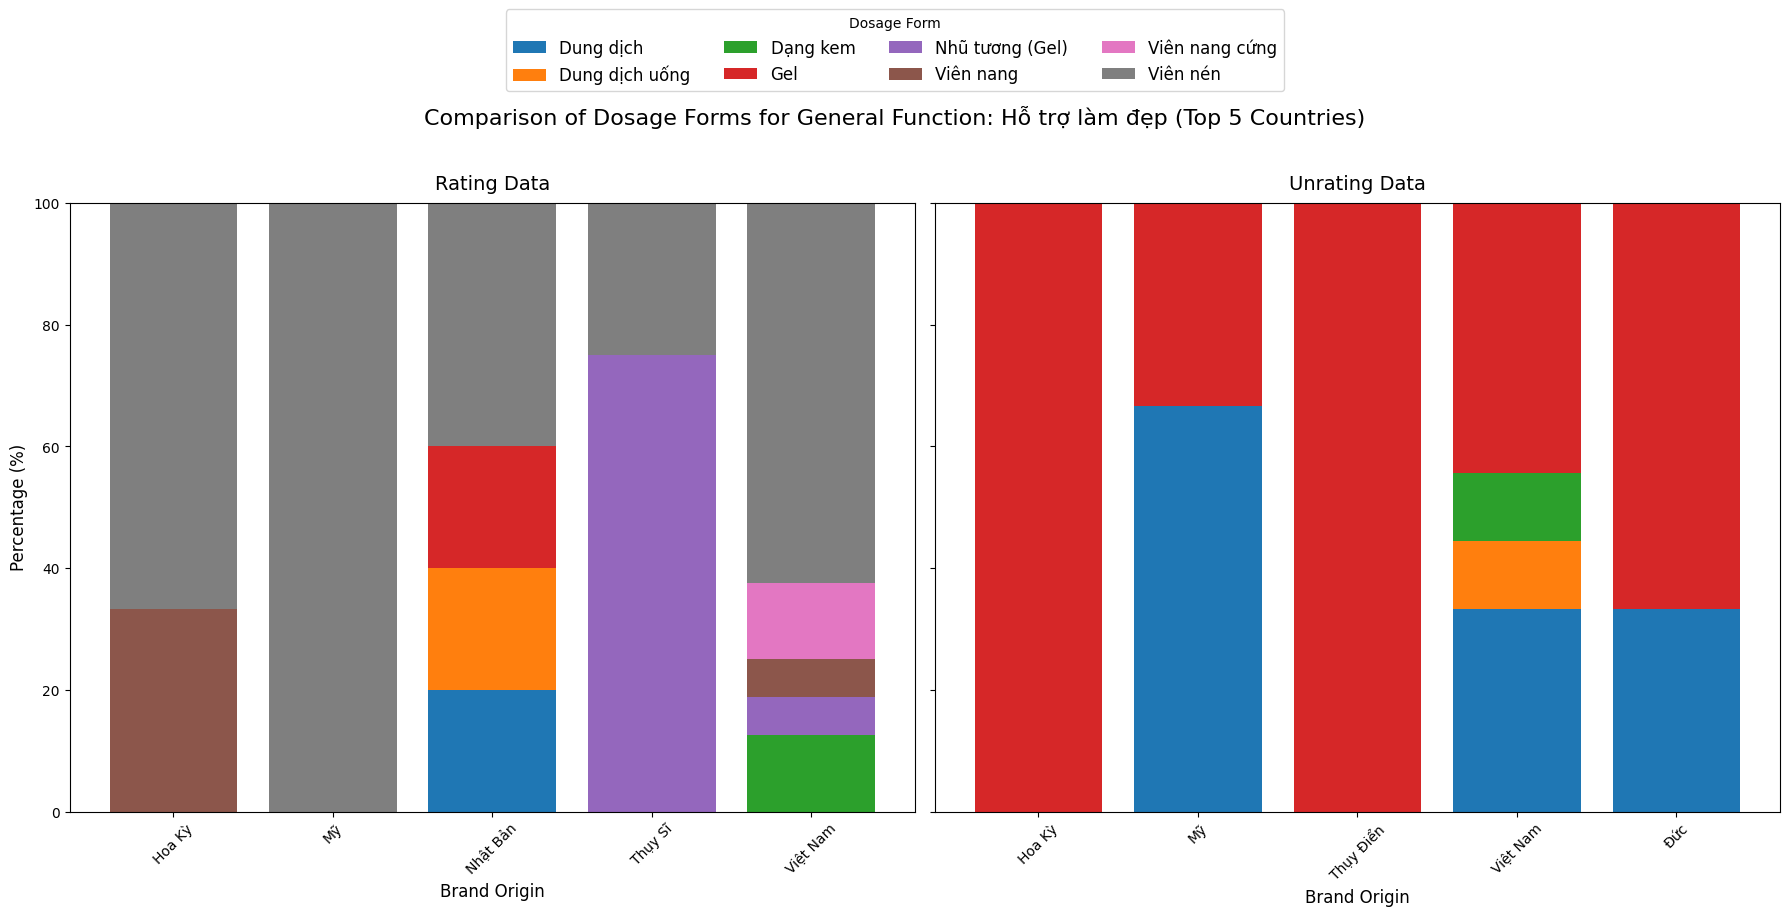

--------------------------------------------------------------------------------


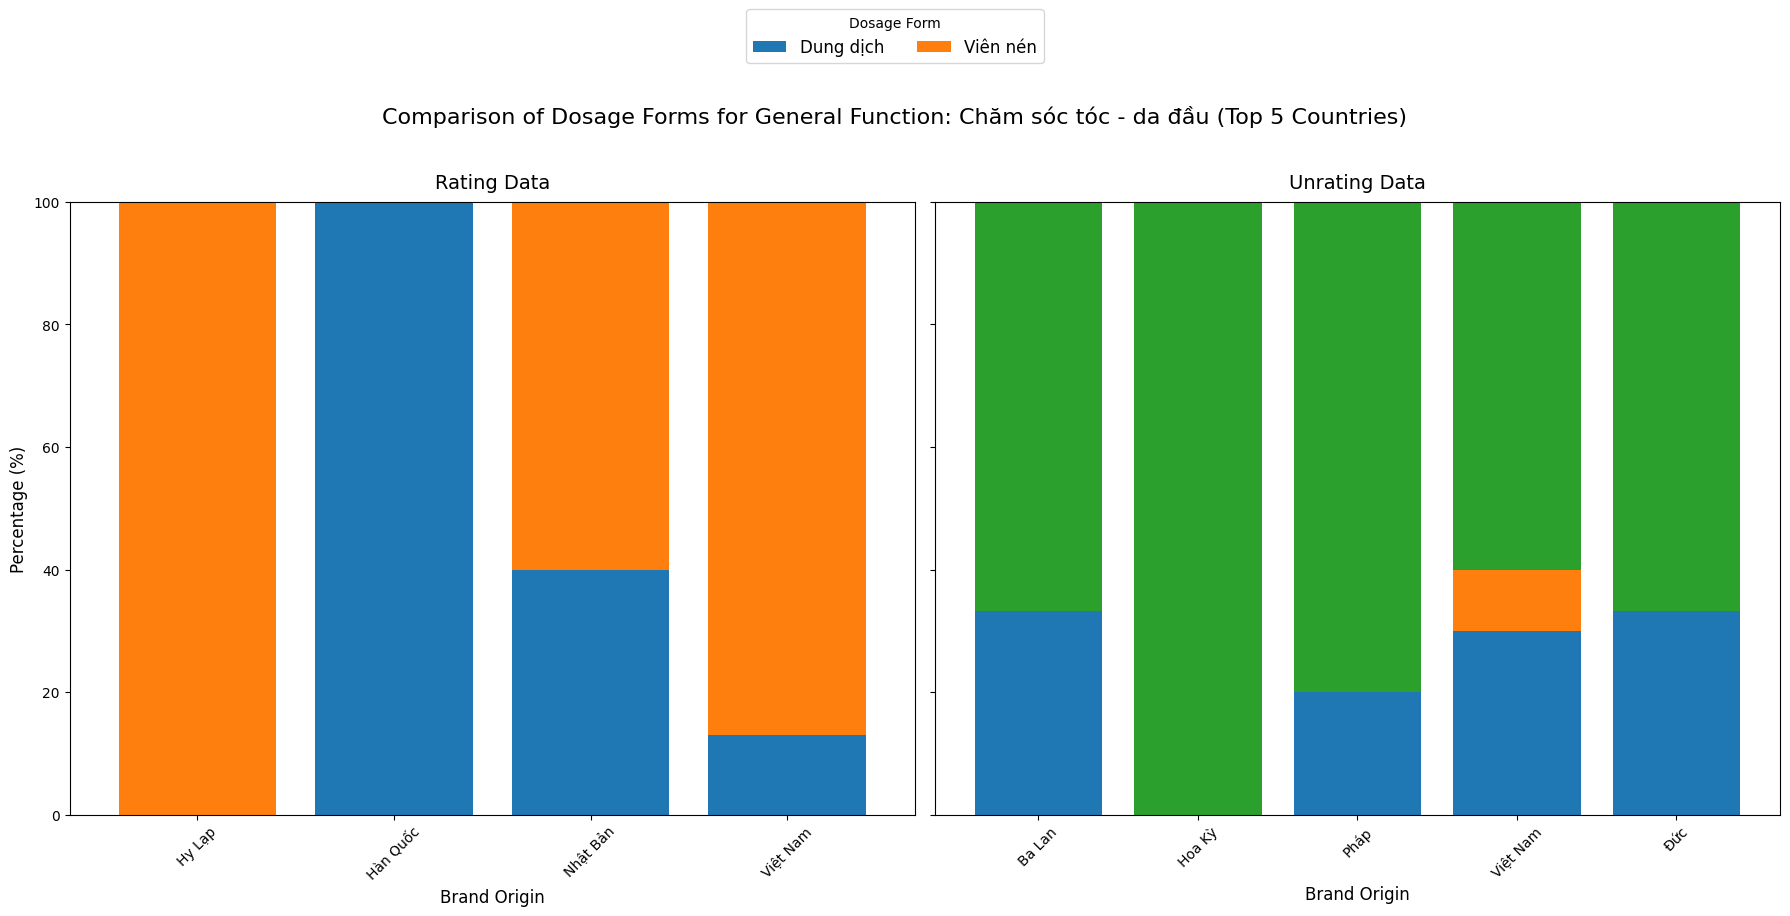

--------------------------------------------------------------------------------


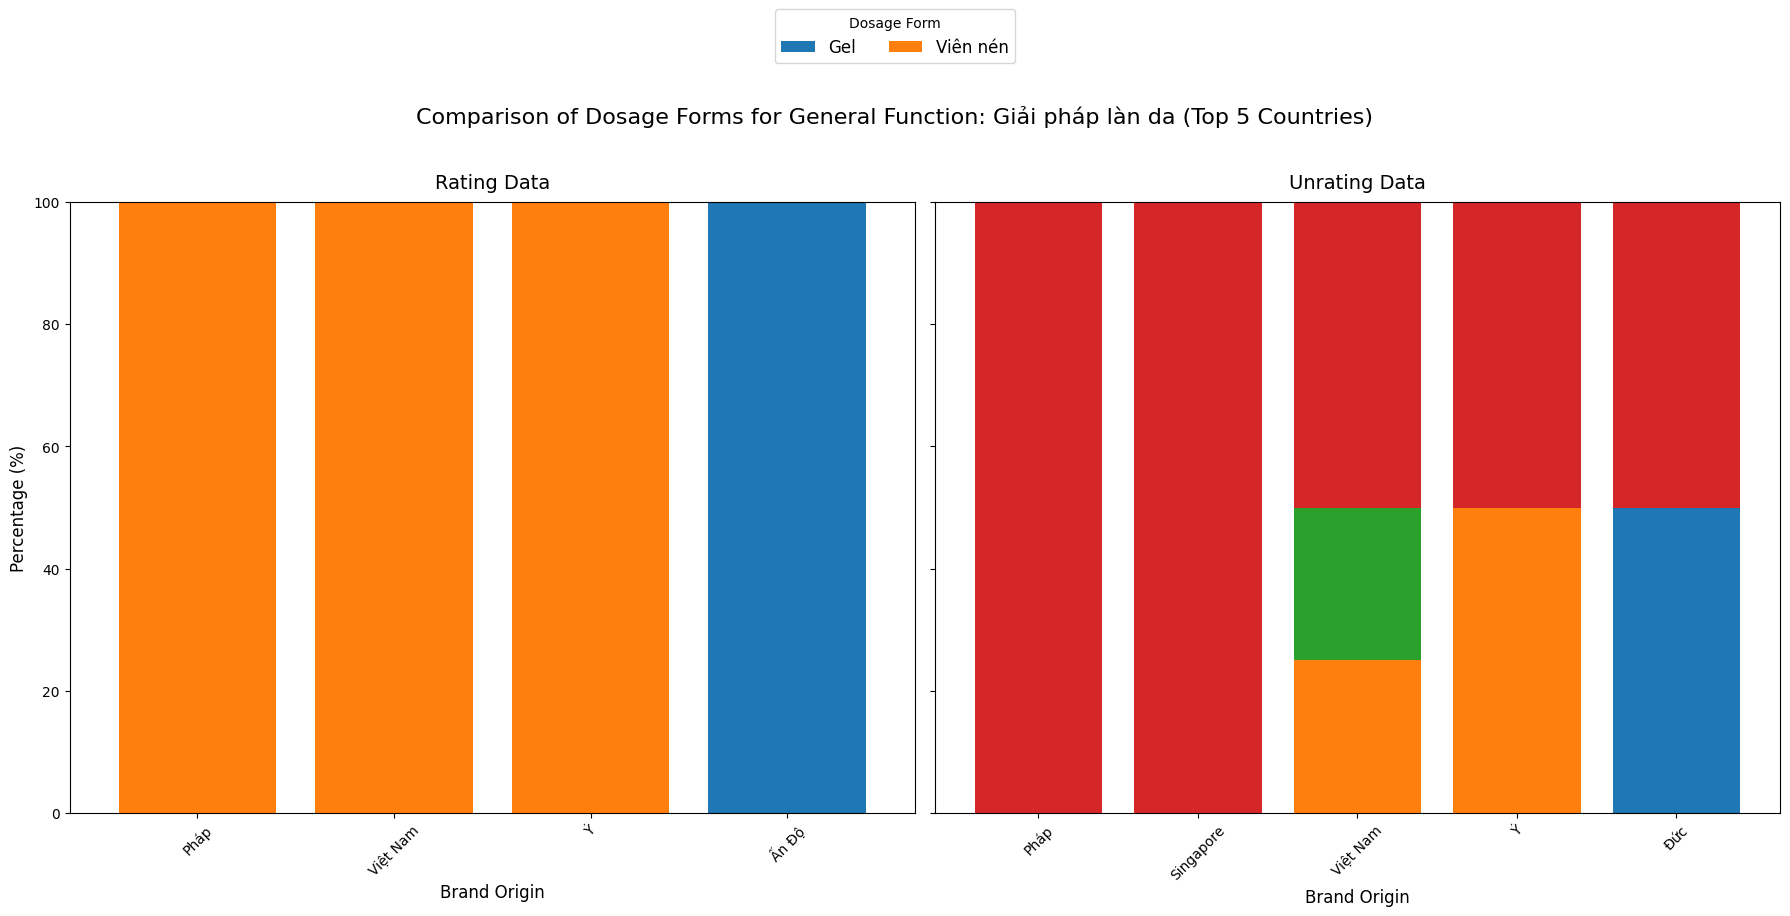

--------------------------------------------------------------------------------


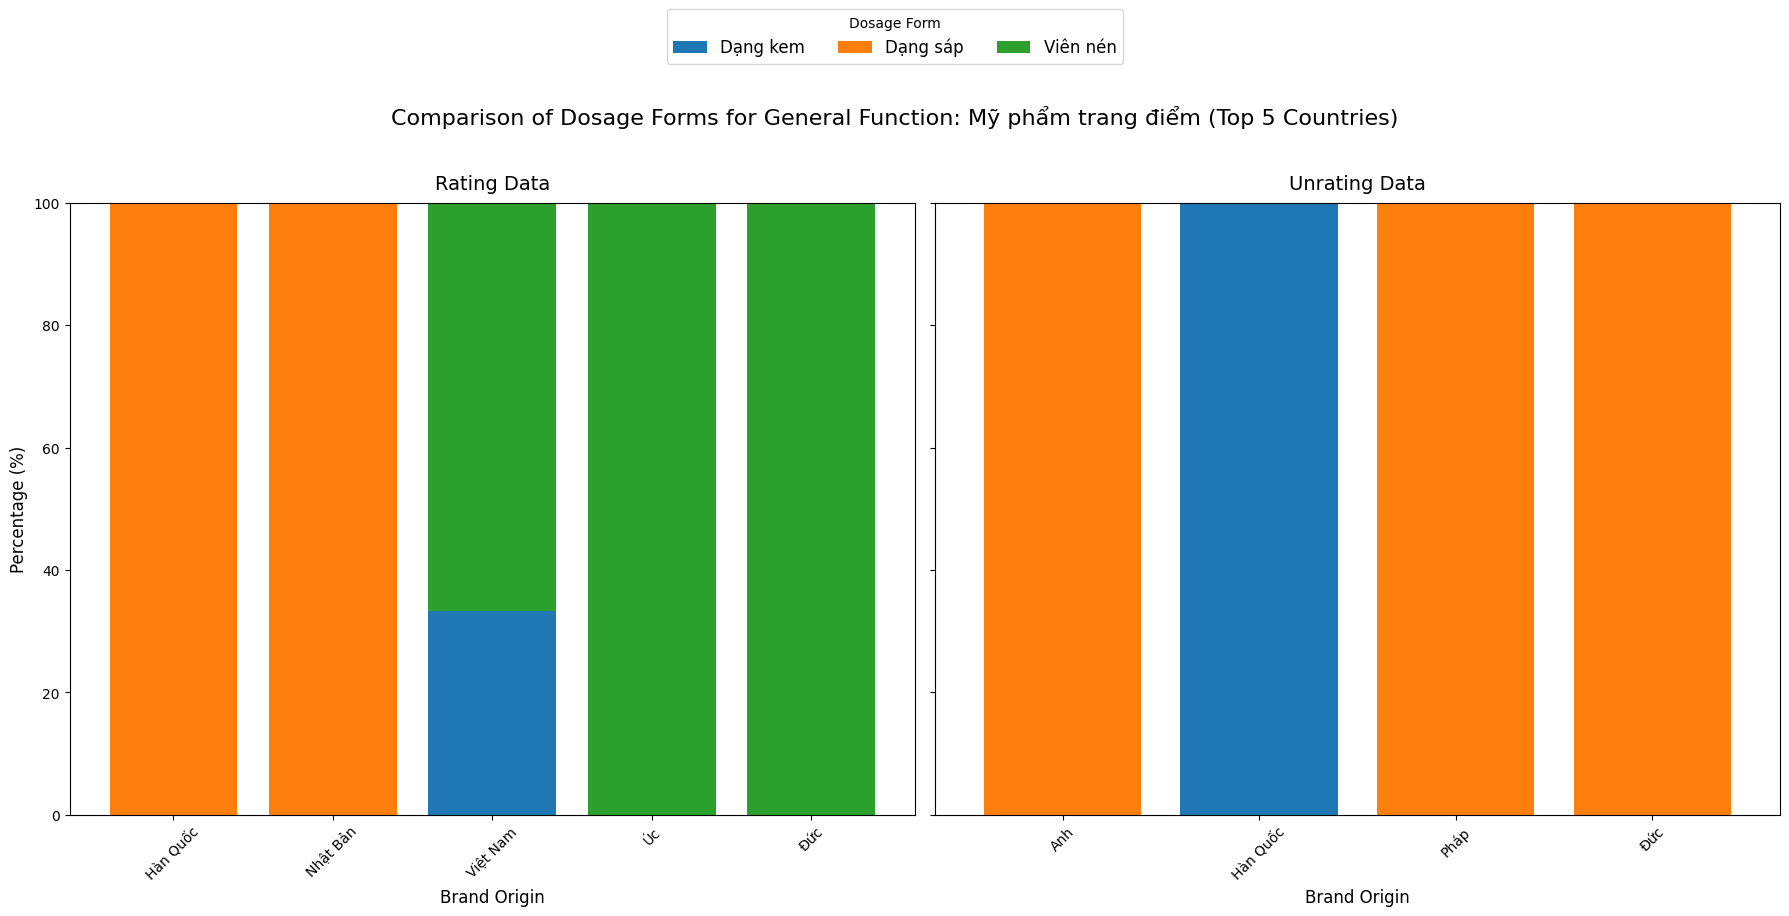

--------------------------------------------------------------------------------


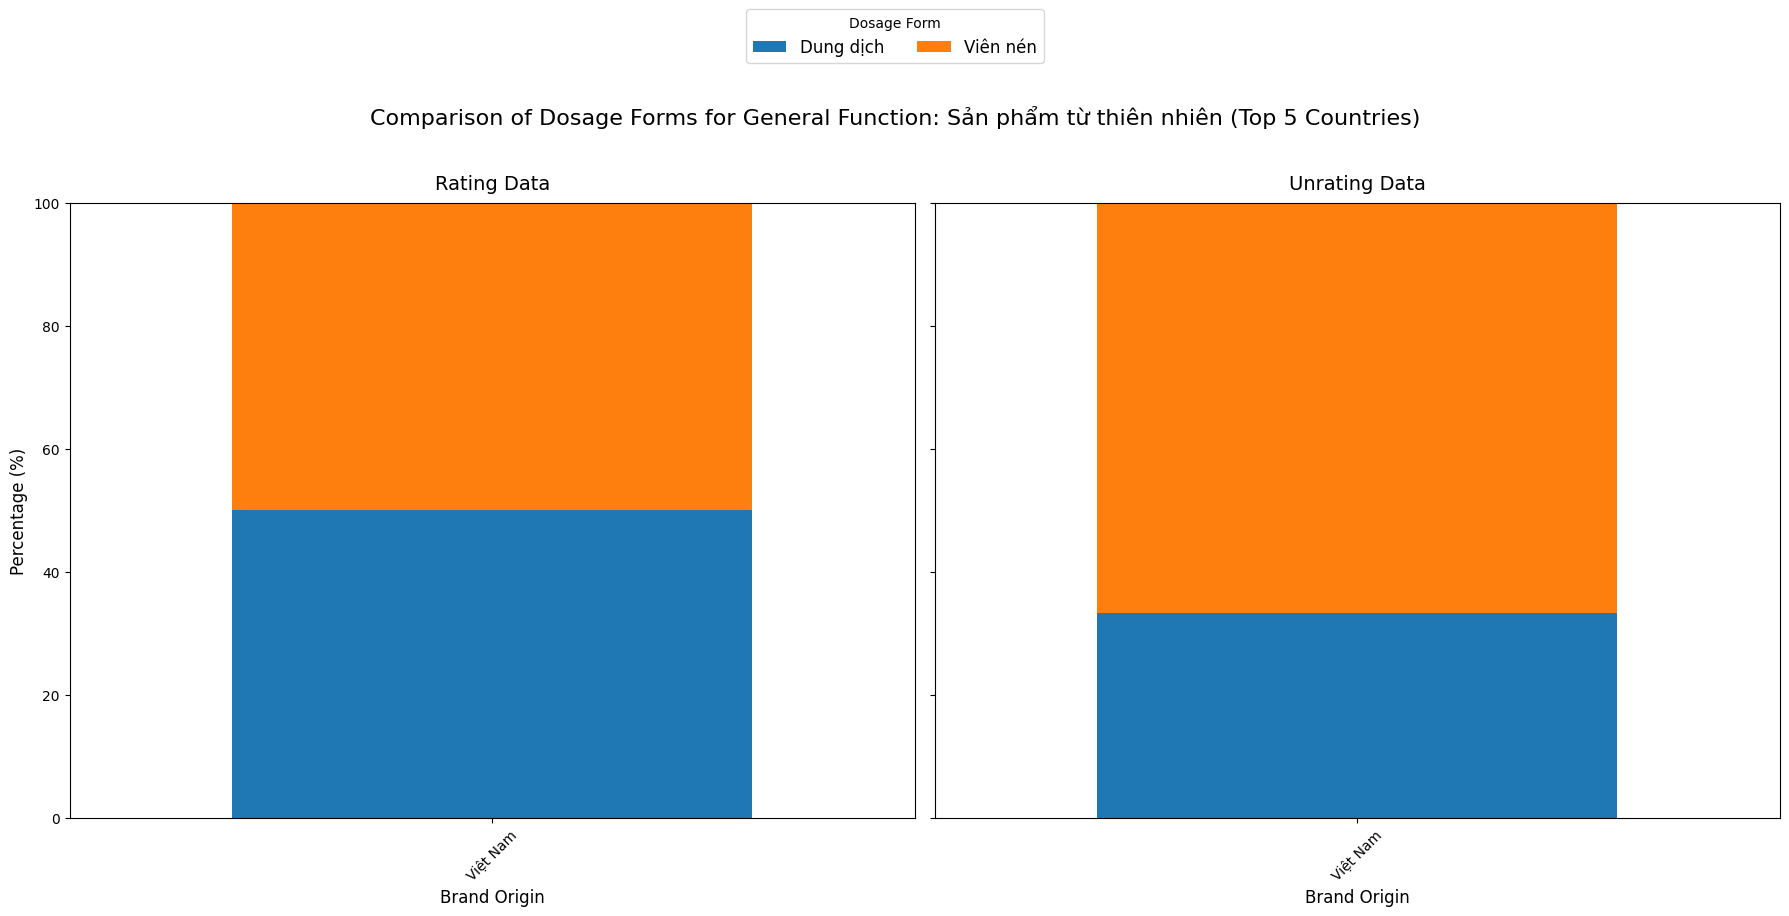

--------------------------------------------------------------------------------


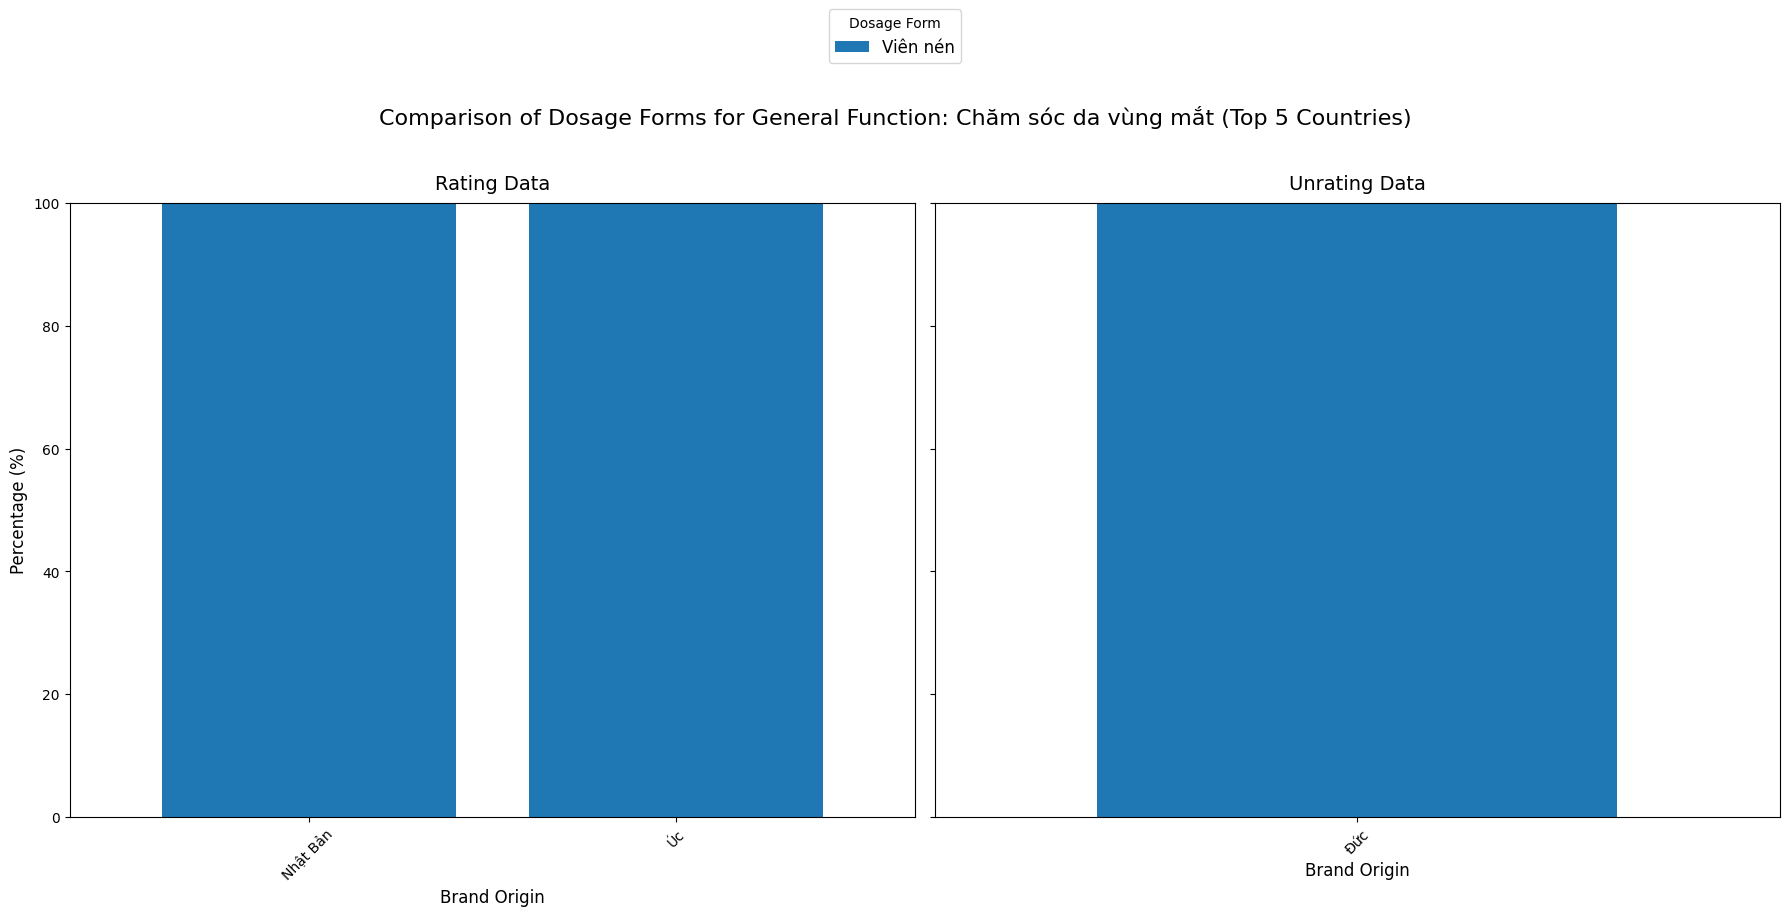

--------------------------------------------------------------------------------


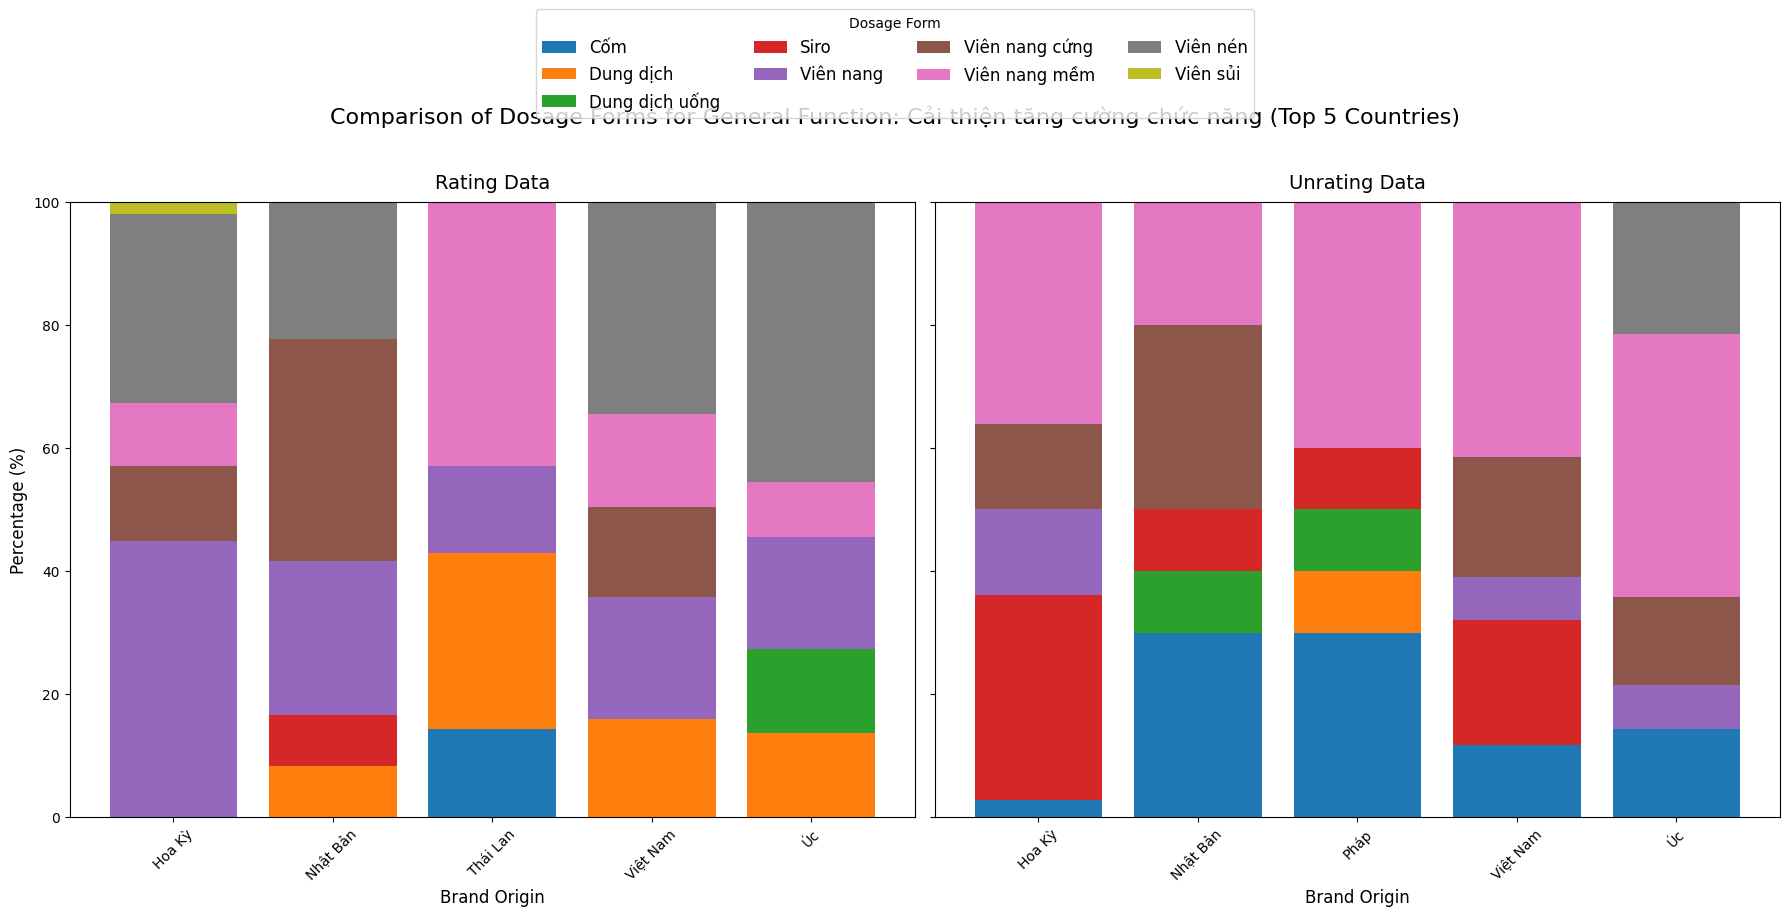

--------------------------------------------------------------------------------


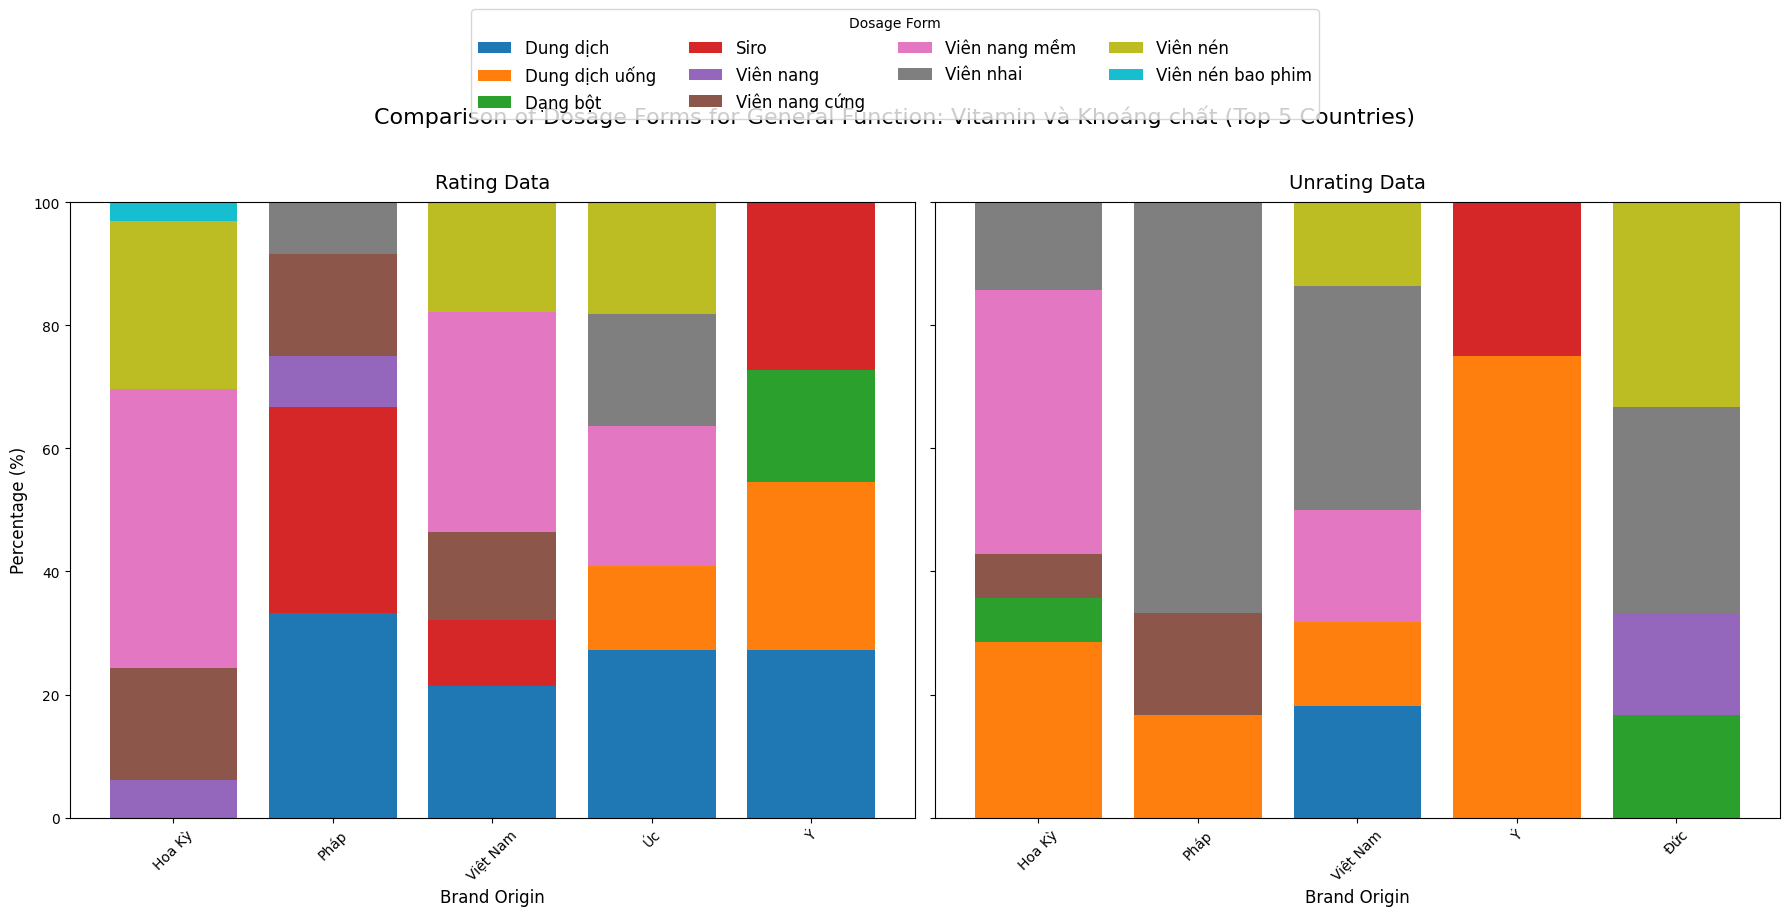

--------------------------------------------------------------------------------


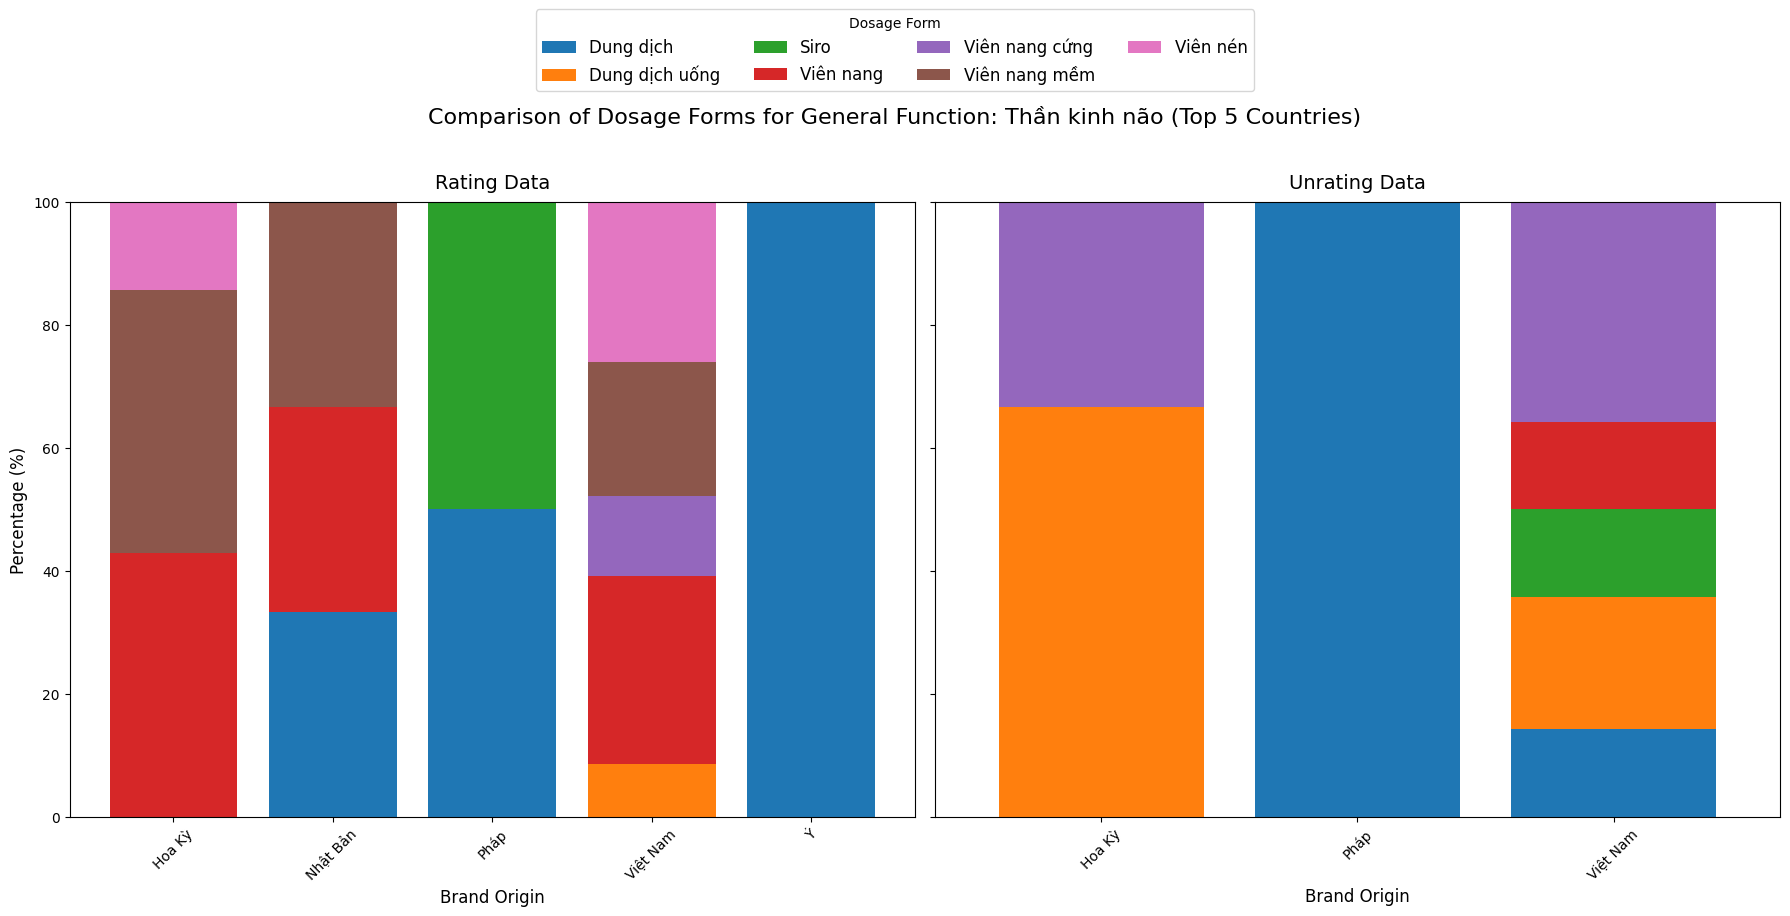

--------------------------------------------------------------------------------


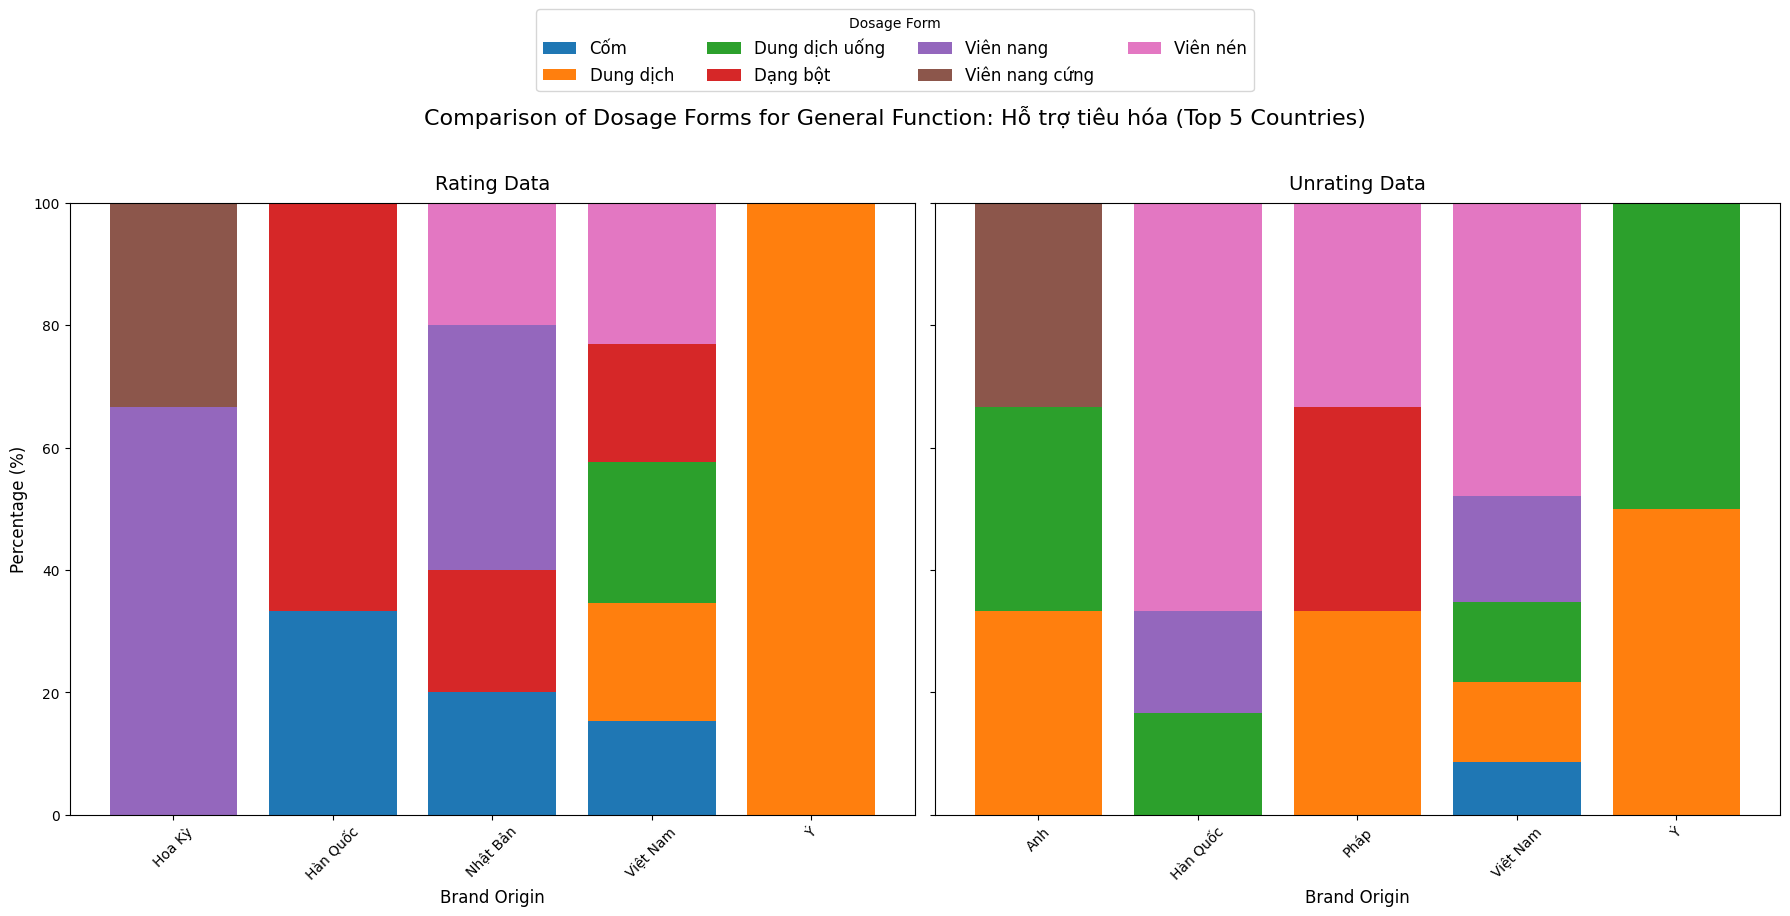

--------------------------------------------------------------------------------


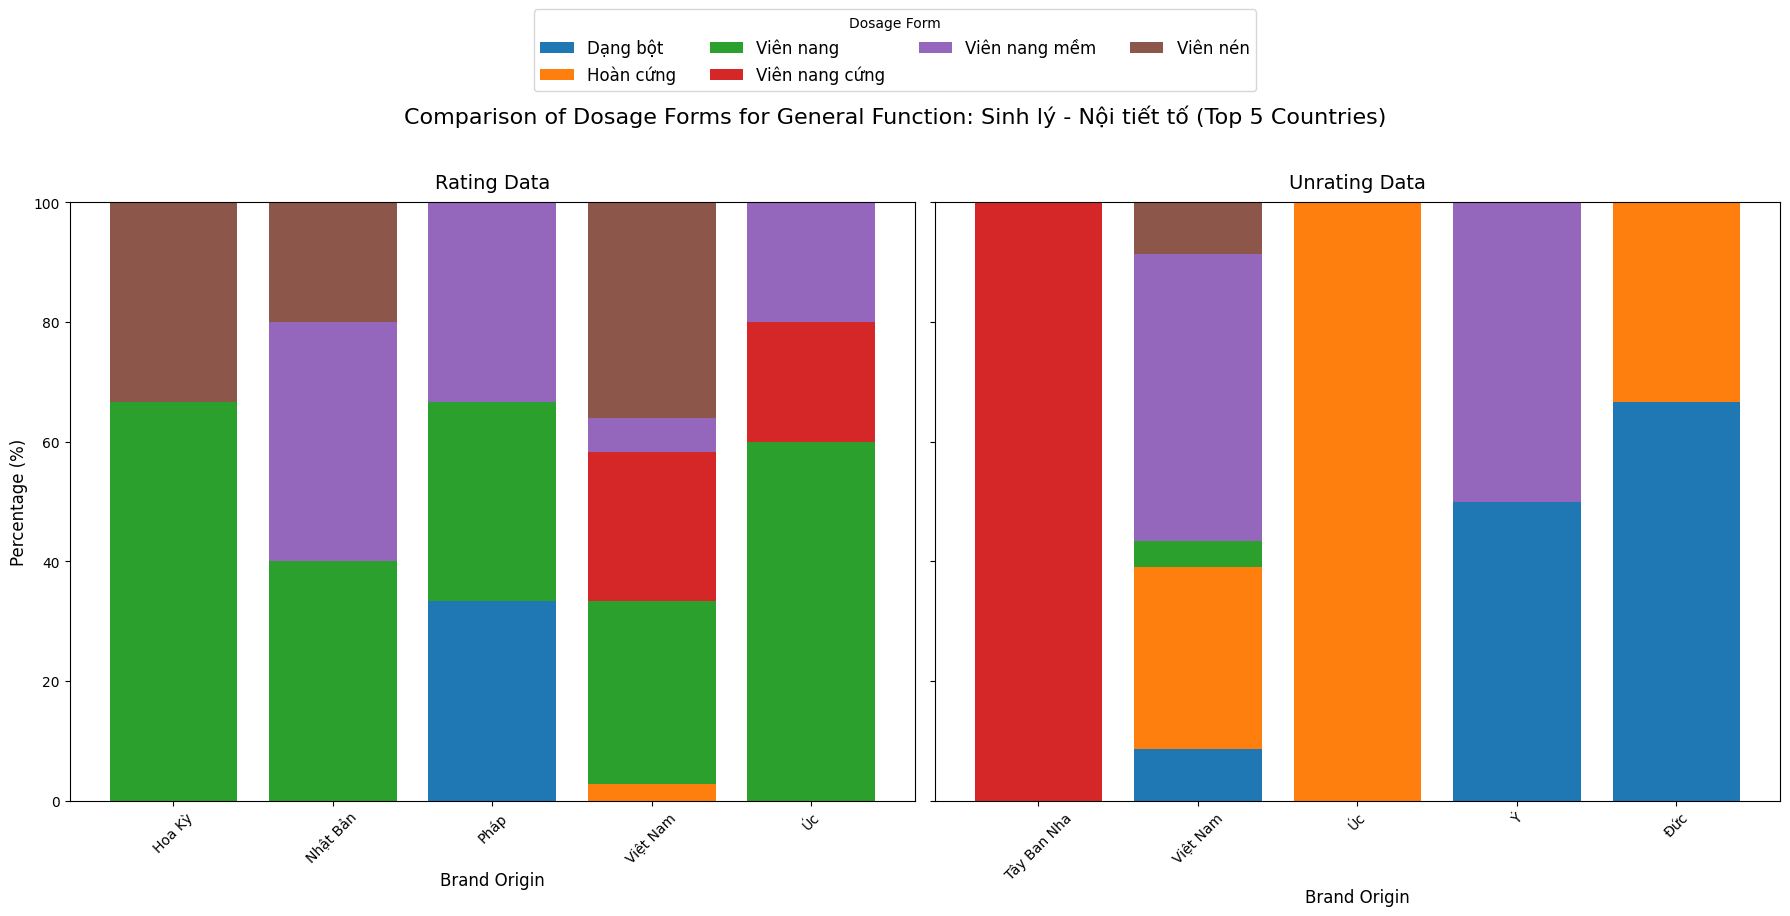

--------------------------------------------------------------------------------


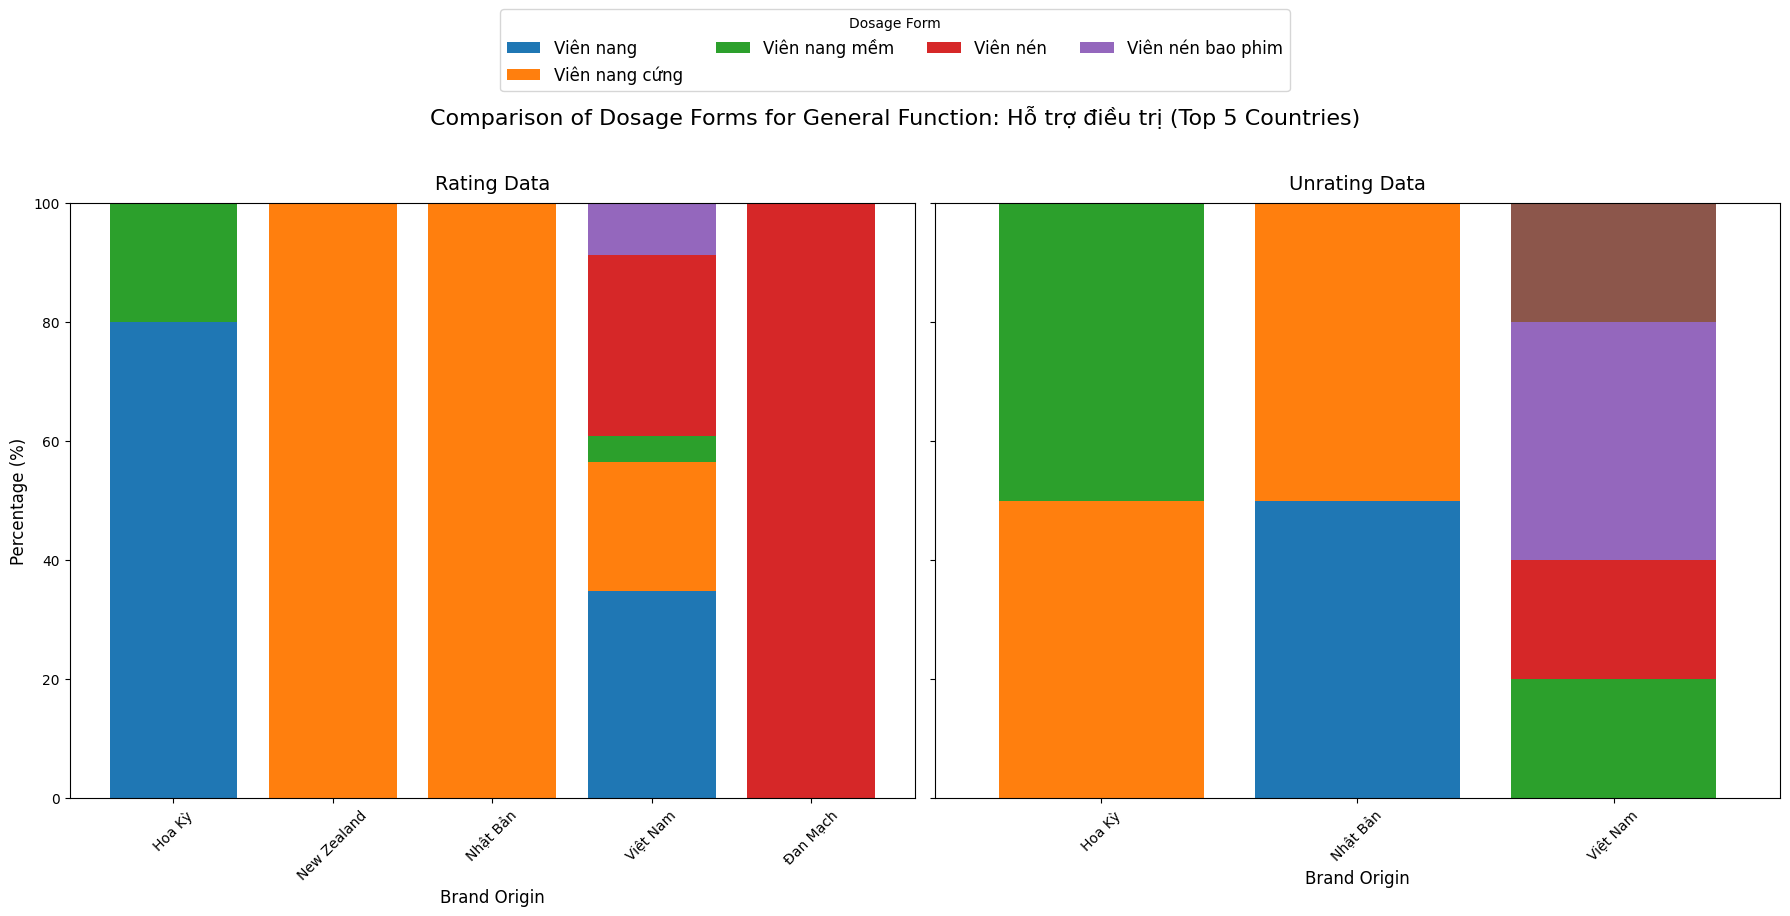

--------------------------------------------------------------------------------


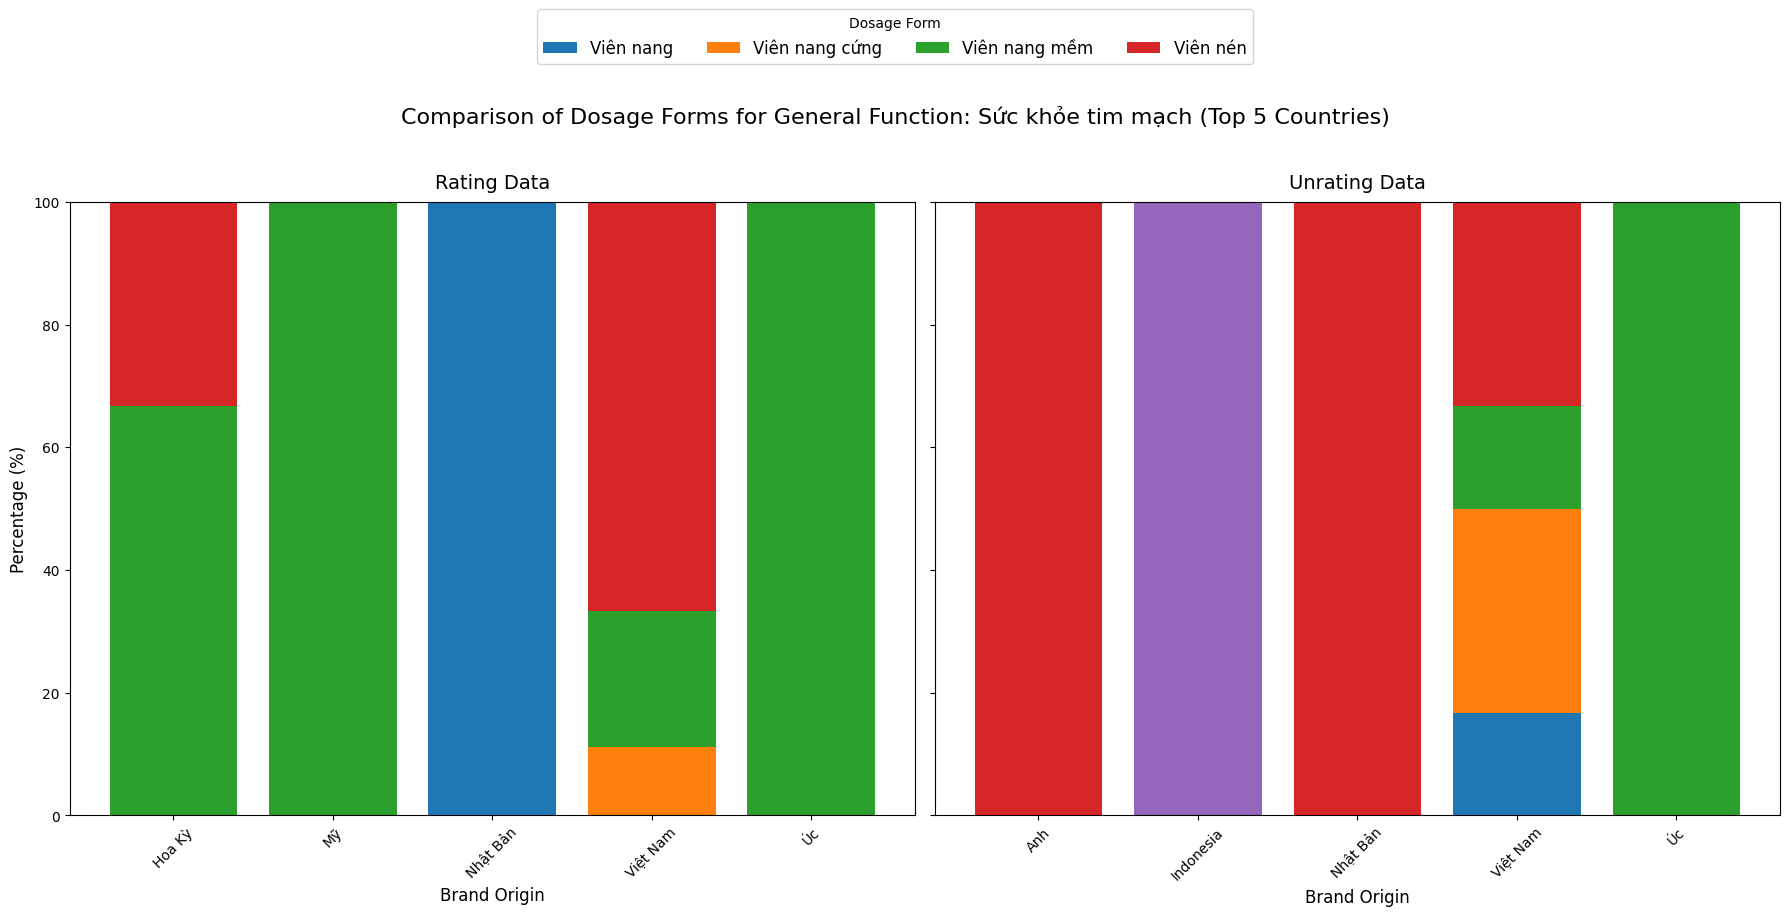

--------------------------------------------------------------------------------


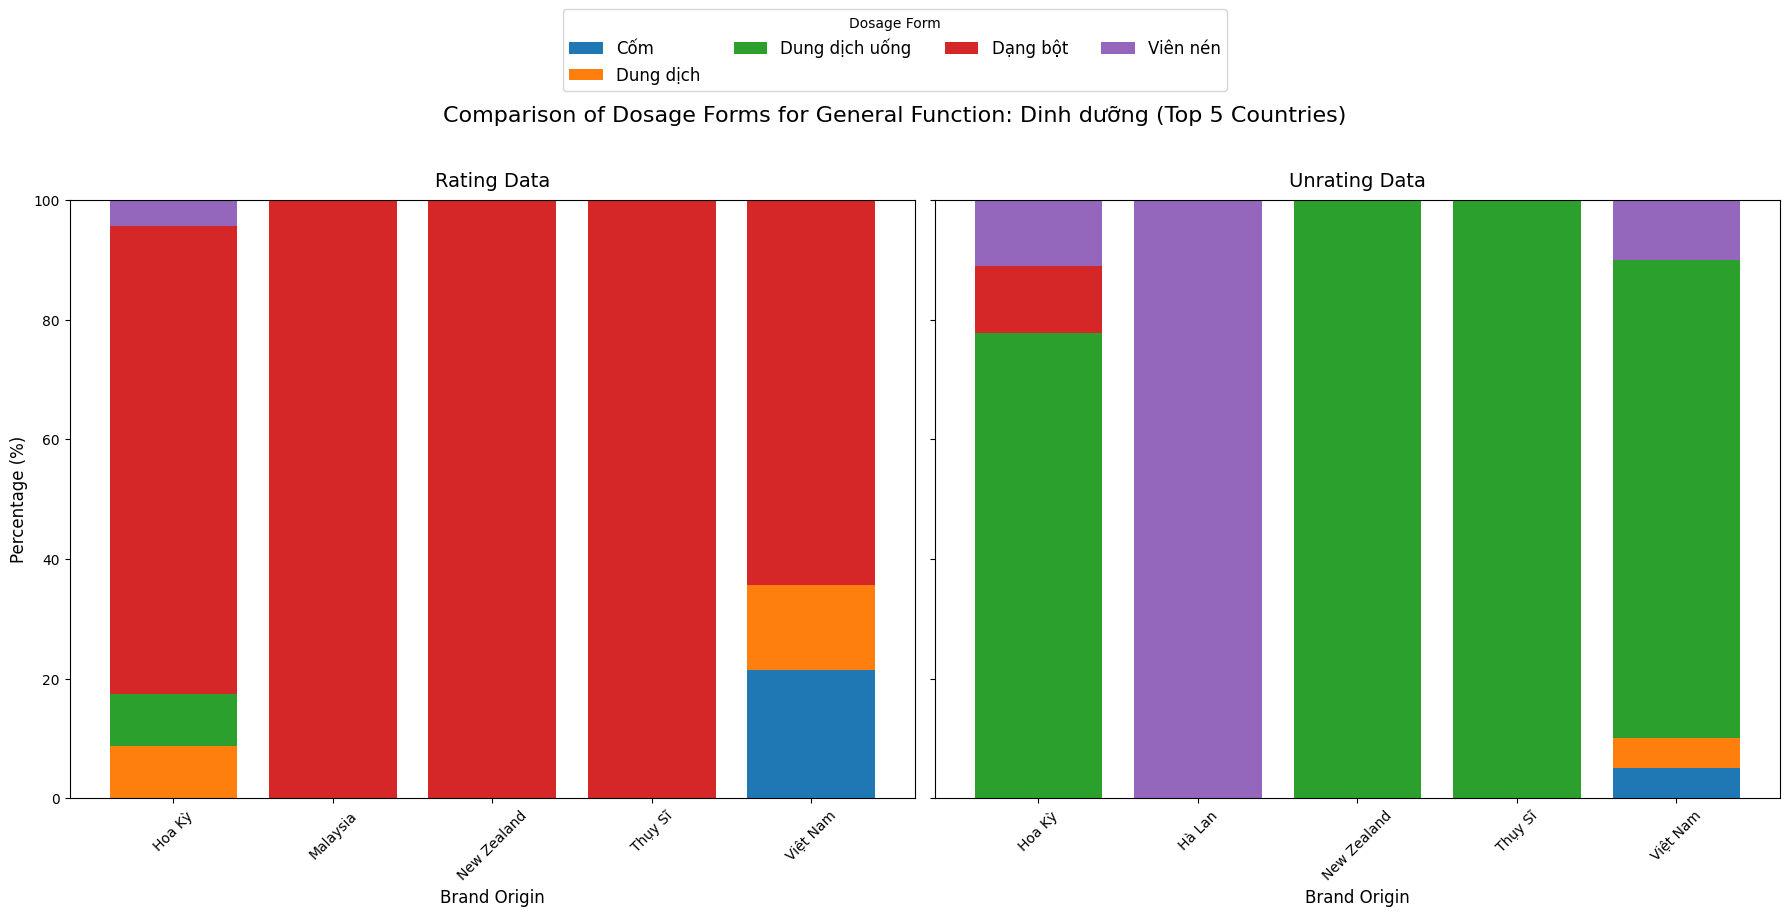

In [18]:
for func in unique_func:
    print("-" * 80)
    plot_dosage_form_comparison(func, rating_df, unrating_df)

- **Body Care**: Among the most popular body care products in various countries, cream-based products are the most common, while wax-based products are the least preferred.

- **Facial Skincare**: Cream-based products are popular, while gel-based products are mainly less preferred.

- **Beauty Enhancement**: This category features a wide variety of formulations. However, cream and tablet forms are still the most popular for beauty enhancement, while solutions are less preferred.

- **Hair and Scalp Care**: Both popular and less popular products are primarily developed in cream and solution forms.

- **Skin Solutions**: Mostly popular in cream form, while gel-based products are less preferred.

- **Makeup Products**: Primarily developed in cream and wax forms, with little difference in interest between popular and less popular products.

- **Natural Products**: Primarily available in cream and solution forms for both types of products.

- **Eye Area Skincare**: Only developed in cream form.

- **Function-Enhancing Products**: Primarily developed in tablet form, with some products in solution form. Less popular products include syrup and powder forms.

- **Vitamins and Minerals**: Mainly developed in tablet and solution forms.

- **Neurological Support**: Popular products are mainly available in solution and capsule forms.

- **Digestive Support**: Popular products are primarily in capsule, powder, and solution forms. Less popular ones are in tablet and solution forms.

- **Hormonal and Endocrine Support**: Preferred products include soft capsules, hard capsules, and tablets, while less preferred forms are hard pills and hard capsules.

- **Therapeutic Support**: Popular products include capsules, hard capsules, and tablets, while less popular ones are hard and soft capsules.

- **Cardiovascular Health**: Popular products are primarily in tablet form.

- **Nutrition**: Popular in powder form, while less preferred in liquid and tablet forms.

=> These factors may influence consumer purchasing decisions.


# Question 2

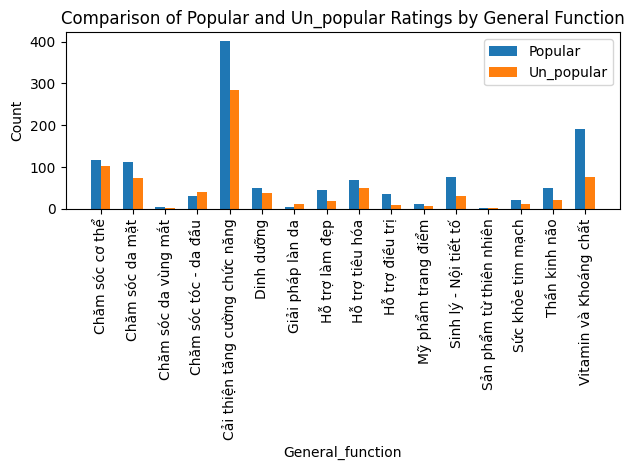

In [19]:
function_popular_count = df.groupby('General_function').agg(
    popular=('Rating', lambda x: (x != 'unknown').sum()),
    un_popular=('Rating', lambda x: (x == 'unknown').sum())
).reset_index()

# Set up the position of each group of bars
index = np.arange(len(function_popular_count['General_function']))
bar_width = 0.3

# Set up the plot
fig, ax = plt.subplots()

# Plot the bars 'popular' and 'un_popular'
bar1 = ax.bar(index - bar_width/2, function_popular_count['popular'], bar_width, label='Popular')
bar2 = ax.bar(index + bar_width/2, function_popular_count['un_popular'], bar_width, label='Un_popular')

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Popular and Un_popular Ratings by General Function')
ax.set_xticks(index)
ax.set_xticklabels(function_popular_count['General_function'], rotation=90)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


In [20]:
#Count Popular = VietNam + Other_Countries
country_general_popular = df.groupby('General_function').agg(
    Popular=('Rating', lambda x: (x != 'unknown').sum()),
    Vietnam=('Country', lambda x: ((x == 'Việt Nam') & (df['Rating'] != 'unknown')).sum()),
    Other_Countries=('Country', lambda x: ((x != 'Việt Nam') & (df['Rating'] != 'unknown')).sum())
).reset_index()


print(country_general_popular)



                  General_function  Popular  Vietnam  Other_Countries
0                  Chăm sóc cơ thể      116       49               67
1                  Chăm sóc da mặt      113       32               81
2             Chăm sóc da vùng mắt        4        0                4
3            Chăm sóc tóc - da đầu       31       26                5
4   Cải thiện tăng cường chức năng      402      207              195
5                       Dinh dưỡng       51       14               37
6                 Giải pháp làn da        4        2                2
7                   Hỗ trợ làm đẹp       46       19               27
8                  Hỗ trợ tiêu hóa       68       38               30
9                  Hỗ trợ điều trị       35       23               12
10              Mỹ phẩm trang điểm       12        3                9
11           Sinh lý - Nội tiết tố       75       37               38
12         Sản phẩm từ thiên nhiên        2        2                0
13               Sức

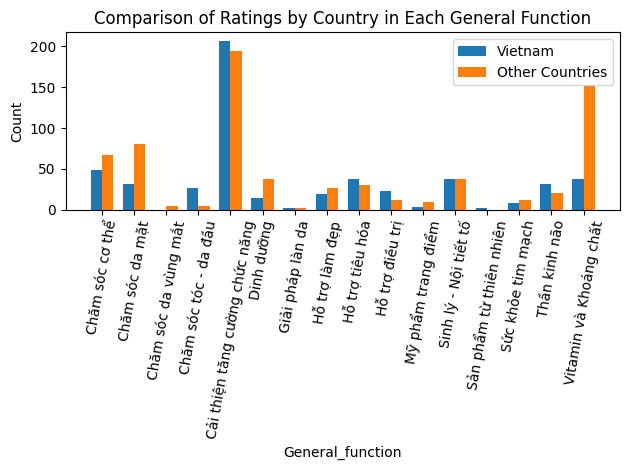

In [21]:
# Set up the position of each group of bars
index = np.arange(len(country_general_popular['General_function']))
bar_width = 0.35

# Set up the plot
fig, ax = plt.subplots()

# Plot the bars 'Vietnam' and 'Other_Countries'
bar1 = ax.bar(index - bar_width/2, country_general_popular['Vietnam'], bar_width, label='Vietnam')
bar2 = ax.bar(index + bar_width/2, country_general_popular['Other_Countries'], bar_width, label='Other Countries')

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Ratings by Country in Each General Function')
ax.set_xticks(index)
ax.set_xticklabels(country_general_popular['General_function'], rotation=80)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


- For the categories of products that are of interest, there is no clear distinction in product ratings between Vietnam and other countries. Except for the "Vitamin và khoáng chất" category, which indicates that when purchasing vitamin products, users tend to trust foreign products more than those from Vietnam.

# Question 3

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41904\3473474743.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby(['General_function', 'Price_Category']).agg(


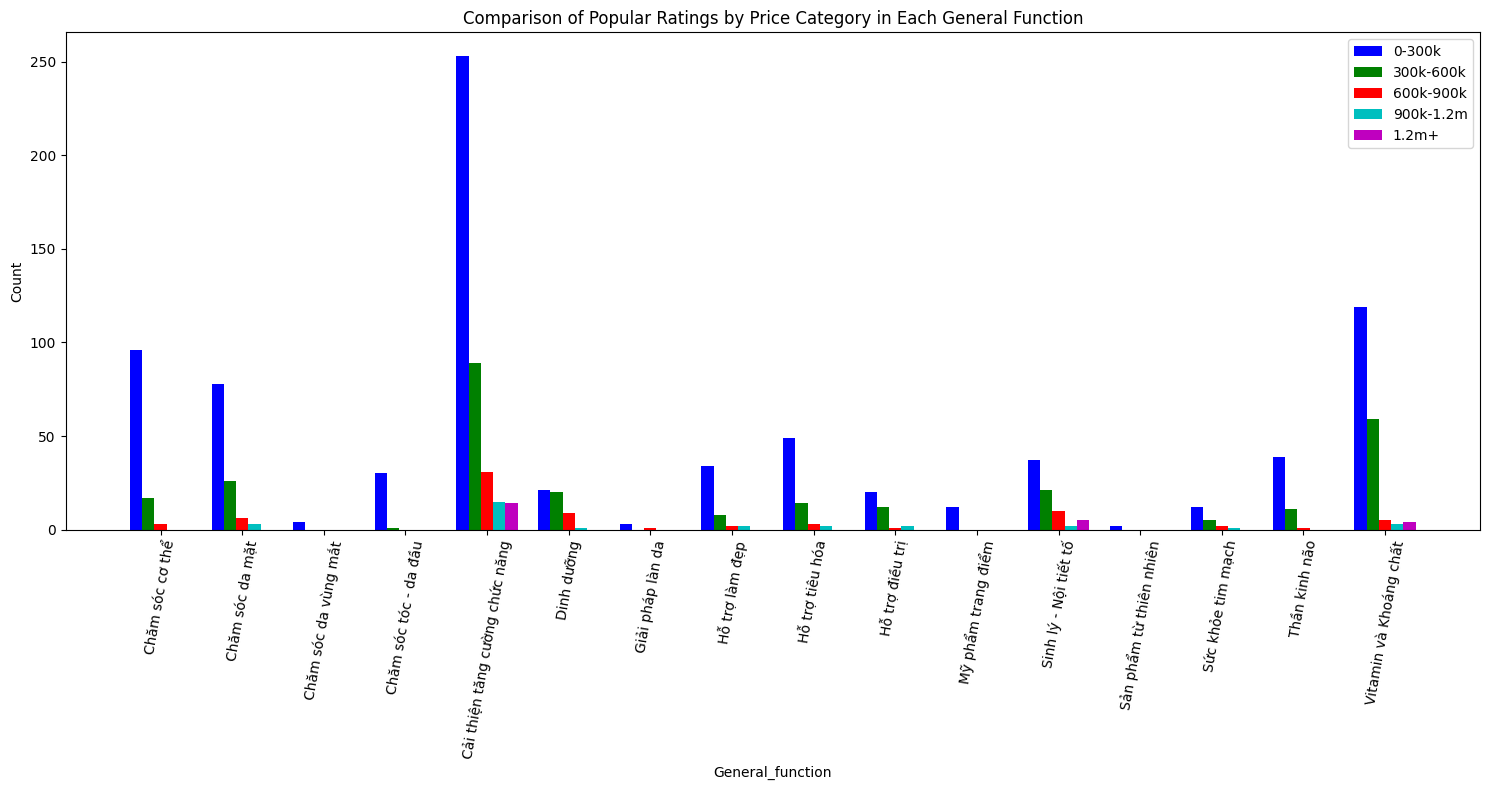

In [22]:
# Add a new column to classify price ranges
bins = [0, 300000, 600000, 900000, 1200000, float('inf')]
labels = ['0-300k', '300k-600k', '600k-900k', '900k-1.2m', '1.2m+']
df['Price_Category'] = pd.cut(df['Price'], bins=bins, labels=labels, right=False)

# Use groupby and agg to calculate the number of 'Popular' in each General_function and Price_Category group
grouped_df = df.groupby(['General_function', 'Price_Category']).agg(
    Popular=('Rating', lambda x: (x != 'unknown').sum())
).reset_index()

# Set up the position of each group of bars
index = np.arange(len(grouped_df['General_function'].unique()))
bar_width = 0.15

# Set up colors for the price ranges
colors = ['b', 'g', 'r', 'c', 'm']

# Set up the plot
fig, ax = plt.subplots(figsize=(15, 8))

# Plot the bars for each price range
for i, label in enumerate(labels):
    bar_data = grouped_df[grouped_df['Price_Category'] == label]
    bar = ax.bar(index + i * bar_width, bar_data['Popular'], bar_width, label=label, color=colors[i])

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Popular Ratings by Price Category in Each General Function')
ax.set_xticks(index + bar_width * (len(labels) - 1) / 2)
ax.set_xticklabels(grouped_df['General_function'].unique(), rotation=80)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


- In the above chart, it can be seen that in any category, there are products priced from 0-300k. This suggests that this is a common price range for customers. 
- The diversity in price ranges within each category is not particularly clear, but it's most evident in the "Function Enhancement", "Vitamins and Minerals", and "Physiology - Hormones" categories. These are the categories with a wide range of prices from low to high, making it easier for customers to choose. Consequently, these might be the categories that pharmacies should focus on in terms of pricing to cater to their customers appropriately.

# Question 4

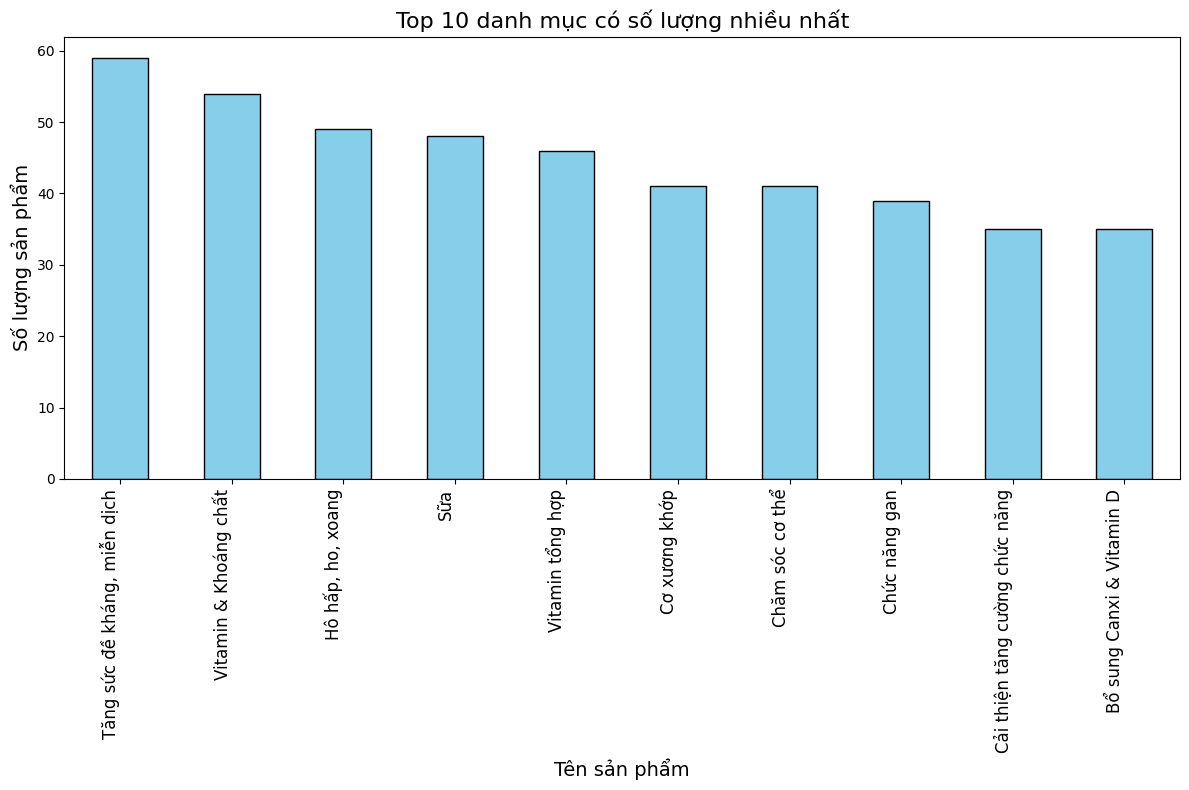

In [23]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Lọc các sản phẩm có Rating >= 0
filtered_df = df[df['Rating'] >= 0]

# Tính toán top 10 sản phẩm có số lượng nhiều nhất
top_products = filtered_df['Category'].value_counts().head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 danh mục có số lượng nhiều nhất', fontsize=16)
plt.xlabel('Tên sản phẩm', fontsize=14)
plt.ylabel('Số lượng sản phẩm', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

- **Market Overview:**
    - The market for major categories such as immune support, immunity, and vitamins & minerals is highly competitive, as evidenced by their wide diversity and the highest number of products.
    - Meanwhile, other categories, such as Calcium & Vitamin D supplements and functional improvement products, also have a significant number of offerings but have yet to dominate the market.
-  **Market Trends:**
    - The categories with the most diverse and extensive offerings are prominently seen in: immune support, immunity; vitamins & minerals; respiratory, cough, sinus health; dairy products; multivitamins; personal care; musculoskeletal health; liver function; Calcium & Vitamin D supplements; and functional improvement products.

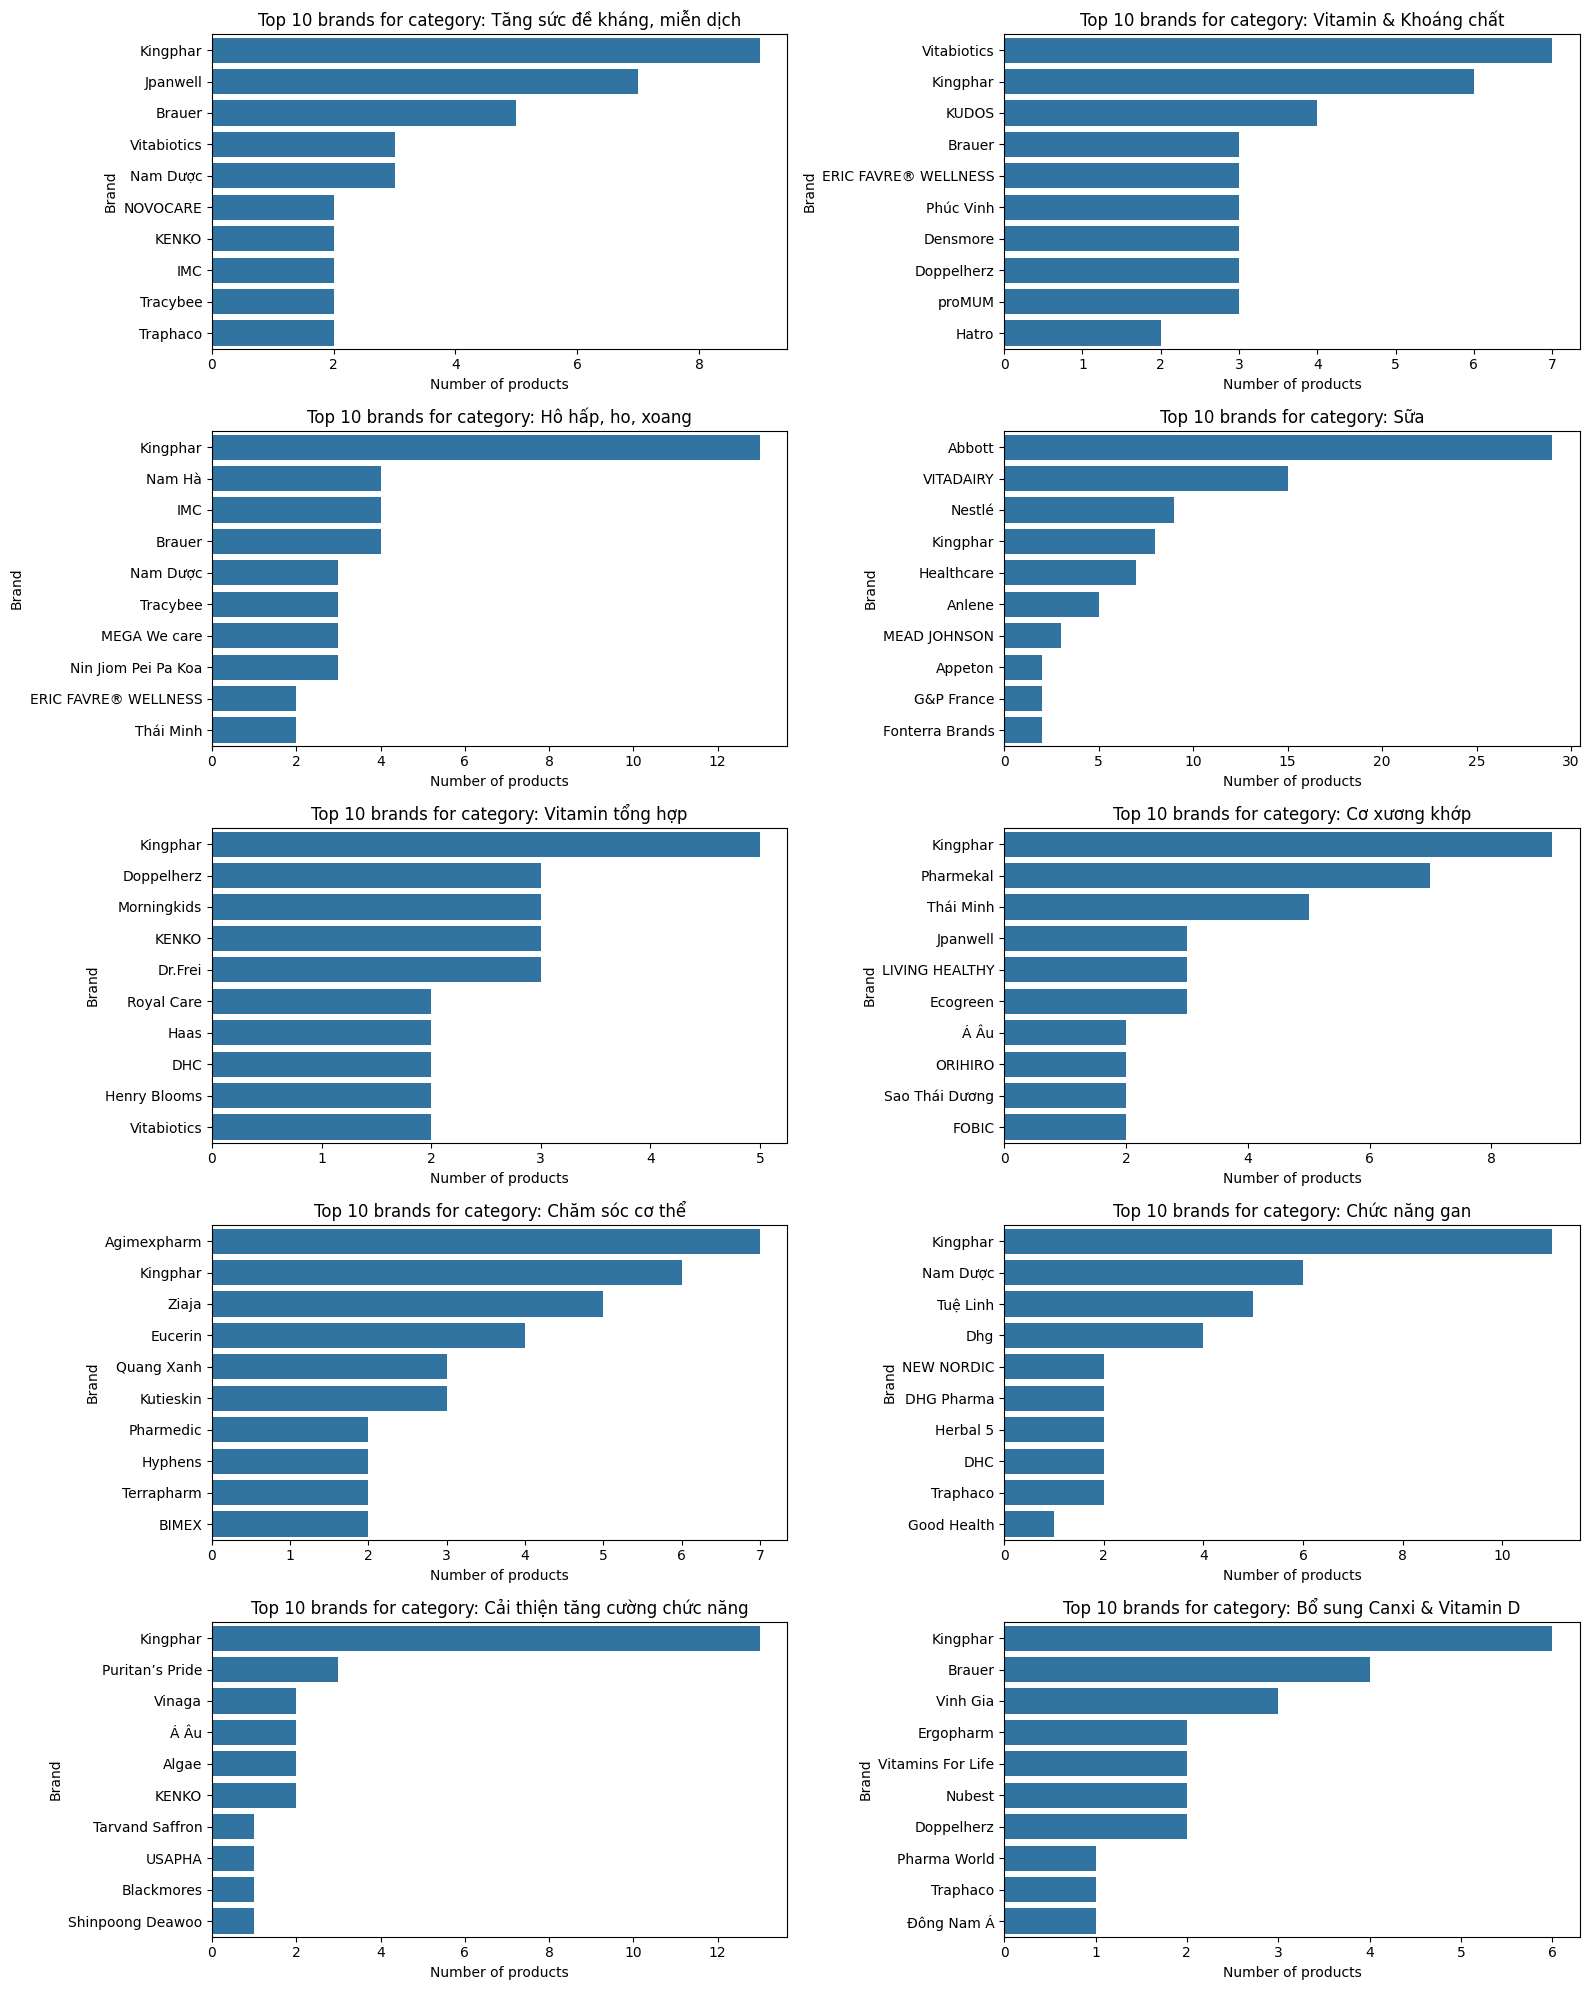

In [24]:
top_products_list = top_products.index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(16, 20)) 
axes = axes.flatten()

for i, product in enumerate(top_products_list):
    product_data = df[df['Category'] == product]
    
    top_brands = product_data['Trademark'].value_counts().head(10)
    
    sns.barplot(
        x=top_brands.values,
        y=top_brands.index,
        ax=axes[i],
        # palette='viridis'
    )

    # Update the title of the chart
    axes[i].set_title(f"Top 10 brands for category: {product[:40]}", fontsize=12)
    axes[i].set_xlabel('Number of products', fontsize=10)
    axes[i].set_ylabel('Brand', fontsize=10)  
      
plt.tight_layout()
plt.show()


- Some categories are clearly dominated by major brands, while others have a more balanced distribution among various brands.
    - Categories with clear dominance:
        - Categories such as respiratory, cough, sinus health; dairy products; personal care; Calcium and Vitamin D supplements; and functional improvement are dominated by major brands like Abbott, Kingphar, and Eucerin. These brands account for the majority of products, as evidenced by their disproportionately tall representative bars.
    - Categories with balanced distribution:
        - Categories such as vitamins & minerals, multivitamins, and musculoskeletal health have a more balanced distribution, with multiple brands appearing and maintaining relatively equal shares.
- Brand Distribution:
	- Brand distribution data:
        -  Some brands like Kingphar, Abbott, and Blackmores are present across multiple categories, showcasing their significant market influence.
        - Smaller brands tend to focus on a few specific categories, with fewer products but remain competitive in their niche markets.

# Question 5

<Figure size 1400x800 with 0 Axes>

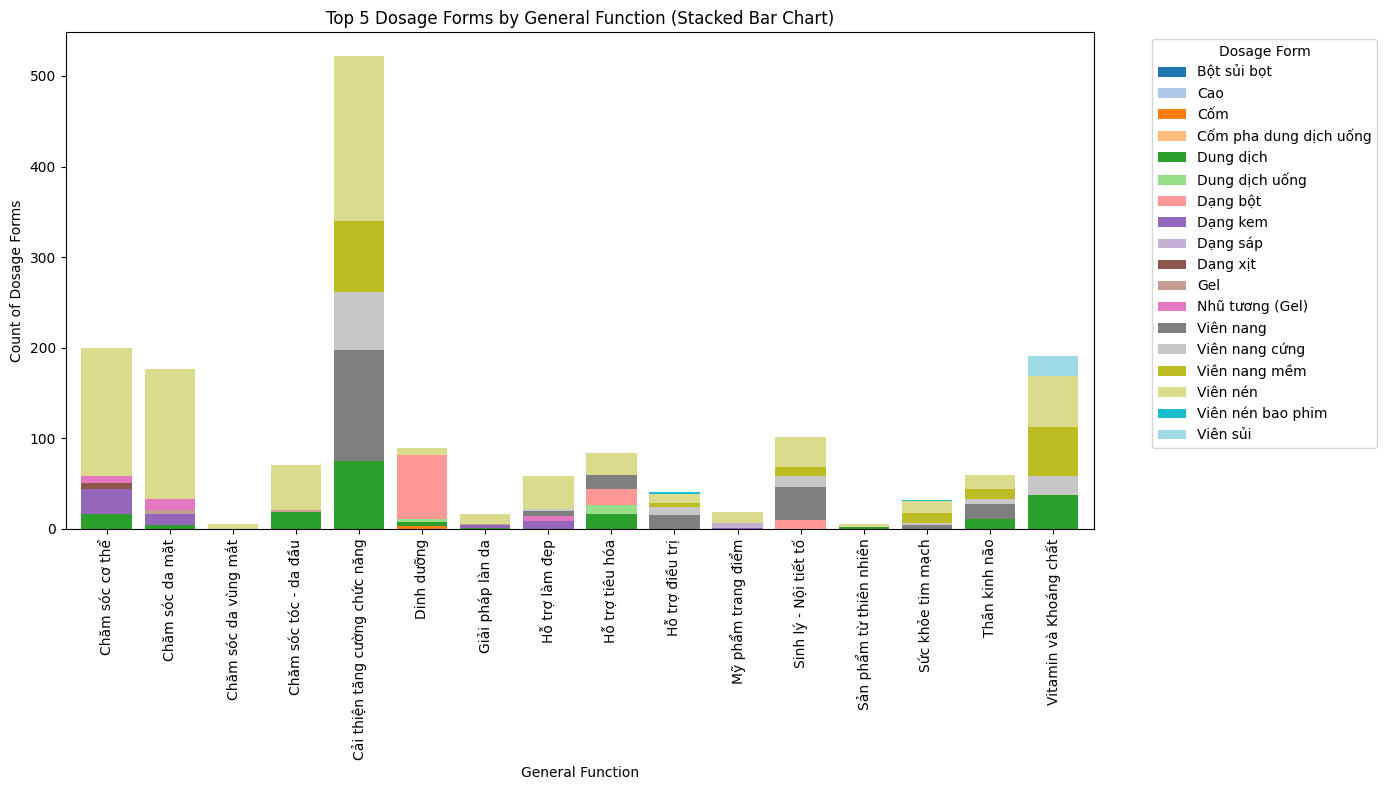

In [25]:
mapping = {
    'Bột': 'Dạng bột',  
    'Dạng bột': 'Dạng bột',
    'Kem': 'Dạng kem',
    'Dạng kem': 'Dạng kem',
}

# Apply mapping to consolidate dosage forms
df['Dosage Form'] = df['Dosage Form'].replace(mapping)

# Step 2: Count the occurrences of each dosage form by category
dosage_counts = df.groupby(['General_function', 'Dosage Form']).size().unstack(fill_value=0)

# Step 3: Filter out the top 5 dosage forms for each category
top_5_dosage = dosage_counts.apply(lambda x: x.nlargest(5).index, axis=1)
filtered_dosage_counts = dosage_counts.apply(lambda x: x.nlargest(5), axis=1)

# Step 4: Visualize the results using a stacked bar chart
plt.figure(figsize=(14, 8))

# Plot stacked bar chart
ax = filtered_dosage_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20', width=0.8)

# Add title and labels
plt.title('Top 5 Dosage Forms by General Function (Stacked Bar Chart)')
plt.xlabel('General Function')
plt.ylabel('Count of Dosage Forms')

# Adjust the position of the X-axis labels and rotate them vertically
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

# Move the legend outside the plot
plt.legend(title="Dosage Form", bbox_to_anchor=(1.05, 1), loc='upper left')

# Fine-tune the layout and display the plot
plt.tight_layout()
plt.show()


Comment:
* Dosage forms such as tablets and capsules are mainly focused on categories related to health improvement (such as enhancing function, vitamins and minerals, hormonal physiology).
* Cream formulations are primarily focused on categories related to skincare and body care.
* Powder formulations are suitable for categories related to nutritional support. => The information in this chart can help consumers make shopping decisions. If users are interested in supporting health inside the body, tablet formulations would be a suitable choice, while for skincare, creams are more common. This narrows down product choices for consumers, helping to save time in product search.

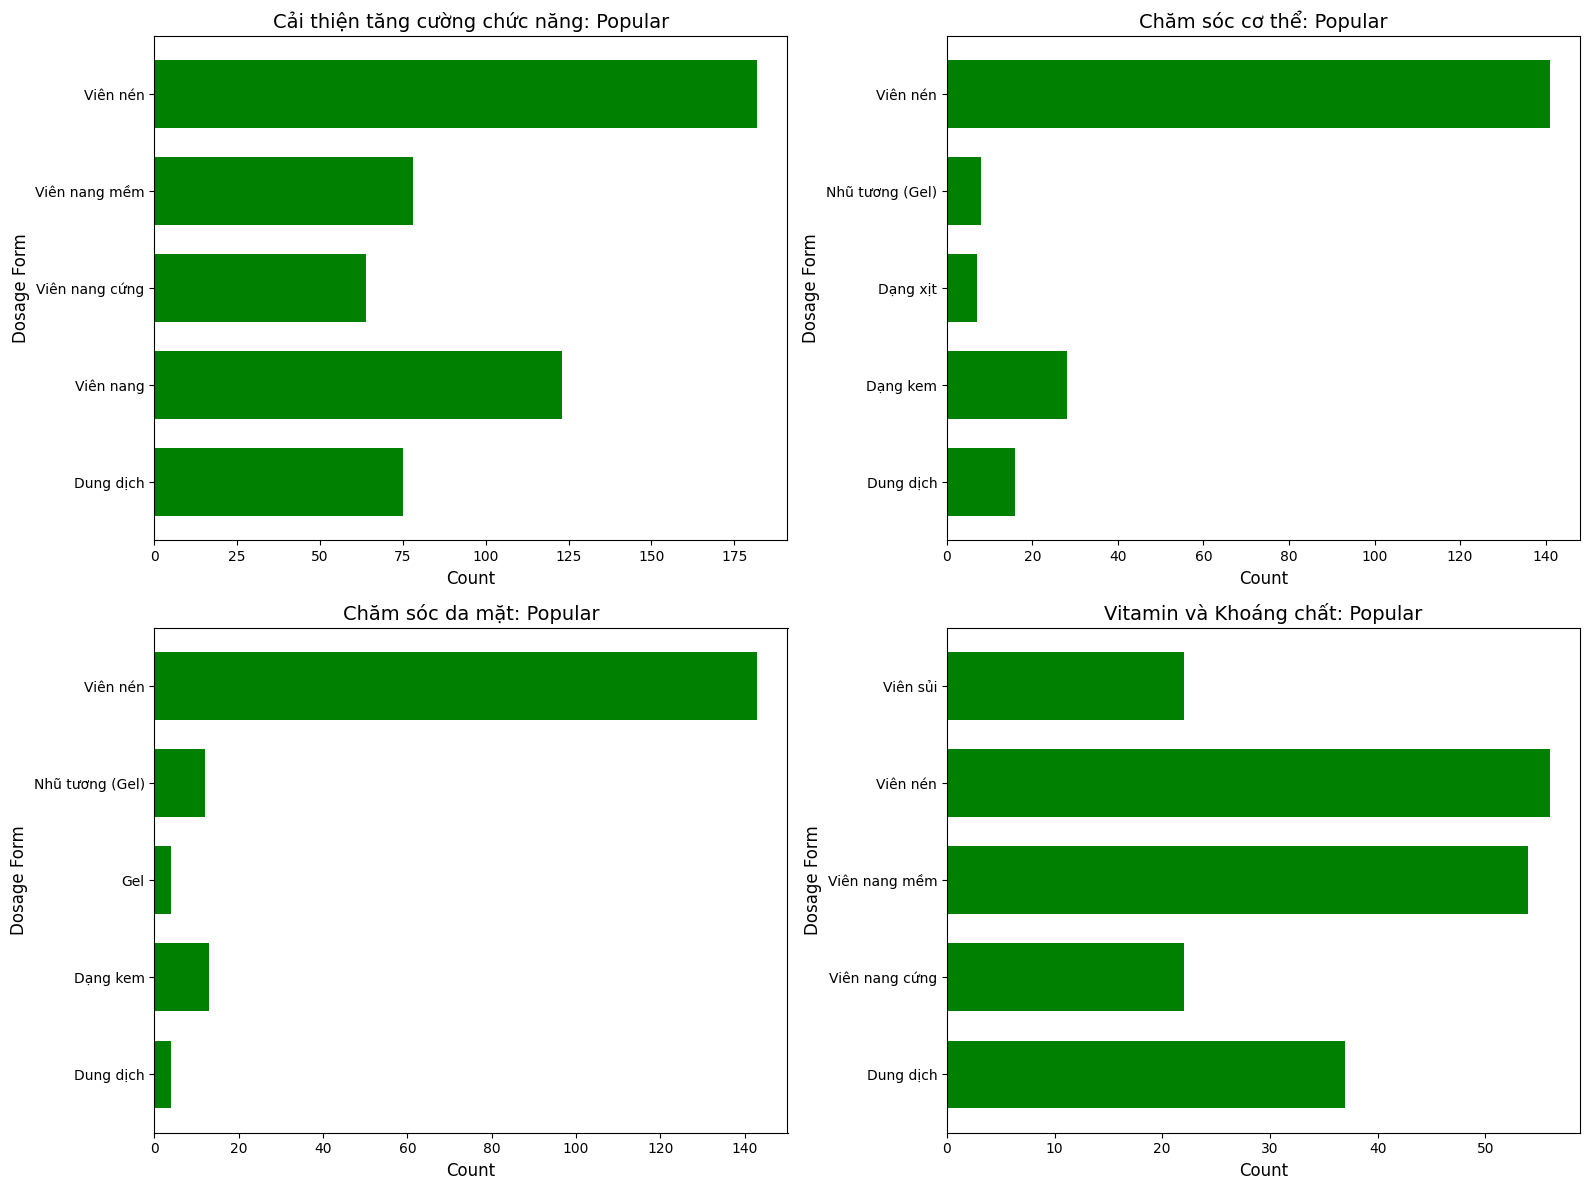

In [26]:
# Prepare 'Popular' data
df['Popular'] = df['Rating'].apply(lambda x: 1 if x != "unknown" else 0)

# Calculate the total 'Popular' count by General_function and Dosage Form
rating_summary = df.groupby(['General_function', 'Dosage Form'])[['Popular']].sum().reset_index()

# Count the occurrences of each dosage form by category
dosage_counts = df.groupby(['General_function', 'Dosage Form']).size().reset_index(name='Count')

# Merge original data to include the 'Price' column in dosage_counts
dosage_counts = pd.merge(dosage_counts, df[['General_function', 'Dosage Form', 'Price']], 
                          on=['General_function', 'Dosage Form'], how='left')

# Calculate the total occurrences for each category and filter the top 4 categories
total_counts_per_category = dosage_counts.groupby('General_function')['Count'].sum().reset_index()
top_4_categories = total_counts_per_category.nlargest(4, 'Count')['General_function']

# Filter data for the top 4 categories
filtered_rating_summary = rating_summary[rating_summary['General_function'].isin(top_4_categories)]

# Visualize the 'Popular' counts
plt.figure(figsize=(16, 12))

for i, category in enumerate(top_4_categories, 1):
    # Filter data by the current category
    category_data = filtered_rating_summary[filtered_rating_summary['General_function'] == category]
    
    # Filter the top 5 most popular dosage forms
    top_5_dosage = category_data.groupby('Dosage Form')['Popular'].sum().nlargest(5).index
    category_data = category_data[category_data['Dosage Form'].isin(top_5_dosage)]
    
    # Set up the plot
    plt.subplot(2, 2, i)
    category_data.set_index('Dosage Form')['Popular'].plot(
        kind='barh', ax=plt.gca(), color='green', width=0.7
    )
    plt.title(f'{category}: Popular', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Dosage Form', fontsize=12)
    plt.tight_layout()

plt.show()


As we can see, categories related to internal health support tend to have a large number of ratings for pill dosage forms, while categories related to skincare and body care have a large number of ratings for cream dosage forms. This suggests that these dosage forms are more popular, trusted, and preferred by consumers in the market. On the other hand, dosage forms with lower rating counts may indicate that they are less experienced by consumers, not as widespread in the market, and may not have gained as much trust. Therefore, consumers can consider and quickly choose the appropriate and suitable dosage form for use.